In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sys

esmDMS_DIR = "/Users/dylanwells/popDMS/esmDMS"

sys.path.insert(0, esmDMS_DIR)
from esmdmsfunctions import (
    get_eigenvector_simulation_results,
    get_simulation_results,
    generate_selection, gaussian_selection, zero_selection,
    z_normalize, load_final_df, load_embedding_df
)
from scipy.stats import pearsonr

from popDMS import mini_infer_independent_esm

import os

# ── Paths to analyse (name → directory containing layer0/, layer1/, … subdirs)
comb_path = esmDMS_DIR + "/data/bg_bf_comb_data"
bg_path   = esmDMS_DIR + "/data/inference_data/BG505"
bf_path   = esmDMS_DIR + "/data/inference_results"

active_datasets = {
    "BG505": bg_path,
    "BG505+BF520": comb_path,
    "BF520": bf_path
}

LAYERS = list(range(31))

Dataset: BG505
corrs_list: [[np.float64(0.9926235871325038), np.float64(0.998316107227673), np.float64(0.9932709000602724)], [np.float64(0.9888821538493094), np.float64(0.9916344794470802), np.float64(0.9940009411915948)], [np.float64(0.99427858178376), np.float64(0.9907955294554877), np.float64(0.9847803960952514)], [np.float64(0.9937931597307769), np.float64(0.9925286051704025), np.float64(0.980432553904946)], [np.float64(0.998321492716217), np.float64(0.9987163992808148), np.float64(0.995905733712416)], [np.float64(0.9942271787548098), np.float64(0.9892293262667808), np.float64(0.988118149440552)], [np.float64(0.9947917227360821), np.float64(0.9904028917807894), np.float64(0.9895653939425699)], [np.float64(0.9950608927159246), np.float64(0.9906078564021518), np.float64(0.990131621516448)], [np.float64(0.9950138229423369), np.float64(0.9905630689172441), np.float64(0.9901625860401071)], [np.float64(0.9950404985419262), np.float64(0.990629831379773), np.float64(0.9902341101311596)], [

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


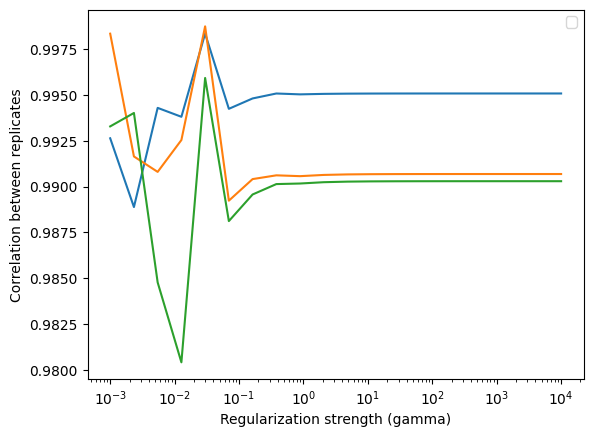

corrs_list: [[np.float64(0.9916032946947911), np.float64(0.9988379316812342), np.float64(0.9959539155670465)], [np.float64(0.9991704390215149), np.float64(0.9984619462355592), np.float64(0.9989824515653883)], [np.float64(0.983555837909832), np.float64(0.9984642252553855), np.float64(0.9901444266021613)], [np.float64(0.9961353861208098), np.float64(0.997908843265313), np.float64(0.9990820710667911)], [np.float64(0.9838763534947839), np.float64(0.9119347422215318), np.float64(0.9089434256572883)], [np.float64(0.9754648655360885), np.float64(0.782994970145662), np.float64(0.6467815644587216)], [np.float64(0.9987864440218718), np.float64(0.941753839114748), np.float64(0.9298917168005689)], [np.float64(0.9425326614385147), np.float64(0.9602921624369722), np.float64(0.9923380622713893)], [np.float64(0.9768014056232244), np.float64(0.968524169399597), np.float64(0.9983319074309499)], [np.float64(0.9966007071879587), np.float64(0.9968099732512329), np.float64(0.9906614349310396)], [np.float64(

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


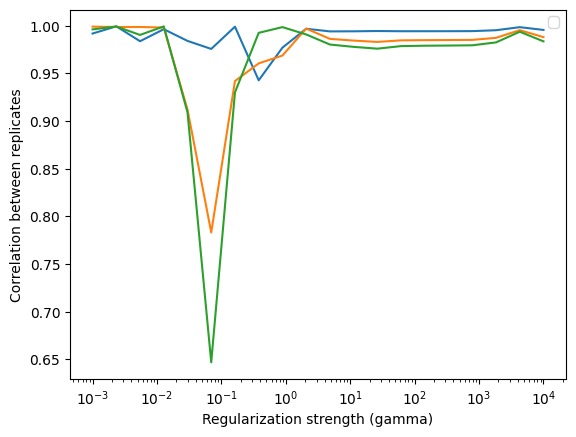

corrs_list: [[np.float64(0.9934362638767972), np.float64(0.995556382696898), np.float64(0.9965880921381911)], [np.float64(0.9965086990215511), np.float64(0.9942568295390128), np.float64(0.99618837777899)], [np.float64(0.992727396352827), np.float64(0.98057221149476), np.float64(0.9866372463588152)], [np.float64(0.9924234761505981), np.float64(0.9661968266772268), np.float64(0.9720626600537757)], [np.float64(0.9857468005087507), np.float64(0.9985559146268178), np.float64(0.9782007781935129)], [np.float64(0.9979040901883856), np.float64(0.9974324892985745), np.float64(0.9937181060999138)], [np.float64(0.996610191296122), np.float64(0.9424328708579446), np.float64(0.9321473245237267)], [np.float64(0.9996057233492839), np.float64(0.9985415235706254), np.float64(0.999461010978054)], [np.float64(0.49869064206272584), np.float64(0.8005089606617342), np.float64(0.9108022555797793)], [np.float64(0.9943738457177754), np.float64(0.9940009593231567), np.float64(0.986784762251492)], [np.float64(0.9

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


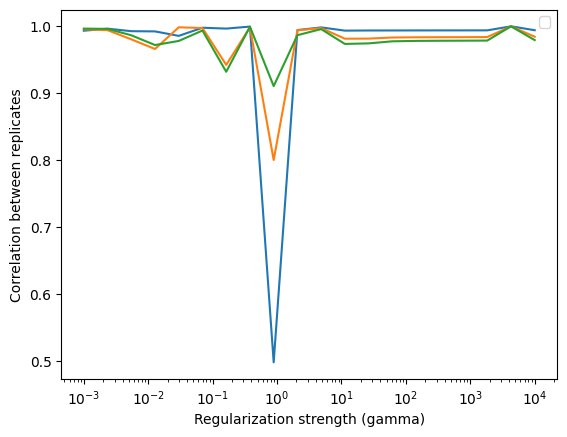

corrs_list: [[np.float64(0.9994998656094138), np.float64(0.9997483172036141), np.float64(0.9992467823911197)], [np.float64(0.9986599157823519), np.float64(0.9909070567505767), np.float64(0.9903379210455346)], [np.float64(0.9349569143730697), np.float64(0.9951820912565459), np.float64(0.9267609229579085)], [np.float64(0.993254671328748), np.float64(-0.9581215315966565), np.float64(-0.9848341101493394)], [np.float64(0.9882718472285434), np.float64(0.9566275379286386), np.float64(0.9082090549868485)], [np.float64(0.9953801648504113), np.float64(0.9907198137425236), np.float64(0.9771476499551767)], [np.float64(0.902544633431057), np.float64(0.9909864067529606), np.float64(0.8795092032236181)], [np.float64(0.9948919773651075), np.float64(0.3430132569458536), np.float64(0.2825880680452994)], [np.float64(0.9848144324377508), np.float64(0.9669050482177379), np.float64(0.9157806479492678)], [np.float64(0.9946864898880795), np.float64(0.9811972862286034), np.float64(0.974792217969945)], [np.floa

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


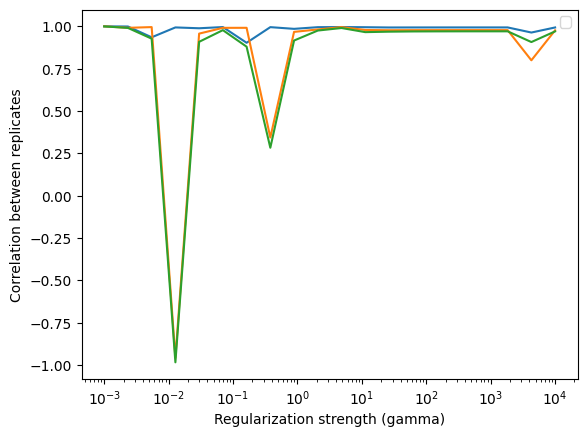

corrs_list: [[np.float64(0.9928382310012944), np.float64(0.9714452173026954), np.float64(0.970670597364615)], [np.float64(0.9961753079247606), np.float64(0.9688623339405497), np.float64(0.9757947407002396)], [np.float64(0.9892836328811008), np.float64(0.9857576844313793), np.float64(0.9652166571451364)], [np.float64(0.9857876342764963), np.float64(0.9766759935673622), np.float64(0.9591334881246368)], [np.float64(0.9646450887483791), np.float64(0.9728572839456652), np.float64(0.9889450819154291)], [np.float64(0.9801687728753725), np.float64(0.9431116136396429), np.float64(0.9441194026318003)], [np.float64(0.4429000316715277), np.float64(0.9387549868360291), np.float64(0.19821859782579243)], [np.float64(0.9733923578902935), np.float64(0.9425391109860954), np.float64(0.8796751645490019)], [np.float64(0.9981171694880058), np.float64(0.9916706645935514), np.float64(0.9913017315910296)], [np.float64(0.9856980986873252), np.float64(0.967149956961193), np.float64(0.963961296520129)], [np.float

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


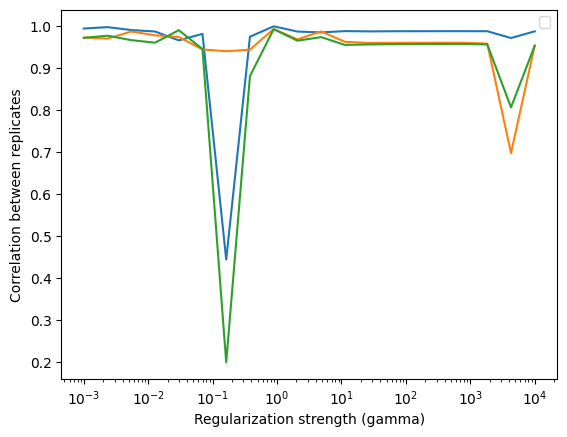

corrs_list: [[np.float64(0.9899072738717494), np.float64(0.9670448164345444), np.float64(0.9846540926583311)], [np.float64(0.9929688135668481), np.float64(0.9983395910427468), np.float64(0.9869565196180926)], [np.float64(0.9591689916046298), np.float64(0.8196362204923794), np.float64(0.8373699733081865)], [np.float64(0.9589744563391921), np.float64(0.9420489212260768), np.float64(0.9203595567410485)], [np.float64(0.9864461288137885), np.float64(0.9869689516492608), np.float64(0.9986465037122345)], [np.float64(0.9920226556165358), np.float64(0.9918242222686817), np.float64(0.9937682231358499)], [np.float64(0.9832336678643742), np.float64(0.9244030171824396), np.float64(0.954806628441678)], [np.float64(0.9864692889177453), np.float64(0.8675527737996623), np.float64(0.8042014701851876)], [np.float64(0.9722309011604141), np.float64(0.8050330096543492), np.float64(0.9070339692243896)], [np.float64(0.9777098490831841), np.float64(0.9315029864158221), np.float64(0.9376708637915295)], [np.floa

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


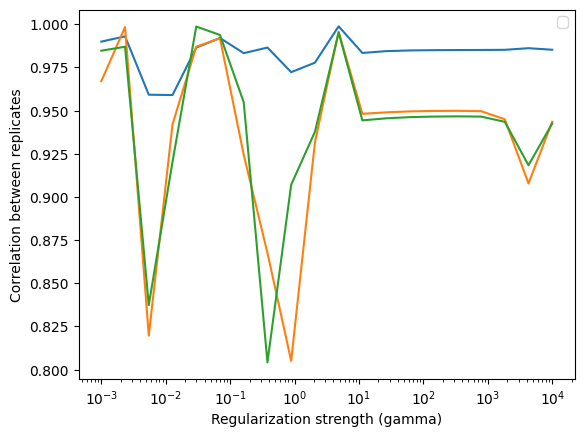

corrs_list: [[np.float64(0.9853943280136889), np.float64(0.9259544876588183), np.float64(0.8986376238981286)], [np.float64(0.9648540385665505), np.float64(0.8505469772878747), np.float64(0.8610530792490824)], [np.float64(0.9593163926149015), np.float64(0.9676473280707766), np.float64(0.9896157168428312)], [np.float64(0.9810430432064092), np.float64(0.7474209975317978), np.float64(0.7962509629374276)], [np.float64(0.9780049674601659), np.float64(0.9449337334173785), np.float64(0.9634238636335415)], [np.float64(0.9848763024494804), np.float64(0.9809168986098581), np.float64(0.9666819095399544)], [np.float64(0.9605699043222178), np.float64(0.9963403402045607), np.float64(0.9737300732650385)], [np.float64(0.975110138480852), np.float64(0.9799443814192997), np.float64(0.9538364484879714)], [np.float64(0.9220061804246842), np.float64(0.9130738699812484), np.float64(0.9260616825893281)], [np.float64(0.9873399781887191), np.float64(0.971266512008631), np.float64(0.962566501719507)], [np.float6

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


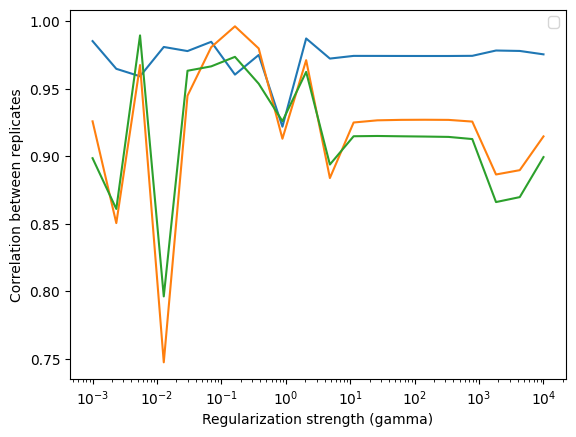

corrs_list: [[np.float64(0.9266669526198799), np.float64(0.9566919246588247), np.float64(0.9036522169727814)], [np.float64(0.999390639673374), np.float64(0.9995028675739298), np.float64(0.9998790831374214)], [np.float64(0.8559990588872963), np.float64(0.877694058990947), np.float64(0.6299794081221655)], [np.float64(0.4742832724782273), np.float64(0.911663359194639), np.float64(0.12596541402778974)], [np.float64(0.9987897496509716), np.float64(-0.9313564321140928), np.float64(-0.9471650261490083)], [np.float64(0.9994140647307019), np.float64(-0.9822138939097875), np.float64(-0.9878776256718361)], [np.float64(0.9992854502401501), np.float64(0.9925907437996556), np.float64(0.9903157810624348)], [np.float64(0.972206491703964), np.float64(0.9540721293678487), np.float64(0.9135956428143052)], [np.float64(0.9685361447580131), np.float64(0.8892028117427024), np.float64(0.9062629188650644)], [np.float64(0.9641275745280515), np.float64(0.9183965991818036), np.float64(0.9075543578254909)], [np.fl

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


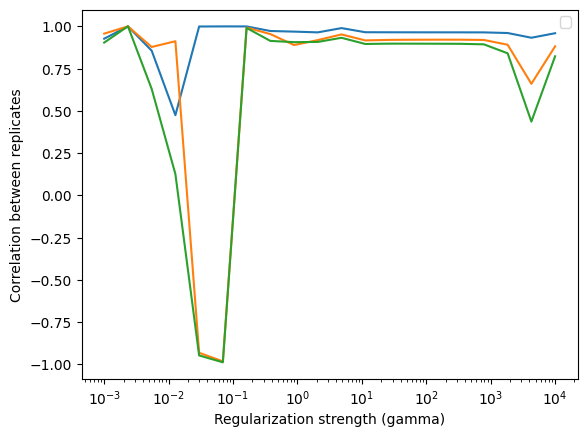

corrs_list: [[np.float64(0.9429739935488437), np.float64(0.6862277943842756), np.float64(0.6611194370586007)], [np.float64(0.9464341286319782), np.float64(0.8609297445110172), np.float64(0.8291449124555407)], [np.float64(0.5104660268723069), np.float64(0.9868623841522682), np.float64(0.6017069922878573)], [np.float64(0.9902464201669545), np.float64(0.3190142559892364), np.float64(0.42849863419245926)], [np.float64(0.9804568798329834), np.float64(0.5015032533279701), np.float64(0.3466659892986954)], [np.float64(0.8894009107545391), np.float64(0.7435577982999997), np.float64(0.8417431949643664)], [np.float64(0.9990010083564179), np.float64(0.9889711414966691), np.float64(0.9923390701192649)], [np.float64(0.9969700002174058), np.float64(0.9906676237985084), np.float64(0.9952576453606783)], [np.float64(0.9558518718149791), np.float64(0.9444559590804815), np.float64(0.9452358985923532)], [np.float64(0.8645890211945159), np.float64(0.8653171893546916), np.float64(0.8408000343263857)], [np.fl

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


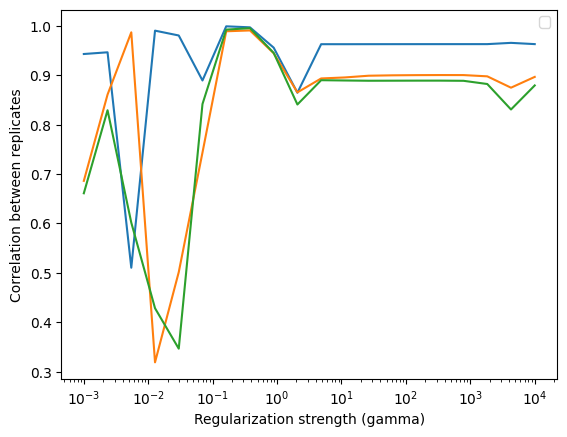

corrs_list: [[np.float64(0.965986106477017), np.float64(0.7489877890840086), np.float64(0.8423290355260973)], [np.float64(0.9232942142065268), np.float64(0.6957975505155989), np.float64(0.8489406928904316)], [np.float64(0.8340129673108458), np.float64(0.5451398210343598), np.float64(0.8163482192682854)], [np.float64(0.9308072911753145), np.float64(0.7425068336712578), np.float64(0.8651399814451048)], [np.float64(0.996154748275688), np.float64(0.9996411685300567), np.float64(0.9970748250920586)], [np.float64(0.9127367084309984), np.float64(0.7513607736094782), np.float64(0.9375277826661987)], [np.float64(0.9910997033943825), np.float64(0.9726316668513941), np.float64(0.9890598215989884)], [np.float64(0.8551596989699968), np.float64(0.876472514743735), np.float64(0.924772051423929)], [np.float64(0.9936261681462057), np.float64(0.9793877505558326), np.float64(0.9719295677244326)], [np.float64(0.9565364044561318), np.float64(0.8110167705411419), np.float64(0.8837599307474079)], [np.float64

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


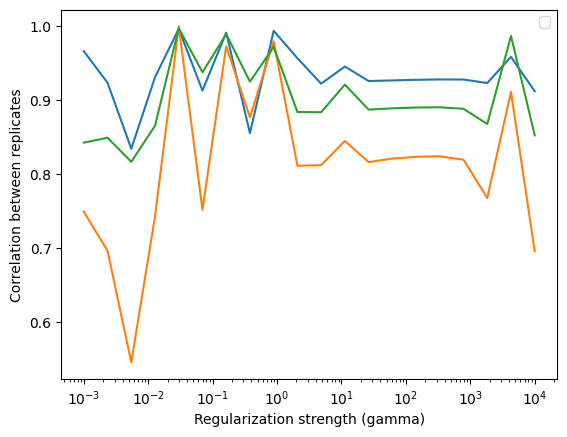

corrs_list: [[np.float64(0.9587755335291123), np.float64(0.9854425206326112), np.float64(0.9402915406144451)], [np.float64(0.9826934936810829), np.float64(0.9769896040148998), np.float64(0.947668085770231)], [np.float64(0.9052844697847713), np.float64(0.9492001381806254), np.float64(0.9595122362605192)], [np.float64(0.9012600292722568), np.float64(0.7765534634831206), np.float64(0.8782380774821438)], [np.float64(0.5378705159191978), np.float64(0.5853818306250695), np.float64(0.5189093986586495)], [np.float64(0.955075388864348), np.float64(0.844614506325947), np.float64(0.9376253035100359)], [np.float64(0.9559922155589846), np.float64(0.8612981837255431), np.float64(0.9312601677362449)], [np.float64(0.8591473593227705), np.float64(0.8415246669230736), np.float64(0.9677363640268004)], [np.float64(0.9858172610892931), np.float64(0.9624777105116017), np.float64(0.9718973794275725)], [np.float64(0.9603479884752396), np.float64(0.8376178715738518), np.float64(0.9084607014461595)], [np.float6

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


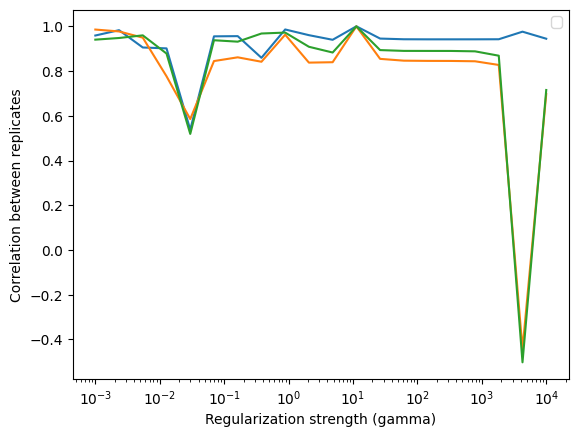

corrs_list: [[np.float64(0.010922909799706212), np.float64(0.9547152106374258), np.float64(0.2952679705864676)], [np.float64(0.6563778891149111), np.float64(0.7598320675637298), np.float64(0.7612781589062964)], [np.float64(-0.14162583363990788), np.float64(-0.2642957419747871), np.float64(0.9789970655259215)], [np.float64(-0.044267967141932055), np.float64(0.3504573909229078), np.float64(0.9047290277308787)], [np.float64(0.800022965783304), np.float64(0.4380062338870425), np.float64(0.7089093108438705)], [np.float64(0.8904808015967762), np.float64(0.6218478855626868), np.float64(0.6255483581770193)], [np.float64(-0.9840424319404759), np.float64(-0.9996302077657562), np.float64(0.9876753583645496)], [np.float64(0.8845516010231964), np.float64(0.7987267117274887), np.float64(0.9750502487313741)], [np.float64(0.9957299431692428), np.float64(0.9937894502068516), np.float64(0.9922991377775291)], [np.float64(0.9808634725261524), np.float64(0.9531149933032087), np.float64(0.9686011369573174)]

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


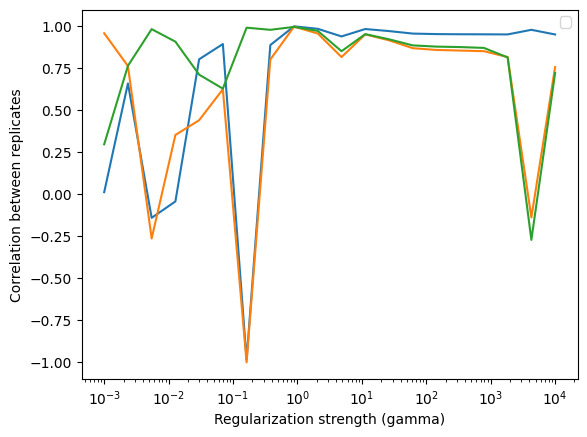

corrs_list: [[np.float64(0.9069664943941348), np.float64(0.8107806985956652), np.float64(0.7890556440812024)], [np.float64(0.9580495249748899), np.float64(0.9047183621134094), np.float64(0.9218769758179192)], [np.float64(-0.8029262137744806), np.float64(0.8292416072337895), np.float64(-0.4524077089350944)], [np.float64(0.5730859332606579), np.float64(0.4809723385326728), np.float64(0.6624635959316791)], [np.float64(-0.986970717026355), np.float64(0.9971423775372602), np.float64(-0.9753372914513423)], [np.float64(0.7726803952262925), np.float64(-0.3604702707701723), np.float64(-0.8401962965346363)], [np.float64(0.9697564480917026), np.float64(0.588169751999575), np.float64(0.7084372218970808)], [np.float64(0.9617750142777395), np.float64(0.7453108173185182), np.float64(0.7935537419171856)], [np.float64(0.9149349237253048), np.float64(0.8467413295511158), np.float64(0.934776371036951)], [np.float64(0.9739707000863853), np.float64(0.5130142410628279), np.float64(0.44477897820030804)], [np

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


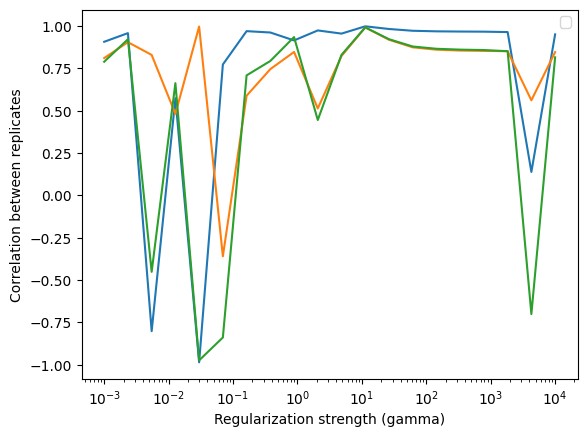

corrs_list: [[np.float64(0.9667651975231268), np.float64(0.9458287210007357), np.float64(0.866406598538559)], [np.float64(0.9518896396664782), np.float64(0.9562264164659708), np.float64(0.842312410155098)], [np.float64(0.9230627106428559), np.float64(0.8905989819215525), np.float64(0.975679674084977)], [np.float64(-0.9481139677684229), np.float64(0.3376432908000615), np.float64(-0.04204919387212355)], [np.float64(0.9829337668997375), np.float64(0.938180363530373), np.float64(0.9025606014847377)], [np.float64(0.9955496948361422), np.float64(0.9859506099931306), np.float64(0.9869458779726501)], [np.float64(0.9819976553462874), np.float64(0.81499579487973), np.float64(0.7971170779418265)], [np.float64(0.9684336024278897), np.float64(0.8624888727213439), np.float64(0.7770017023171318)], [np.float64(0.9984548436029412), np.float64(0.9867562697832466), np.float64(0.9917406789488808)], [np.float64(0.9659634820771867), np.float64(0.9438152531281869), np.float64(0.9590896595957454)], [np.float6

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


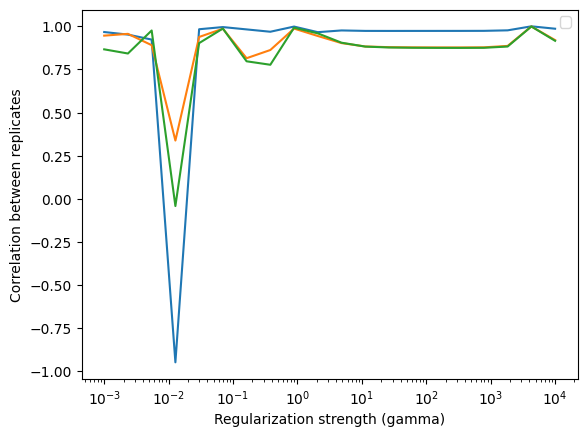

corrs_list: [[np.float64(0.9732432349894171), np.float64(0.43230901310859815), np.float64(0.4978002779411701)], [np.float64(0.9963529734154908), np.float64(0.008552667548005238), np.float64(0.04841225469676867)], [np.float64(0.9718023422838246), np.float64(0.5378066007201339), np.float64(0.449640629512832)], [np.float64(0.9889704872610581), np.float64(0.6856517759187027), np.float64(0.6075603594359823)], [np.float64(0.9829431671839561), np.float64(0.6628115006403064), np.float64(0.6141880775893914)], [np.float64(-0.7579895761784926), np.float64(-0.39334060485450995), np.float64(0.7217167055551921)], [np.float64(0.9859650419244446), np.float64(0.9555058181061868), np.float64(0.9043695104552866)], [np.float64(0.9624201307775049), np.float64(0.8855490187073681), np.float64(0.926237386954775)], [np.float64(0.985512552735293), np.float64(0.6737627227401544), np.float64(0.6098768108417059)], [np.float64(0.8222536748889442), np.float64(0.06558924859720995), np.float64(0.40281633231160074)], [

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


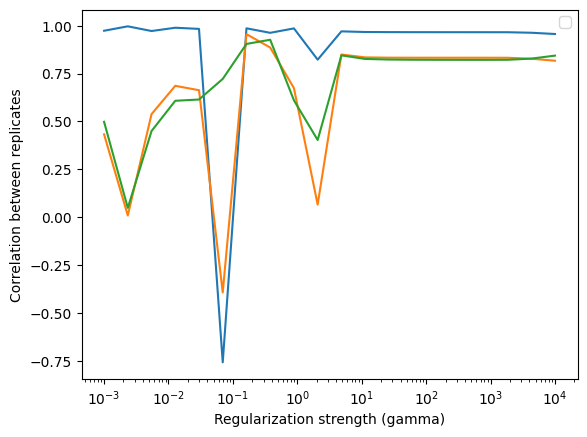

corrs_list: [[np.float64(-0.5593472447515282), np.float64(0.9333119569330792), np.float64(-0.26625381775647766)], [np.float64(-0.9888012295980783), np.float64(0.9999524884196833), np.float64(-0.9898556609833207)], [np.float64(0.9389479386704438), np.float64(0.9571664217440774), np.float64(0.8901208990982942)], [np.float64(0.9996659500997368), np.float64(0.9980823567363937), np.float64(0.9976053677159704)], [np.float64(0.9835665204055877), np.float64(0.8816878955816373), np.float64(0.8962730484711514)], [np.float64(0.9789954627225375), np.float64(0.7948693013725232), np.float64(0.8465020134841067)], [np.float64(0.9942969467820112), np.float64(0.9410698630675286), np.float64(0.9459560325633343)], [np.float64(0.9685479619436951), np.float64(0.8572648612983251), np.float64(0.7210712218189639)], [np.float64(0.9268450001100039), np.float64(0.8942476653671185), np.float64(0.943489508058168)], [np.float64(0.9719930309883135), np.float64(0.8049799913545685), np.float64(0.7941374492773019)], [np

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


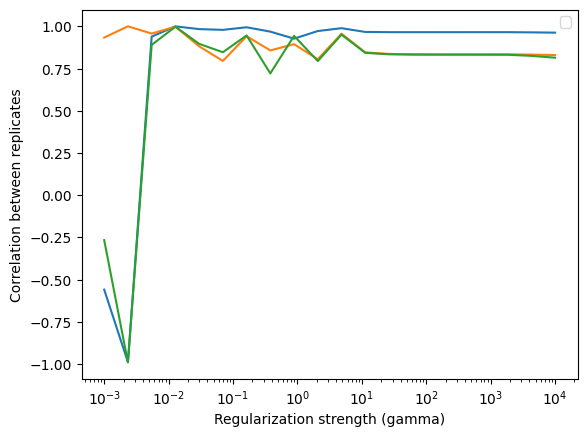

corrs_list: [[np.float64(0.9748263599117044), np.float64(0.9511197585524842), np.float64(0.9180471598551313)], [np.float64(0.961660714344128), np.float64(0.9386838452322304), np.float64(0.9574338629558887)], [np.float64(0.9372741958488142), np.float64(0.9439382989373457), np.float64(0.8786457203840567)], [np.float64(-0.998568075261302), np.float64(0.9907840895332759), np.float64(-0.982718008032003)], [np.float64(0.9900646738812836), np.float64(0.9983566795661112), np.float64(0.995831455661639)], [np.float64(0.995727718107819), np.float64(0.9538141811562405), np.float64(0.9637159134670972)], [np.float64(0.985953070922313), np.float64(0.8999501094331651), np.float64(0.8758340692757536)], [np.float64(0.9900309112366742), np.float64(0.9686015716506687), np.float64(0.9470716125457175)], [np.float64(0.989802086396347), np.float64(0.946948196468983), np.float64(0.9463436937834747)], [np.float64(0.9979603722157361), np.float64(0.9938485102359209), np.float64(0.9970992881854056)], [np.float64(0

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


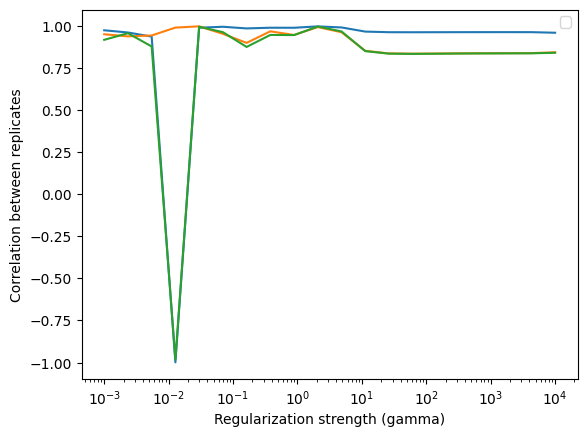

corrs_list: [[np.float64(0.9671618219748779), np.float64(0.834012255527102), np.float64(0.8751125317178703)], [np.float64(0.9885721152183973), np.float64(0.9315518008990827), np.float64(0.9418579775672402)], [np.float64(0.9935015492965076), np.float64(0.9814753002042479), np.float64(0.9794658835877242)], [np.float64(0.9054727019219896), np.float64(0.9629893033407024), np.float64(0.7986461465106148)], [np.float64(0.9870119070250325), np.float64(0.9785254135167898), np.float64(0.9922029779588457)], [np.float64(0.9272463458180986), np.float64(0.648633870348583), np.float64(0.4903839120565169)], [np.float64(0.9869337599203765), np.float64(0.8775131209533716), np.float64(0.8970803185534414)], [np.float64(0.9521373576625985), np.float64(0.8691625956193104), np.float64(0.9199446679630452)], [np.float64(0.9906299945928226), np.float64(0.9657573952204332), np.float64(0.9320948356651448)], [np.float64(0.994507974112997), np.float64(0.9551479202971662), np.float64(0.9648832579748202)], [np.float6

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


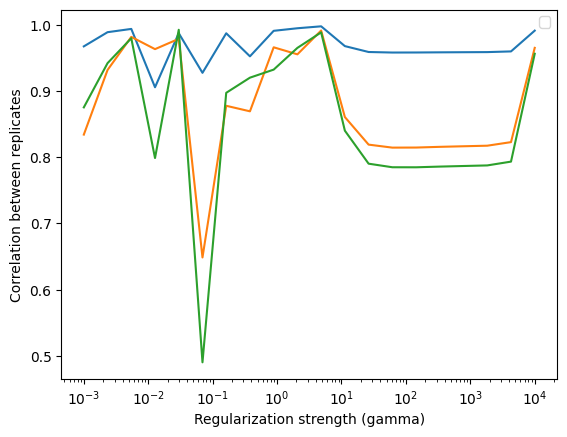

corrs_list: [[np.float64(0.9505282623460786), np.float64(0.7936332251551249), np.float64(0.6102592291032629)], [np.float64(0.9561921276883174), np.float64(0.7393063594855123), np.float64(0.567304242322438)], [np.float64(0.9910716834266611), np.float64(0.8975394821545013), np.float64(0.8901773809774166)], [np.float64(0.7436512608740442), np.float64(0.7438663655610445), np.float64(0.2774752393154366)], [np.float64(0.9991042846598932), np.float64(-0.9567060538005752), np.float64(-0.9656362564354346)], [np.float64(0.9279052239113884), np.float64(0.9632541441549771), np.float64(0.8939563742687444)], [np.float64(0.9436873732995135), np.float64(0.095357092694559), np.float64(-0.055678174621776294)], [np.float64(0.9897273195821799), np.float64(0.8147452376674028), np.float64(0.8207440571170702)], [np.float64(0.9997517579809782), np.float64(0.9987448052805891), np.float64(0.9979875875400664)], [np.float64(0.9901279878923831), np.float64(0.9036853853755139), np.float64(0.9001448057331125)], [np.

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


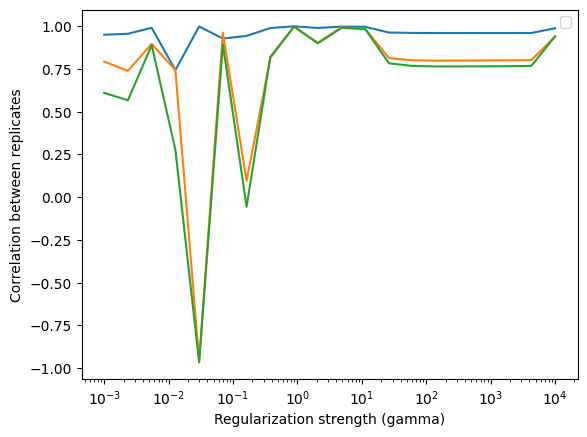

corrs_list: [[np.float64(0.8763318713288599), np.float64(0.632875987485565), np.float64(0.7136406747863906)], [np.float64(0.906495212652576), np.float64(0.6586724111552776), np.float64(0.7015836270266727)], [np.float64(0.8750865286482954), np.float64(0.5088848832519429), np.float64(0.6344434624557806)], [np.float64(0.9819797436408835), np.float64(0.13842012992250474), np.float64(0.11191538257027839)], [np.float64(0.9759386728895174), np.float64(0.6103828021622901), np.float64(0.7429596282189443)], [np.float64(0.9457263521581987), np.float64(0.774518595296417), np.float64(0.7993770466004755)], [np.float64(0.8314036567734824), np.float64(0.6620803319995197), np.float64(0.6460189829512024)], [np.float64(0.8378951254507863), np.float64(0.8924374799745971), np.float64(0.5671372259303581)], [np.float64(0.9771494162522336), np.float64(0.9298809078339858), np.float64(0.9305054966579508)], [np.float64(0.9971215539889342), np.float64(0.7747321442052431), np.float64(0.753128085941344)], [np.float

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


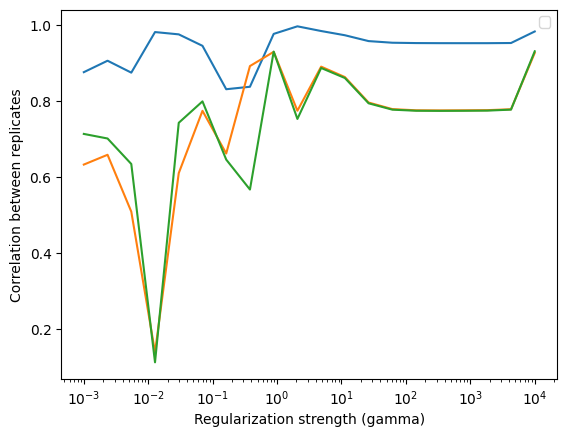

corrs_list: [[np.float64(0.9858454886363405), np.float64(0.40844381154084075), np.float64(0.434950279085406)], [np.float64(0.99130244259974), np.float64(0.35086166701972554), np.float64(0.37909410482017564)], [np.float64(0.9997086676087684), np.float64(0.4376593333965761), np.float64(0.42013504252564937)], [np.float64(0.9491960968498674), np.float64(0.5931040825903873), np.float64(0.5118142832019557)], [np.float64(0.9456721186709449), np.float64(0.9030216148837027), np.float64(0.8689245602350408)], [np.float64(0.9934962098285061), np.float64(0.8927073078286637), np.float64(0.8637894151695746)], [np.float64(0.9910041713179116), np.float64(0.9631883297521382), np.float64(0.9429158991115452)], [np.float64(0.9831935787345634), np.float64(0.8006361789528715), np.float64(0.7741339851530724)], [np.float64(0.9815580244971281), np.float64(0.8820254839132177), np.float64(0.8587764231402046)], [np.float64(0.9325446977498226), np.float64(0.4603901821940906), np.float64(0.43912512258163944)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


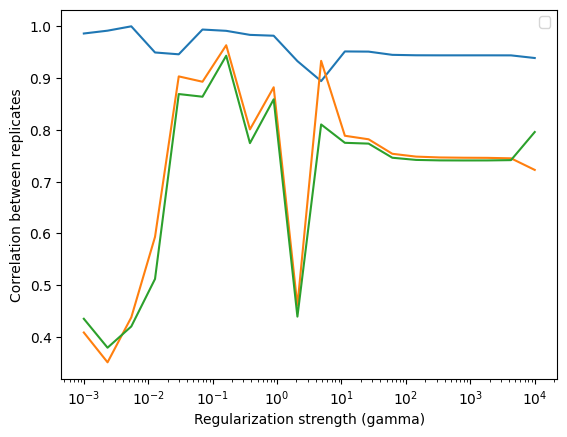

corrs_list: [[np.float64(0.9282054770566683), np.float64(0.793410458168551), np.float64(0.7736474923825025)], [np.float64(0.7849368143287706), np.float64(0.5325255099595105), np.float64(0.5126349462360927)], [np.float64(0.9054221556019582), np.float64(0.6352280199713249), np.float64(0.7331460227687787)], [np.float64(0.9370232539581592), np.float64(0.803678173246788), np.float64(0.7884507832797507)], [np.float64(0.9696863023893947), np.float64(0.911613077242702), np.float64(0.9415624107062472)], [np.float64(0.9970272442074541), np.float64(0.6612785268488977), np.float64(0.6411281043912421)], [np.float64(0.978072406556423), np.float64(0.5244368947317565), np.float64(0.4858873094135244)], [np.float64(0.9697011067594103), np.float64(0.8023881698462371), np.float64(0.7200414525098903)], [np.float64(0.9267193343160294), np.float64(0.7543924471517343), np.float64(0.8196991099334212)], [np.float64(0.7544284823916791), np.float64(0.7960489283126686), np.float64(0.614293778771602)], [np.float64(

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


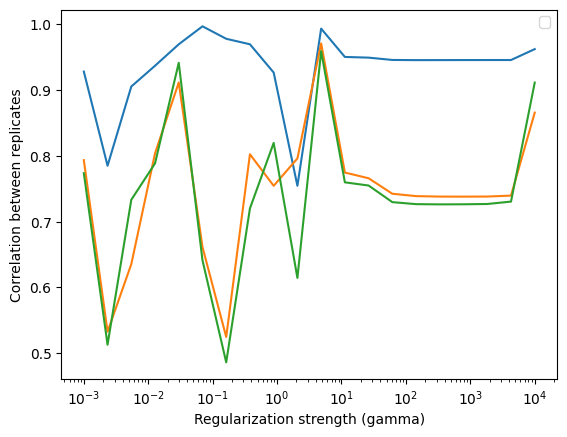

corrs_list: [[np.float64(0.9263566256679436), np.float64(0.6892617971460178), np.float64(0.7799160874279729)], [np.float64(0.9273835660202052), np.float64(0.638460128247831), np.float64(0.6915741059183447)], [np.float64(0.9503486525835063), np.float64(0.4652904192881312), np.float64(0.427149813251358)], [np.float64(-0.9418968997527429), np.float64(0.9921084067404772), np.float64(-0.9540957580897712)], [np.float64(0.9771681528663623), np.float64(0.7796819828232736), np.float64(0.7471511772861514)], [np.float64(0.983548848408144), np.float64(0.7667567496985052), np.float64(0.7832140998989491)], [np.float64(0.9361364931987767), np.float64(0.7452798194270229), np.float64(0.6632656584553802)], [np.float64(0.7240354246825672), np.float64(0.6177845173513823), np.float64(0.33184521743048573)], [np.float64(0.9800599730320831), np.float64(0.8269237181553343), np.float64(0.815007821348358)], [np.float64(0.8796288962881375), np.float64(0.16443686242444247), np.float64(0.200611656123517)], [np.floa

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


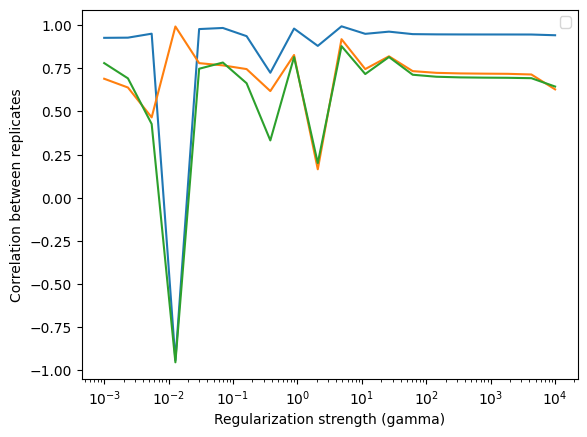

corrs_list: [[np.float64(0.8993732220352314), np.float64(0.7652844030470185), np.float64(0.6300994588413765)], [np.float64(0.9025718364450677), np.float64(0.7589663044207207), np.float64(0.6234801587606456)], [np.float64(0.8994580873614348), np.float64(0.7397784387907582), np.float64(0.5777316568824583)], [np.float64(0.6364282388907792), np.float64(0.39868956858426247), np.float64(-0.3630359302249378)], [np.float64(0.9670486272344839), np.float64(0.8649817956777863), np.float64(0.8003446009544114)], [np.float64(0.9657303297252934), np.float64(0.9676726365070453), np.float64(0.8839199740000967)], [np.float64(-0.9191507824358259), np.float64(-0.9778695474673462), np.float64(0.9346766557479197)], [np.float64(0.9352140945845973), np.float64(-0.21265352596860165), np.float64(-0.21116900348717735)], [np.float64(0.9909509557379026), np.float64(-0.2648671874844257), np.float64(-0.2906570909057272)], [np.float64(0.9764076863158251), np.float64(0.8829496451652618), np.float64(0.8648145970099377)

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


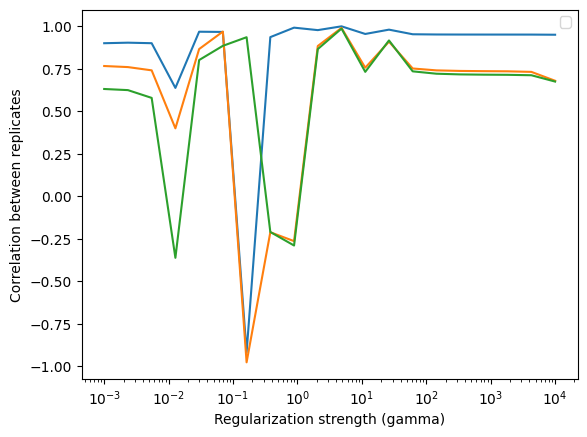

corrs_list: [[np.float64(0.9918418860816037), np.float64(0.8476748916983101), np.float64(0.8134657609441938)], [np.float64(0.9979888067179322), np.float64(0.7913144509366189), np.float64(0.7576296554448201)], [np.float64(0.9861982138276516), np.float64(0.717987541464235), np.float64(0.6002484845338034)], [np.float64(0.9849148442439565), np.float64(0.8852785125194844), np.float64(0.8321005868372323)], [np.float64(0.9975947883761477), np.float64(0.9918628215000342), np.float64(0.9946270080038198)], [np.float64(0.9600478251036035), np.float64(0.7172879248569635), np.float64(0.7730190005104272)], [np.float64(0.943231222185466), np.float64(0.7368783436969741), np.float64(0.5344197953838881)], [np.float64(0.9920486733800084), np.float64(-0.1830016711490078), np.float64(-0.19824292160303014)], [np.float64(0.9794995933656102), np.float64(0.838364689867886), np.float64(0.9225456841427493)], [np.float64(0.03613663934592752), np.float64(0.7758968505688681), np.float64(-0.5328410395981328)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


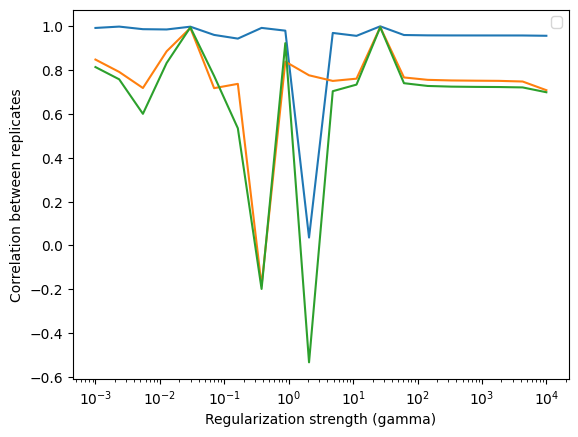

corrs_list: [[np.float64(0.970280747936273), np.float64(0.6250425046311208), np.float64(0.4953865738789851)], [np.float64(0.9947221513125136), np.float64(0.2998170286476775), np.float64(0.2256192310100001)], [np.float64(0.9588618094322715), np.float64(0.7944698942282906), np.float64(0.7822333335284082)], [np.float64(0.9901724290019032), np.float64(0.994123464619838), np.float64(0.9766733246015245)], [np.float64(-0.987429490350796), np.float64(-0.9305570805263158), np.float64(0.9729641817987079)], [np.float64(0.9370269567163482), np.float64(0.22401170734748221), np.float64(0.3890498222339472)], [np.float64(-0.2534402713660402), np.float64(0.9621882411693676), np.float64(-0.44904975693075616)], [np.float64(0.9827202337976608), np.float64(0.8649501584242832), np.float64(0.8275783089217954)], [np.float64(0.9905112526439265), np.float64(0.876395919224446), np.float64(0.8346002052521436)], [np.float64(0.9990558807629063), np.float64(0.9915132940777668), np.float64(0.9868843099800477)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


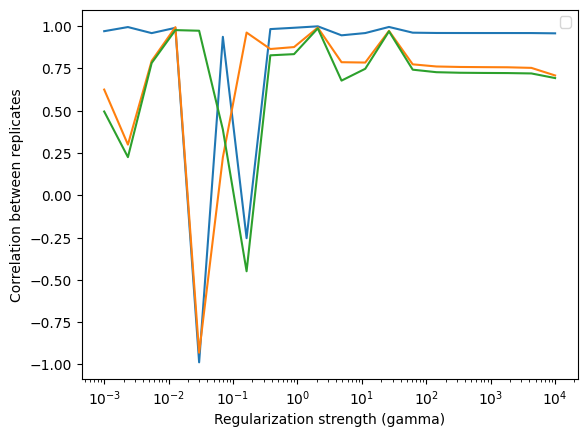

corrs_list: [[np.float64(0.9283527393540291), np.float64(0.9013587837455767), np.float64(0.7726188175431774)], [np.float64(0.930702962711387), np.float64(0.9274922016982876), np.float64(0.8418944589583749)], [np.float64(0.943529240372318), np.float64(0.8923146856008302), np.float64(0.8573734444771544)], [np.float64(0.9983429810196991), np.float64(0.9988620737772969), np.float64(0.9957448341120089)], [np.float64(0.9949466041632525), np.float64(0.9997411518813906), np.float64(0.9938234790637618)], [np.float64(0.9871723032298085), np.float64(0.8875905744449657), np.float64(0.8814488071474034)], [np.float64(0.7425683765976019), np.float64(0.9118613170390768), np.float64(0.94673031409328)], [np.float64(0.8757163926259572), np.float64(0.9223525251160282), np.float64(0.7679214366282703)], [np.float64(0.9824012361142238), np.float64(0.9331963525953835), np.float64(0.8888358977716817)], [np.float64(0.9870378145248524), np.float64(0.9292318678164455), np.float64(0.9025728773960049)], [np.float64

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


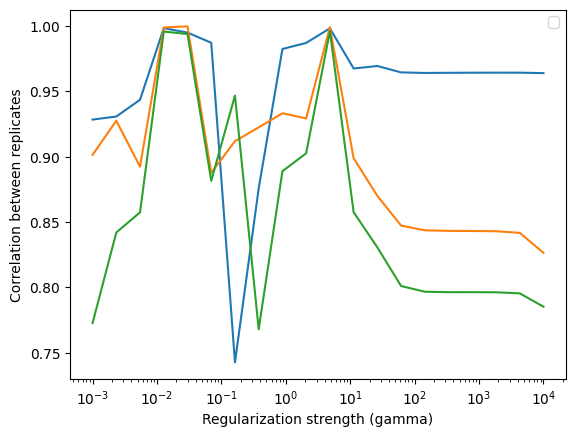

corrs_list: [[np.float64(0.9868151309981987), np.float64(0.945364182369647), np.float64(0.908363799954342)], [np.float64(0.9921370637966456), np.float64(0.9536251703945489), np.float64(0.9249418256578925)], [np.float64(0.9887943206633425), np.float64(0.8732286140641647), np.float64(0.805718721812221)], [np.float64(0.9970043360647403), np.float64(0.9844327743930779), np.float64(0.9751404022708788)], [np.float64(0.9977631590229353), np.float64(0.9995912334647702), np.float64(0.9966043991460031)], [np.float64(0.9023270216899696), np.float64(0.915387494592552), np.float64(0.9240759575449303)], [np.float64(0.9824161525503542), np.float64(0.9646403871630698), np.float64(0.9365412077608477)], [np.float64(0.9924514384820554), np.float64(0.9599839101609943), np.float64(0.9686104356959805)], [np.float64(0.9977671865657384), np.float64(0.9563019298212974), np.float64(0.9603017551149955)], [np.float64(0.991134476926724), np.float64(0.9862894444985085), np.float64(0.9801522838211943)], [np.float64(

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


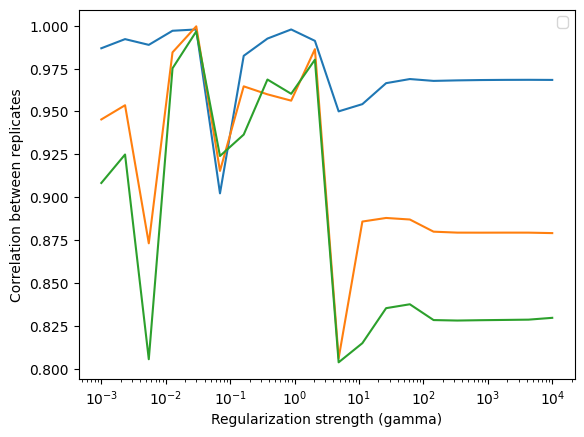

corrs_list: [[np.float64(0.9769712798792365), np.float64(0.9123553771496695), np.float64(0.8590430223926422)], [np.float64(0.9648138717528926), np.float64(0.8913118005845034), np.float64(0.82270949886054)], [np.float64(0.9066769627565758), np.float64(0.8336363789851452), np.float64(0.7269286361836407)], [np.float64(0.614826793091278), np.float64(0.6577743149887845), np.float64(0.4751906832393916)], [np.float64(0.9155585673009904), np.float64(0.9953958887160873), np.float64(0.8789302823796391)], [np.float64(0.9942433466086962), np.float64(0.8890618252250416), np.float64(0.8602949974065711)], [np.float64(0.9645696839760074), np.float64(0.5422650275082136), np.float64(0.44864142304935317)], [np.float64(0.9908997902277512), np.float64(0.9252472307659915), np.float64(0.9200257414949)], [np.float64(0.9985160803189471), np.float64(0.9978138397470713), np.float64(0.9934101324216549)], [np.float64(0.994163033871035), np.float64(0.9727951811771942), np.float64(0.9561763907579085)], [np.float64(0

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


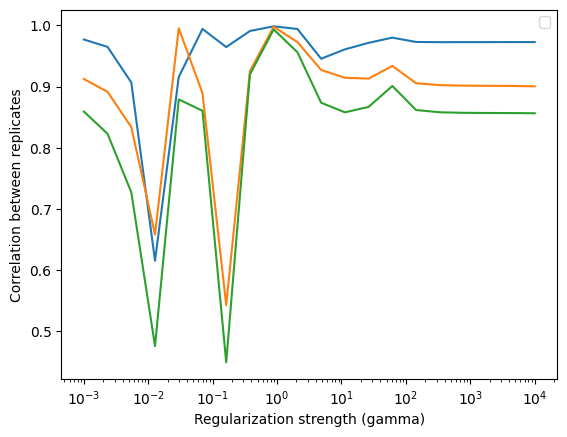

corrs_list: [[np.float64(0.9412932096937343), np.float64(0.919141500145688), np.float64(0.7612182814839816)], [np.float64(0.89448158805698), np.float64(0.9320749057609883), np.float64(0.700566551333629)], [np.float64(0.8145189744598683), np.float64(0.984468911182467), np.float64(0.7113360485439635)], [np.float64(0.9560130304937129), np.float64(0.9223146174322336), np.float64(0.7757335423208235)], [np.float64(0.9776521791992776), np.float64(0.8326597662288472), np.float64(0.7192862784230516)], [np.float64(0.9968989921218482), np.float64(0.9716609173411286), np.float64(0.9675148217627334)], [np.float64(0.9630454656826782), np.float64(0.9861049966338277), np.float64(0.9218000439007256)], [np.float64(0.9056350426753498), np.float64(0.9231192705665087), np.float64(0.8697631951087431)], [np.float64(0.9948419655573768), np.float64(0.9861276877040603), np.float64(0.9741881000705345)], [np.float64(0.9998590662096927), np.float64(0.9990176745021953), np.float64(0.9987633226695781)], [np.float64(

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


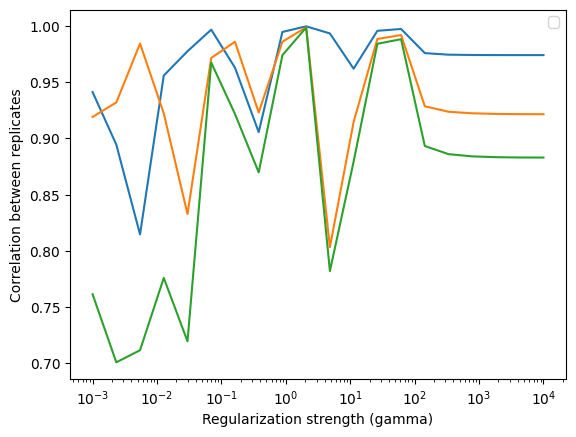

corrs_list: [[np.float64(-0.998321332324513), np.float64(0.9997472817552719), np.float64(-0.9970232850902055)], [np.float64(0.9987270884209827), np.float64(0.9885410197846528), np.float64(0.9924384913122442)], [np.float64(-0.9973419006207228), np.float64(0.9999356931385612), np.float64(-0.9971729692540904)], [np.float64(0.9662539168736531), np.float64(0.8552710772120075), np.float64(0.785004638731676)], [np.float64(0.9987764131495822), np.float64(0.9567687342621716), np.float64(0.9458667499414448)], [np.float64(0.9535527784407631), np.float64(0.9562755352407185), np.float64(0.8996297877031885)], [np.float64(0.9711532981763757), np.float64(0.9300877709679026), np.float64(0.8956616216796154)], [np.float64(0.9648079140296445), np.float64(0.9615465334559815), np.float64(0.9142023942982267)], [np.float64(0.9772969571614929), np.float64(0.948144424370954), np.float64(0.9195153927343656)], [np.float64(0.9894892552848226), np.float64(0.9698775671284225), np.float64(0.9567760457936803)], [np.fl

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


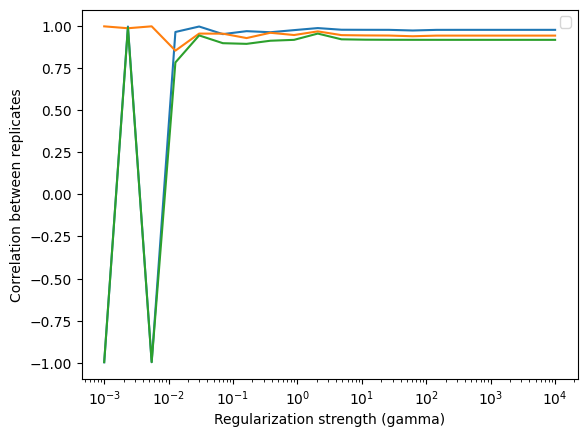

Dataset: BF520
corrs_list: [[np.float64(0.8799167349394315), np.float64(0.9772702530554367), np.float64(0.842871351753308)], [np.float64(0.9975514383134496), np.float64(0.9931028183353524), np.float64(0.993274266428142)], [np.float64(0.9892262199796069), np.float64(0.8988619647066605), np.float64(0.9251713009746542)], [np.float64(0.967767151763642), np.float64(0.9846869535272496), np.float64(0.9754866387388352)], [np.float64(0.9966133739053937), np.float64(0.9980323054694611), np.float64(0.9949084407700759)], [np.float64(0.9601672392345458), np.float64(0.963923837163832), np.float64(0.9560229380146456)], [np.float64(0.9650069864379938), np.float64(0.9643796182914329), np.float64(0.9583605626344285)], [np.float64(0.9665231996706884), np.float64(0.9629386482873077), np.float64(0.9568936110665128)], [np.float64(0.9668447708207789), np.float64(0.9669316954041227), np.float64(0.9599184040947543)], [np.float64(0.9669770961914013), np.float64(0.9671107355664594), np.float64(0.9601477029289152

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


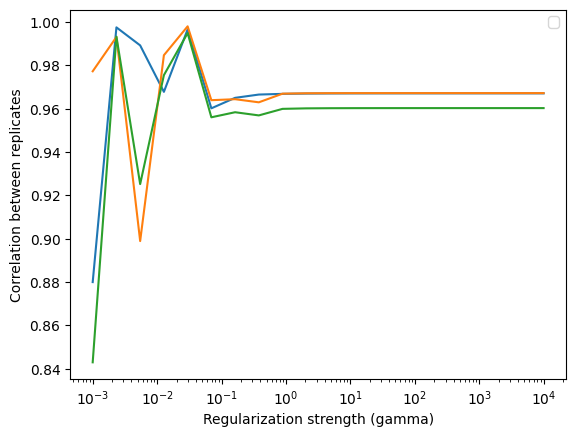

corrs_list: [[np.float64(0.9901203557780014), np.float64(0.980512264215039), np.float64(0.9575387479359323)], [np.float64(0.9778401754941419), np.float64(0.9758250196181684), np.float64(0.9242849905459329)], [np.float64(0.8915610738822976), np.float64(0.9600988143303579), np.float64(0.7458207025856325)], [np.float64(0.9135199732881812), np.float64(0.9834176075970305), np.float64(0.972015734674549)], [np.float64(0.9823996904110988), np.float64(0.9624196135360283), np.float64(0.983533169089728)], [np.float64(0.9881209764707742), np.float64(0.9491018046989764), np.float64(0.9719757667077245)], [np.float64(0.9932188263007301), np.float64(0.9355558358812024), np.float64(0.9121309458174063)], [np.float64(0.9952894119032267), np.float64(0.9655178939487099), np.float64(0.9588724408482364)], [np.float64(0.9945375431538817), np.float64(0.9839142256377547), np.float64(0.9882664718253052)], [np.float64(0.9735041943504836), np.float64(0.9273463025137245), np.float64(0.8743603017590014)], [np.float6

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


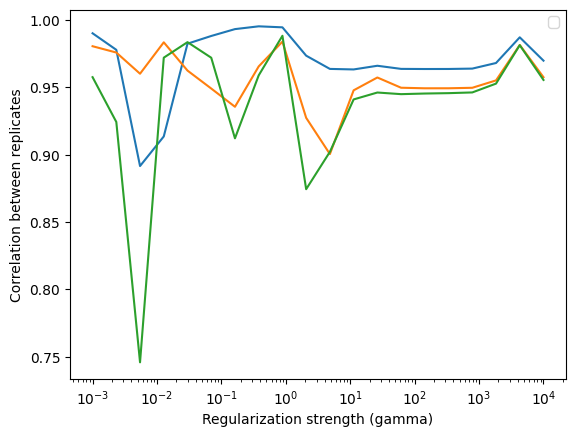

corrs_list: [[np.float64(0.9637846351253384), np.float64(0.9530123813242701), np.float64(0.9459788503131359)], [np.float64(0.9994542332027292), np.float64(0.9994639435703013), np.float64(0.9999467106898315)], [np.float64(0.8964864930538785), np.float64(0.2939506922601707), np.float64(0.6564723417027086)], [np.float64(0.979663450825917), np.float64(0.9826394704834613), np.float64(0.9949381899654468)], [np.float64(0.6531957151636488), np.float64(0.9681234392750078), np.float64(0.6758088105874528)], [np.float64(0.7453406781908274), np.float64(0.15947745148826425), np.float64(-0.5084102340113165)], [np.float64(0.9906607923122964), np.float64(0.9084643141275441), np.float64(0.8996250419739557)], [np.float64(0.9920086157131182), np.float64(0.9956329416591095), np.float64(0.997335961518469)], [np.float64(0.9998601901020425), np.float64(0.9997879609319629), np.float64(0.9997764940267988)], [np.float64(0.9828091949001455), np.float64(0.9672352695172282), np.float64(0.9729024915440339)], [np.flo

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


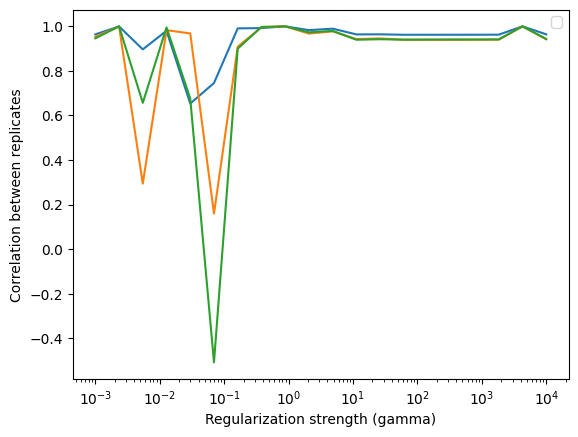

corrs_list: [[np.float64(0.9270044213129304), np.float64(0.9346350976361971), np.float64(0.9424982869881504)], [np.float64(0.9046927801852845), np.float64(0.9527199115033007), np.float64(0.9885576414933658)], [np.float64(0.8542798423299816), np.float64(0.8197770032287308), np.float64(0.8962999182782496)], [np.float64(0.12327180694572014), np.float64(0.5439196410932019), np.float64(0.7890330188079151)], [np.float64(0.7875408539389441), np.float64(0.9827474298648249), np.float64(0.8658126056372042)], [np.float64(0.9339557870506426), np.float64(0.8892701485981769), np.float64(0.8195929537759606)], [np.float64(0.9995590371298959), np.float64(0.9686511508066294), np.float64(0.9726776818374813)], [np.float64(0.9574209111166926), np.float64(0.3347534342198082), np.float64(0.5183223036732613)], [np.float64(0.9985882676295659), np.float64(0.993534461778224), np.float64(0.9967912320139646)], [np.float64(0.9003790736759786), np.float64(0.6754247327667988), np.float64(0.8748758767503277)], [np.flo

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


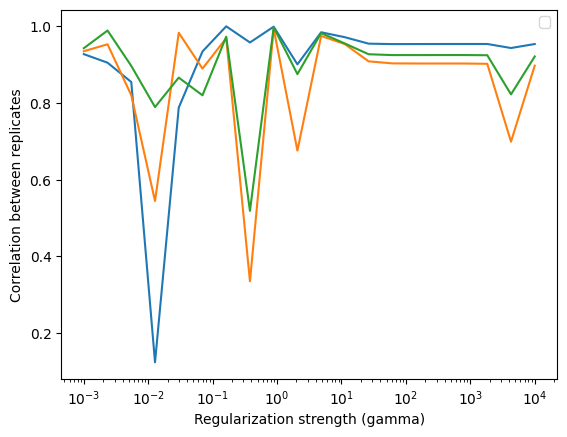

corrs_list: [[np.float64(0.9788942486794131), np.float64(0.9837272425429742), np.float64(0.9661811565162208)], [np.float64(0.974811807880716), np.float64(0.927429879596577), np.float64(0.9462734735698739)], [np.float64(0.9258667238009466), np.float64(0.934315713160396), np.float64(0.8251840941367627)], [np.float64(0.8242304223701593), np.float64(0.9761156311671495), np.float64(0.8606709028514079)], [np.float64(0.9725374200596042), np.float64(0.9368753725455785), np.float64(0.918629615885668)], [np.float64(0.7320623214830355), np.float64(0.4532104676990656), np.float64(0.7705994405551679)], [np.float64(0.9970771272220162), np.float64(0.989280314773501), np.float64(0.9915054131164218)], [np.float64(0.9433980444645098), np.float64(0.8488888782866868), np.float64(0.9576827841451236)], [np.float64(0.9600646787696656), np.float64(0.8387333866959479), np.float64(0.9428731757123858)], [np.float64(0.8996776994862037), np.float64(0.7727846156086124), np.float64(0.9011723815285886)], [np.float64(

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


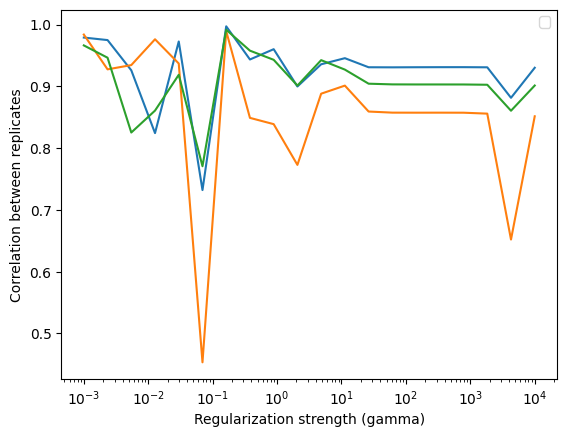

corrs_list: [[np.float64(0.1522301439071801), np.float64(0.8864606139639357), np.float64(-0.22270996370700946)], [np.float64(0.8522548470830015), np.float64(0.7889423464114222), np.float64(0.6212895415649906)], [np.float64(0.18490603844949244), np.float64(0.8065827543540454), np.float64(0.13906292545430382)], [np.float64(0.9060258468472893), np.float64(0.7243051942434209), np.float64(0.9409845544576275)], [np.float64(0.8757821782613411), np.float64(0.7724778316775869), np.float64(0.9115065249617024)], [np.float64(0.9327547228828478), np.float64(-0.5801317158456445), np.float64(-0.47885068398957953)], [np.float64(0.8236814369217041), np.float64(0.7245701255947834), np.float64(0.9579646541421207)], [np.float64(0.9739348247478299), np.float64(0.8572435817070485), np.float64(0.9425261367580974)], [np.float64(0.9920619052306028), np.float64(0.9955103228323339), np.float64(0.9971727308526172)], [np.float64(0.5617621239072927), np.float64(0.5472120552670559), np.float64(0.9029490707294021)], 

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


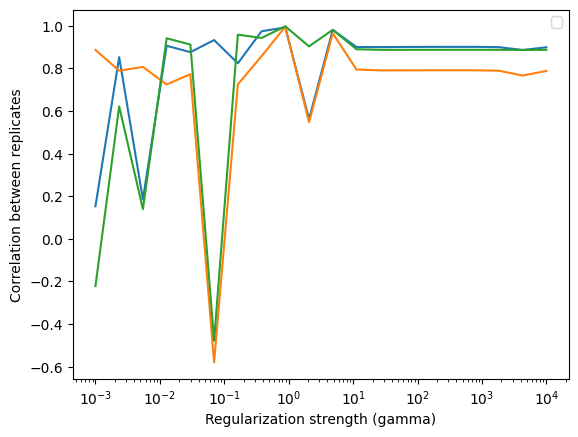

corrs_list: [[np.float64(0.9920528053431039), np.float64(0.9414762782298725), np.float64(0.9741093834056727)], [np.float64(0.9316355801905436), np.float64(0.90457653636414), np.float64(0.9816243656291622)], [np.float64(0.8651899387055954), np.float64(0.7410781539288886), np.float64(0.9393705368854512)], [np.float64(0.48685880951250227), np.float64(-0.5590805833132184), np.float64(0.3137359050728835)], [np.float64(0.891024643957642), np.float64(0.738493707516704), np.float64(0.8964847720387267)], [np.float64(0.7370297353371607), np.float64(0.3454908519651879), np.float64(0.5882496761998228)], [np.float64(0.8936591578104133), np.float64(0.7711211804831389), np.float64(0.8212618255571641)], [np.float64(0.9543475836134264), np.float64(0.8940388177972666), np.float64(0.9456413167533897)], [np.float64(0.9913777579506635), np.float64(0.9639396483543141), np.float64(0.9629537191589643)], [np.float64(0.826781184283995), np.float64(0.5271397007918714), np.float64(0.7838584108870005)], [np.float6

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


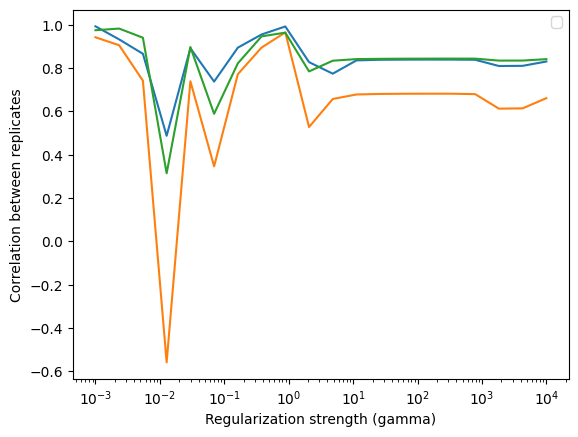

corrs_list: [[np.float64(0.803975807679703), np.float64(-0.3255100327443118), np.float64(0.2601150603967647)], [np.float64(0.9676196616625651), np.float64(0.42398089740160394), np.float64(0.5933914043683114)], [np.float64(-0.975798244348281), np.float64(0.9735196279358037), np.float64(-0.9795568269627776)], [np.float64(0.9488939323805026), np.float64(0.04644572720658027), np.float64(0.3381424252705095)], [np.float64(0.9606054622925488), np.float64(0.9472465738391357), np.float64(0.9838503072848486)], [np.float64(0.9823863976566846), np.float64(0.9650636236210974), np.float64(0.9274635628071821)], [np.float64(0.9015595525890708), np.float64(0.6736905830968615), np.float64(0.8567169614137741)], [np.float64(0.895000449719026), np.float64(0.9777668959668897), np.float64(0.9102150200474521)], [np.float64(0.8659869723172164), np.float64(0.8872406959684187), np.float64(0.6179356688755882)], [np.float64(0.8447074594827737), np.float64(0.7204885339830185), np.float64(0.8251705461281068)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


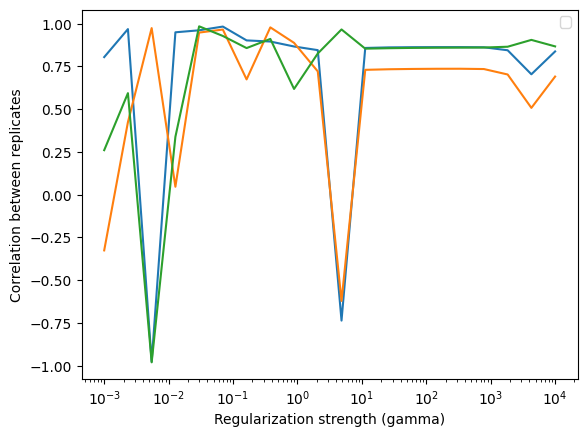

corrs_list: [[np.float64(0.928436051269993), np.float64(0.7433602184965411), np.float64(0.7854584673557709)], [np.float64(-0.9175965128509648), np.float64(-0.9323791224295233), np.float64(0.9991264145837818)], [np.float64(0.8187569350950793), np.float64(0.6591336125720231), np.float64(0.7370008947454196)], [np.float64(-0.9690939509681868), np.float64(-0.9257734999313919), np.float64(0.9847316755828892)], [np.float64(0.969594851967212), np.float64(0.9376920768254692), np.float64(0.9828191679602493)], [np.float64(0.5666884977022071), np.float64(0.8244900162754862), np.float64(0.8980515549153887)], [np.float64(0.8308613740279606), np.float64(0.7505590449907422), np.float64(0.9591369291758435)], [np.float64(0.9740780580078356), np.float64(0.7088308883758385), np.float64(0.758158689907151)], [np.float64(0.9941851986512513), np.float64(0.9995055547977459), np.float64(0.9963741341473854)], [np.float64(0.7410960697589319), np.float64(0.47550603281949577), np.float64(0.7278162471369118)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


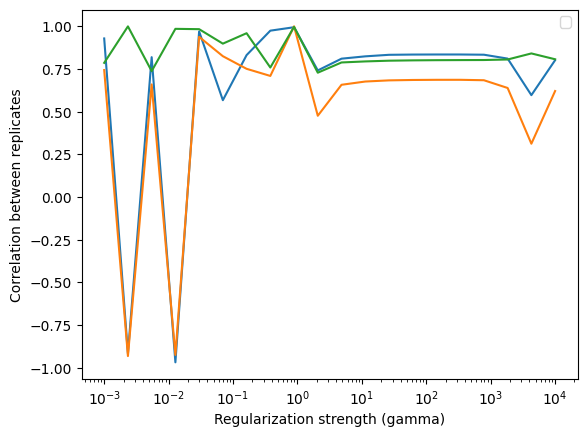

corrs_list: [[np.float64(0.790613584439868), np.float64(0.9918672109362593), np.float64(0.8476788648870196)], [np.float64(-0.387550245465109), np.float64(0.7121404831318432), np.float64(0.3334962222156804)], [np.float64(0.8524346930992657), np.float64(0.9425608378872544), np.float64(0.9542807558968974)], [np.float64(0.3082172838619891), np.float64(-0.3277766028603776), np.float64(-0.12584769551815536)], [np.float64(0.925049009831981), np.float64(0.9448436889987754), np.float64(0.9938427979089489)], [np.float64(-0.7558625531331199), np.float64(0.32807392463694723), np.float64(-0.4722642768589274)], [np.float64(0.9389673038487829), np.float64(0.9632066788341676), np.float64(0.9415656035975888)], [np.float64(0.7492051791602017), np.float64(0.9345849482168718), np.float64(0.7831515610913207)], [np.float64(0.33653026304479305), np.float64(0.6517208990004859), np.float64(0.8070352137360115)], [np.float64(0.12669680272701822), np.float64(0.4723531688410907), np.float64(0.28664604891442913)], 

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


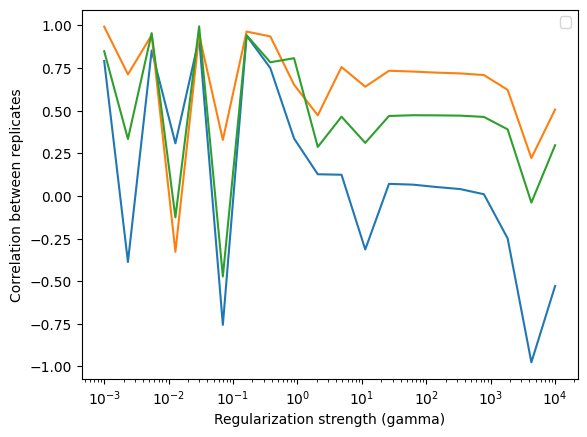

corrs_list: [[np.float64(0.5221501747762382), np.float64(0.7175428701630018), np.float64(0.907370459038536)], [np.float64(0.27301359947778303), np.float64(0.8514521874525611), np.float64(0.627057301424871)], [np.float64(0.6137782787777996), np.float64(0.9673504710331591), np.float64(0.6823712589840886)], [np.float64(0.5358472466663544), np.float64(0.9709146049558774), np.float64(0.5105565484695488)], [np.float64(0.9795612439892646), np.float64(0.9686332114701046), np.float64(0.9858190190824042)], [np.float64(0.45333706789159794), np.float64(0.7432074253918463), np.float64(0.9189947291600798)], [np.float64(-0.9965690311640901), np.float64(-0.9967019202508156), np.float64(0.9978280152299646)], [np.float64(0.6590135846537634), np.float64(0.7585996547847469), np.float64(0.20907302211528028)], [np.float64(0.11405233419284933), np.float64(0.5751321023911338), np.float64(0.0633780148043836)], [np.float64(0.6131587802225531), np.float64(0.8833831493476473), np.float64(0.7903171333007171)], [np

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


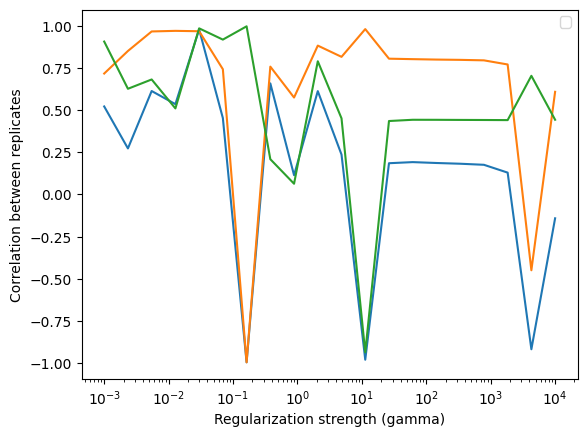

corrs_list: [[np.float64(0.6811338125820505), np.float64(0.6722095040401843), np.float64(0.7807215919699162)], [np.float64(0.5370166864996437), np.float64(0.7342030201312574), np.float64(0.5521530627713435)], [np.float64(-0.20454026217731228), np.float64(0.821158479385776), np.float64(-0.5041837931226371)], [np.float64(0.9790967189134893), np.float64(0.9847930897379515), np.float64(0.9549602500805693)], [np.float64(0.8952775269046696), np.float64(0.9169422252163001), np.float64(0.899975625305756)], [np.float64(0.9321188367721084), np.float64(0.9559896410568496), np.float64(0.9022548200969958)], [np.float64(0.8056961263358708), np.float64(0.10071777569308246), np.float64(-0.004022791398559086)], [np.float64(0.15732763269489608), np.float64(0.9207509054060375), np.float64(0.44480226731789807)], [np.float64(0.909041557708905), np.float64(0.6989604441308876), np.float64(0.430574601494931)], [np.float64(-0.8842916672900715), np.float64(0.99671374102154), np.float64(-0.8669293605574168)], [n

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


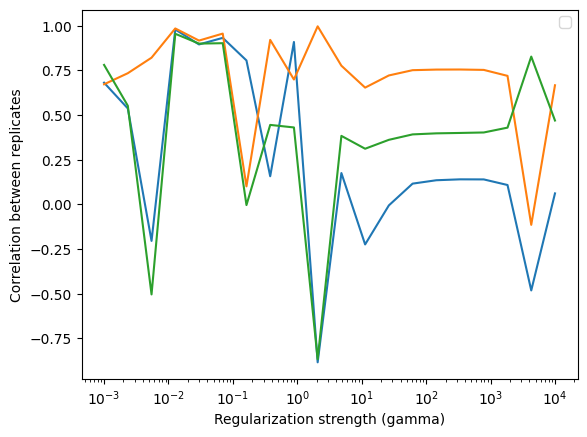

corrs_list: [[np.float64(0.853718962211678), np.float64(0.9549985219797119), np.float64(0.8165959230093551)], [np.float64(0.8873313406981911), np.float64(0.978966845890402), np.float64(0.9051012058488276)], [np.float64(-0.5148398841343544), np.float64(0.6604473709961709), np.float64(0.24618650114519358)], [np.float64(0.7499205115785088), np.float64(0.8817130388000688), np.float64(0.7996394247396404)], [np.float64(-0.4640556416897506), np.float64(-0.5301632314060726), np.float64(0.923368413920565)], [np.float64(-0.1526343134329186), np.float64(0.8852323374533824), np.float64(-0.01780118000703293)], [np.float64(-0.018559786378734427), np.float64(-0.8298242486513919), np.float64(0.015442295094648204)], [np.float64(-0.3354501774343621), np.float64(0.7338953003182609), np.float64(0.037222598560394726)], [np.float64(-0.8270415274616654), np.float64(-0.5730536561555674), np.float64(0.8747685273123192)], [np.float64(-0.6172475035043401), np.float64(0.7627340661448825), np.float64(-0.2209322655

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


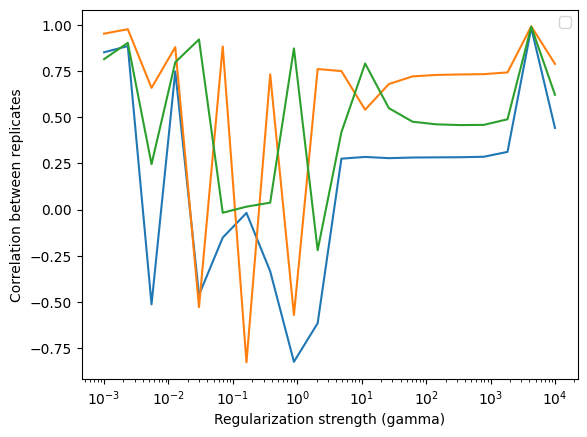

corrs_list: [[np.float64(0.9056607128850502), np.float64(0.9588629936418862), np.float64(0.9654059336716715)], [np.float64(0.994398019518592), np.float64(0.9980028376066223), np.float64(0.9965057484694485)], [np.float64(0.3395930336140306), np.float64(0.8055869361484284), np.float64(0.593600329130089)], [np.float64(0.7836366910354565), np.float64(0.8350771597806584), np.float64(0.9740090379459001)], [np.float64(0.6403849998554851), np.float64(0.8200663832087347), np.float64(0.7345281040956415)], [np.float64(-0.8403343812197532), np.float64(-0.9996431793842875), np.float64(0.84599709996463)], [np.float64(0.9176121883889103), np.float64(0.8928153135326211), np.float64(0.8055566645174116)], [np.float64(0.9860329127029963), np.float64(0.9848479470621773), np.float64(0.9889040611456776)], [np.float64(-0.9836612242860434), np.float64(-0.9910013370298211), np.float64(0.9907419258472219)], [np.float64(0.9672008596285214), np.float64(-0.8840454446411937), np.float64(-0.9229227720064951)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


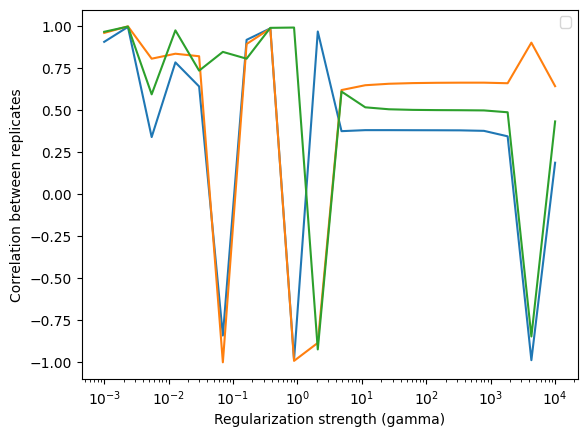

corrs_list: [[np.float64(-0.01668103046498609), np.float64(-0.21099382346043816), np.float64(0.7492805355254293)], [np.float64(-0.09911517564874317), np.float64(0.0628815008349704), np.float64(0.48521308640995175)], [np.float64(-0.9835895003350624), np.float64(-0.9815882658496575), np.float64(0.9990737428304614)], [np.float64(0.11939609733962744), np.float64(0.8736674975023695), np.float64(0.122710568409093)], [np.float64(-0.9542373823094891), np.float64(0.9369349922079204), np.float64(-0.8326505719945732)], [np.float64(0.9372877220485722), np.float64(0.9204390262116755), np.float64(0.9380855326663605)], [np.float64(-0.10086372077043748), np.float64(0.19881847157569105), np.float64(0.7760010979546352)], [np.float64(0.9934441974017747), np.float64(0.9956492598466307), np.float64(0.999401609339988)], [np.float64(-0.30977037475445235), np.float64(0.5711819884231732), np.float64(-0.3856839326519994)], [np.float64(0.7714233673074673), np.float64(0.7375703892646978), np.float64(0.86041457798

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


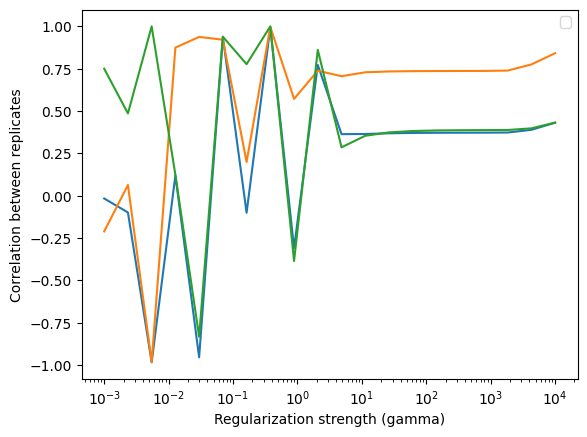

corrs_list: [[np.float64(-0.3969443272501145), np.float64(-0.1099964181965587), np.float64(0.8878469337580736)], [np.float64(0.1521773403971586), np.float64(0.5365130493632025), np.float64(0.7334126976355895)], [np.float64(0.7181233327986527), np.float64(0.8553757106154124), np.float64(0.7473005244636601)], [np.float64(0.6959496223760064), np.float64(0.8548893662322268), np.float64(0.5491914164356492)], [np.float64(0.919302396485541), np.float64(0.9532811243386877), np.float64(0.8491282310451086)], [np.float64(-0.15368259378972177), np.float64(0.09993257144604607), np.float64(0.757568372799576)], [np.float64(-0.9659878254385749), np.float64(0.9970793317015915), np.float64(-0.9531654020637799)], [np.float64(0.8041329203535013), np.float64(0.7290869923143417), np.float64(0.8182604943416409)], [np.float64(0.9808033207203208), np.float64(0.8924327436050743), np.float64(0.8806737022138187)], [np.float64(0.5338144972650838), np.float64(0.8870202934199711), np.float64(0.7770278886095541)], [n

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


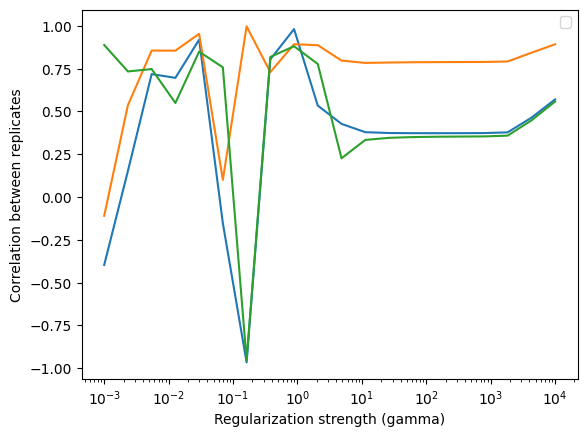

corrs_list: [[np.float64(0.3126763287148426), np.float64(0.6095196747888885), np.float64(0.6858919543407537)], [np.float64(0.9103967634253366), np.float64(0.8668800841894547), np.float64(0.8393350214657628)], [np.float64(0.9162328009260288), np.float64(0.42783553888848697), np.float64(0.4687003711397925)], [np.float64(0.6785569502764339), np.float64(0.4615966427980134), np.float64(0.05806924748626424)], [np.float64(0.6468047045530156), np.float64(0.8422672961128421), np.float64(0.6890378095745402)], [np.float64(0.5530561085956844), np.float64(0.9917323088759485), np.float64(0.4886118002854356)], [np.float64(0.06830483401803916), np.float64(0.8201124800704068), np.float64(0.014346503602153504)], [np.float64(0.9413532876555748), np.float64(0.9681771117094579), np.float64(0.9641552277948031)], [np.float64(0.9635658997181019), np.float64(0.9599222383744118), np.float64(0.9579298408845918)], [np.float64(0.8538574323132966), np.float64(0.5964495084123163), np.float64(0.31132037937433743)], [

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


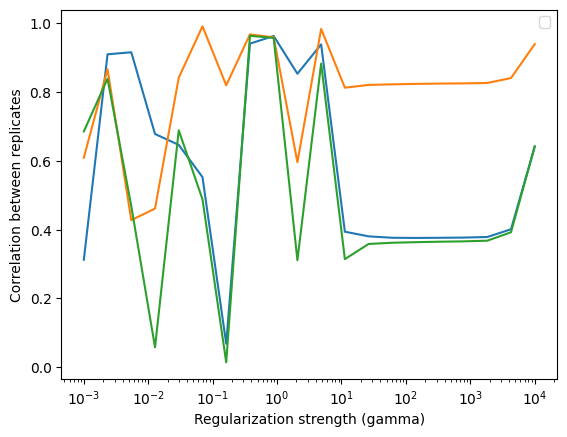

corrs_list: [[np.float64(0.3344434819831836), np.float64(0.875546144904444), np.float64(0.053153491561074406)], [np.float64(0.6061606183886096), np.float64(0.8533650270469265), np.float64(0.31463642100798456)], [np.float64(0.9564012356677579), np.float64(0.9515281604963778), np.float64(0.8853385908323197)], [np.float64(0.8018311342988497), np.float64(0.8194802222668598), np.float64(0.5684164484555524)], [np.float64(-0.7073146186549104), np.float64(0.903732232843463), np.float64(-0.7554084349386978)], [np.float64(0.8763720229454215), np.float64(0.8615545824316636), np.float64(0.7296977039310207)], [np.float64(0.2953566939618879), np.float64(0.9123232441018914), np.float64(0.15273335286002057)], [np.float64(-0.7548939125844744), np.float64(0.8805715261501449), np.float64(-0.5639479967512844)], [np.float64(0.0950083376030543), np.float64(0.9364076176514892), np.float64(0.10868316161423769)], [np.float64(0.8906049466033797), np.float64(0.931496869172903), np.float64(0.9870623648398105)], [

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


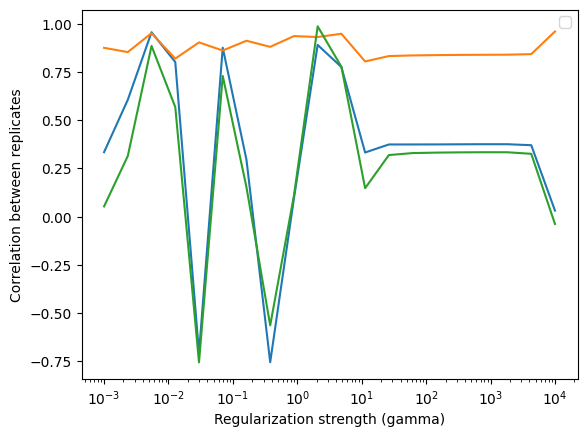

corrs_list: [[np.float64(0.42288228558111496), np.float64(0.5690990967689546), np.float64(0.745516450128358)], [np.float64(0.409250475389319), np.float64(0.473206725404957), np.float64(0.8402202039430107)], [np.float64(0.7429238504395924), np.float64(0.7283050653749255), np.float64(0.9990330903098836)], [np.float64(0.661730807331355), np.float64(0.936912556576737), np.float64(0.403367264795249)], [np.float64(0.7256997552219278), np.float64(0.8857779218898372), np.float64(0.8205034208085176)], [np.float64(0.6558919525234069), np.float64(0.9132928140296112), np.float64(0.7197048487191023)], [np.float64(0.18885685570462643), np.float64(0.671444600878951), np.float64(-0.08355960806140095)], [np.float64(0.8892495120391927), np.float64(0.9488121280653103), np.float64(0.8589094905435785)], [np.float64(0.36131360712067334), np.float64(0.7049801538226924), np.float64(0.8715951581258735)], [np.float64(0.6923416968546368), np.float64(0.6833050841722638), np.float64(0.024412226492470147)], [np.flo

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


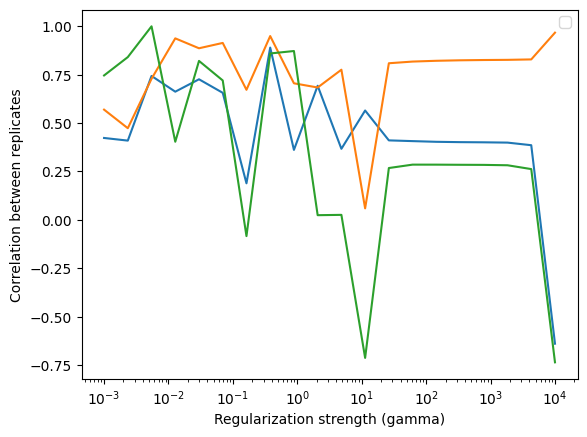

corrs_list: [[np.float64(-0.713376946693203), np.float64(0.997081318349433), np.float64(-0.7366144888247425)], [np.float64(0.30564247352716867), np.float64(0.8379193993565177), np.float64(0.24381913692023613)], [np.float64(0.01263327782804921), np.float64(0.6945270471667628), np.float64(-0.07868153441124429)], [np.float64(-0.7637300938756988), np.float64(0.902375749425786), np.float64(-0.9485545332908777)], [np.float64(-0.10667951274801236), np.float64(0.8303843560780003), np.float64(-0.12589987075752124)], [np.float64(0.16248294313285366), np.float64(0.8792903687793694), np.float64(-0.0634076335837587)], [np.float64(0.8184791711331179), np.float64(0.8116750459897789), np.float64(0.5107028563402339)], [np.float64(0.9712755091216982), np.float64(0.9771790298780617), np.float64(0.9974850548143643)], [np.float64(0.4475585675340501), np.float64(0.821694330461481), np.float64(0.42972121120117823)], [np.float64(-0.2666455389082618), np.float64(0.16341816774988296), np.float64(0.4728635699718

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


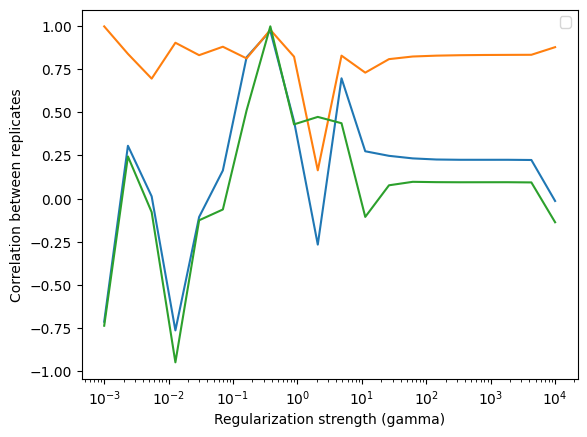

corrs_list: [[np.float64(0.3422055796228618), np.float64(0.4288511954082217), np.float64(0.4667718277433759)], [np.float64(0.4113369590139454), np.float64(0.5262279207450347), np.float64(0.3138079648675658)], [np.float64(0.48712304277851376), np.float64(0.6073043536503127), np.float64(0.16952863957727854)], [np.float64(0.9393114987925552), np.float64(0.4552778560022976), np.float64(0.22672151406120483)], [np.float64(0.9579834780864017), np.float64(0.9744549784191969), np.float64(0.9913877307539858)], [np.float64(-0.5689592811034272), np.float64(0.6807163959557944), np.float64(-0.9367500960201895)], [np.float64(0.3237555308846352), np.float64(0.8930076657063127), np.float64(0.4994372350731324)], [np.float64(0.15019254066736995), np.float64(0.8256695590457286), np.float64(-0.017661600144277603)], [np.float64(0.15051853905112228), np.float64(0.22871724137266977), np.float64(0.11439292695436143)], [np.float64(-0.996222593446909), np.float64(0.9989738043987948), np.float64(-0.99700478291348

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


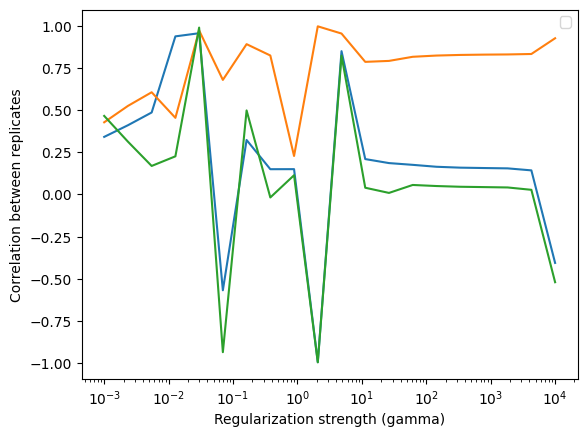

corrs_list: [[np.float64(0.2375263360933683), np.float64(0.7051932380012149), np.float64(0.7309044706163439)], [np.float64(0.3480655251388096), np.float64(0.7468074180772842), np.float64(0.7511526301145068)], [np.float64(0.45453573581385776), np.float64(0.722976203615408), np.float64(0.8828002908821053)], [np.float64(0.5446947135693627), np.float64(0.7835224511708677), np.float64(0.7970766772459705)], [np.float64(0.6123781124366439), np.float64(0.9543837888920412), np.float64(0.6125786477630133)], [np.float64(0.29935427606830584), np.float64(0.8177340893335636), np.float64(0.35908956681113424)], [np.float64(0.4122271679750264), np.float64(0.958644500032695), np.float64(0.4347756461070838)], [np.float64(0.2738516905037461), np.float64(0.7308816894247978), np.float64(-0.2534267893065527)], [np.float64(-0.7208709848760464), np.float64(0.6118601199899497), np.float64(-0.6618728766047495)], [np.float64(0.38193905496057773), np.float64(-0.7240733460243495), np.float64(-0.3249250634379901)], 

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


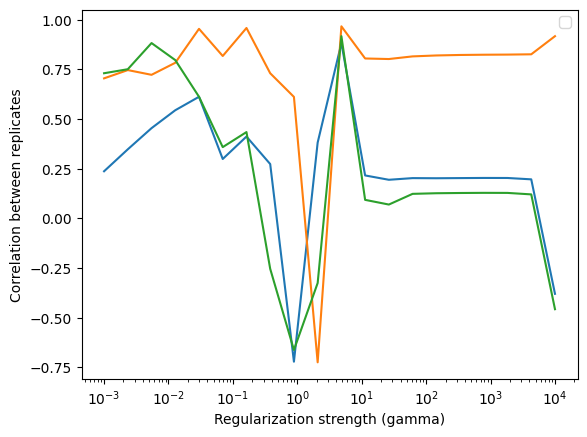

corrs_list: [[np.float64(0.8710439205323914), np.float64(0.9101135990874689), np.float64(0.7218246650031102)], [np.float64(0.9145935667453552), np.float64(0.9704399685054209), np.float64(0.9695986757972612)], [np.float64(0.037471386019411204), np.float64(0.05073051479291546), np.float64(-0.5753001226219997)], [np.float64(-0.7876960156785943), np.float64(-0.33197950723810543), np.float64(0.4133759040944366)], [np.float64(0.02417382053978981), np.float64(0.903180013142485), np.float64(0.3308040661452776)], [np.float64(0.34113351210020004), np.float64(0.8736150542114866), np.float64(0.2695477860373845)], [np.float64(0.6846493125676432), np.float64(0.7465425188930328), np.float64(0.30614786733507193)], [np.float64(-0.4826445872050745), np.float64(0.8951942958123926), np.float64(-0.24172147243146952)], [np.float64(-0.22776455827953562), np.float64(0.7855167834226601), np.float64(0.20948836987258634)], [np.float64(0.2873043372214452), np.float64(0.9690854112574903), np.float64(0.279600718575

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


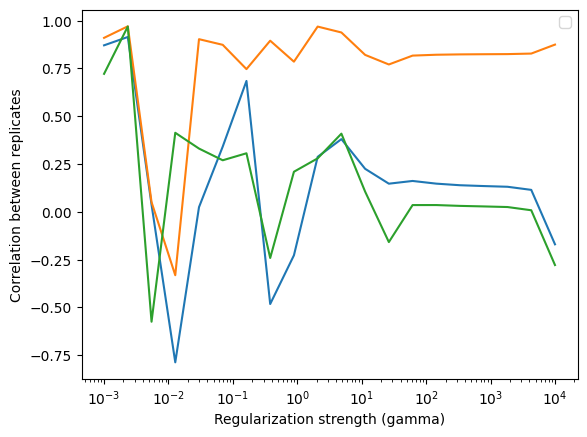

corrs_list: [[np.float64(-0.22873484557560855), np.float64(0.7975580787441672), np.float64(-0.2455742028317786)], [np.float64(-0.15481330398013268), np.float64(0.8015207985572703), np.float64(-0.18878704279405167)], [np.float64(-0.008603714391715533), np.float64(0.8172613309019658), np.float64(-0.08618359886921814)], [np.float64(0.15428359251703255), np.float64(0.8866108477143839), np.float64(0.005172100173723937)], [np.float64(0.9396564518670284), np.float64(0.9770119892671041), np.float64(0.8871652102272016)], [np.float64(0.9571986396976284), np.float64(-0.10413526639982637), np.float64(-0.23660063308969845)], [np.float64(0.8483139703512288), np.float64(0.8307936468681398), np.float64(0.8408941180935782)], [np.float64(-0.15770199601215462), np.float64(0.1455924795506055), np.float64(0.8836487243884315)], [np.float64(0.44068715210886067), np.float64(0.7607776229911959), np.float64(0.24163277662903934)], [np.float64(-0.8838044191596484), np.float64(0.9678311224134103), np.float64(-0.94

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


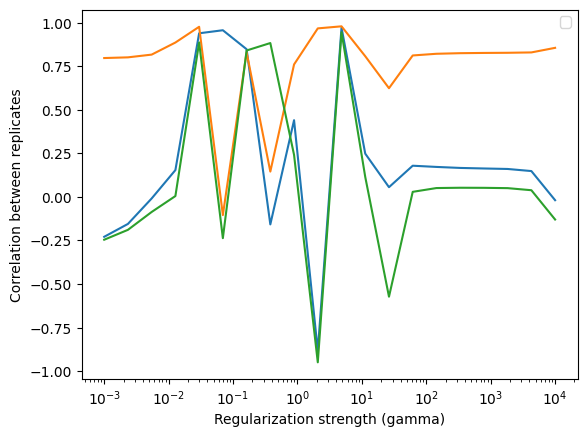

corrs_list: [[np.float64(0.4774000555647054), np.float64(0.8633033143235155), np.float64(0.34513093998662975)], [np.float64(0.4776490578877825), np.float64(0.8662761848719965), np.float64(0.3508978864501865)], [np.float64(0.4743978125726869), np.float64(0.8779201809903482), np.float64(0.35943143925555177)], [np.float64(0.4309718911430084), np.float64(0.9364093097217259), np.float64(0.34172107819761066)], [np.float64(0.6444743029347227), np.float64(0.9371989057110246), np.float64(0.7091289322695098)], [np.float64(0.8829712725448868), np.float64(0.9666726911760325), np.float64(0.926720929460557)], [np.float64(0.7296525096453754), np.float64(0.9538617988808569), np.float64(0.6328878687197205)], [np.float64(0.4697270389855362), np.float64(0.922338813706833), np.float64(0.5432880925696224)], [np.float64(0.3659289815982071), np.float64(0.8510225677234893), np.float64(-0.04162284136235134)], [np.float64(0.8543284292279393), np.float64(0.7903479042207207), np.float64(0.6760130843446847)], [np.

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


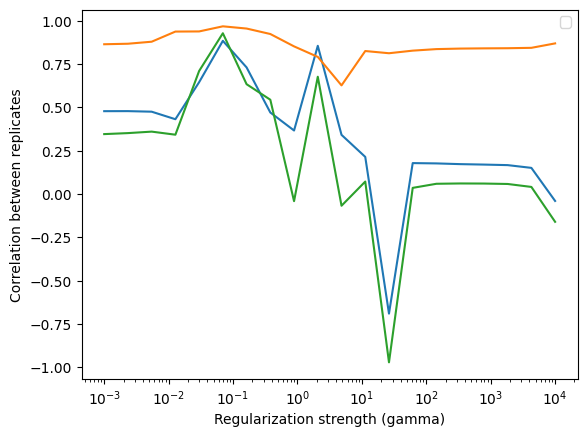

corrs_list: [[np.float64(-0.8932286857570749), np.float64(0.960417982548706), np.float64(-0.8468603793879297)], [np.float64(0.970820184208317), np.float64(0.9989028830773968), np.float64(0.9729334934399723)], [np.float64(-0.517210829272353), np.float64(0.6136361400288818), np.float64(-0.13497635706709205)], [np.float64(-0.4343450766051223), np.float64(0.586568391767692), np.float64(0.05802774776178697)], [np.float64(0.4951846901943343), np.float64(0.96648955597477), np.float64(0.5331022401011474)], [np.float64(0.5769820717077603), np.float64(-0.09390200233720455), np.float64(-0.7778044681546109)], [np.float64(0.9539892189971073), np.float64(0.9661859821930351), np.float64(0.9648325040826273)], [np.float64(-0.4599445170718742), np.float64(0.8850282599956985), np.float64(-0.4453267915554436)], [np.float64(-0.40686734795016555), np.float64(0.9311827704310196), np.float64(-0.48569627258903625)], [np.float64(-0.5533444009673394), np.float64(0.9683607260806077), np.float64(-0.607128830108281

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


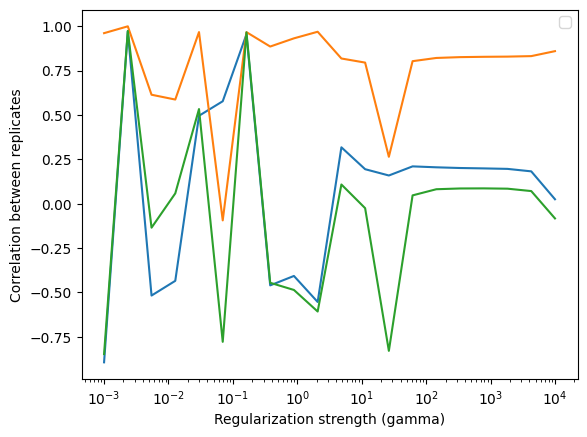

corrs_list: [[np.float64(0.2227629304874458), np.float64(0.5794522519649628), np.float64(-0.10912114137796639)], [np.float64(0.20103547589797127), np.float64(0.6084019701119051), np.float64(-0.10424867729439483)], [np.float64(0.15854465591749778), np.float64(0.6630652526107979), np.float64(-0.09199736564237054)], [np.float64(0.10326346742577622), np.float64(0.801855677620528), np.float64(0.0018996856252421757)], [np.float64(0.9789104656194397), np.float64(0.9962726381771747), np.float64(0.969033357967698)], [np.float64(0.9742605023195849), np.float64(0.9688912144058437), np.float64(0.9452628073764086)], [np.float64(0.2800306216908697), np.float64(0.6883656048306184), np.float64(-0.0023697901314499795)], [np.float64(0.23498266564700865), np.float64(0.8594345356483672), np.float64(0.01589488981942153)], [np.float64(0.20874660199210165), np.float64(0.6562635689187652), np.float64(-0.21238597823933686)], [np.float64(-0.019231416013503665), np.float64(0.6638857923173827), np.float64(-0.2004

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


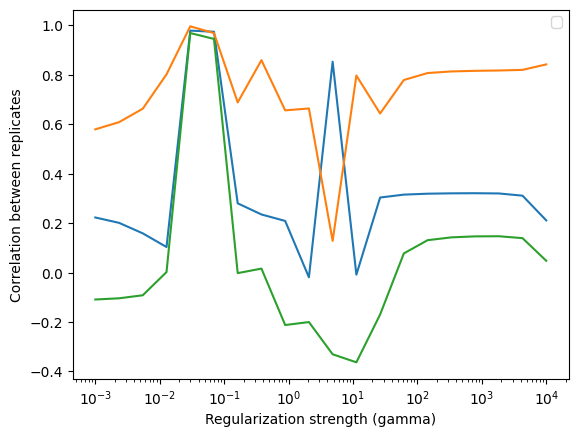

corrs_list: [[np.float64(-0.11740268439451428), np.float64(0.9337341578570564), np.float64(-0.3087268691534074)], [np.float64(-0.8540820609008235), np.float64(0.9777867654291071), np.float64(-0.9242530256789561)], [np.float64(-0.318260774191869), np.float64(0.9521244823674063), np.float64(-0.42129944753627296)], [np.float64(0.3095663501921212), np.float64(0.8744899212439887), np.float64(0.021986599353180383)], [np.float64(-0.6835812893367932), np.float64(0.9963156295523975), np.float64(-0.7126045816148591)], [np.float64(0.2717216941818812), np.float64(0.9931028089507739), np.float64(0.3121858982319043)], [np.float64(0.8448915057494137), np.float64(0.4584040618453715), np.float64(0.3854892052145824)], [np.float64(0.7732083259791862), np.float64(0.5034571117725553), np.float64(0.062020905932317474)], [np.float64(0.006300174146759319), np.float64(0.9232196428265632), np.float64(-0.2924349255458028)], [np.float64(-0.0773173175495735), np.float64(0.857102432710432), np.float64(-0.1512885334

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


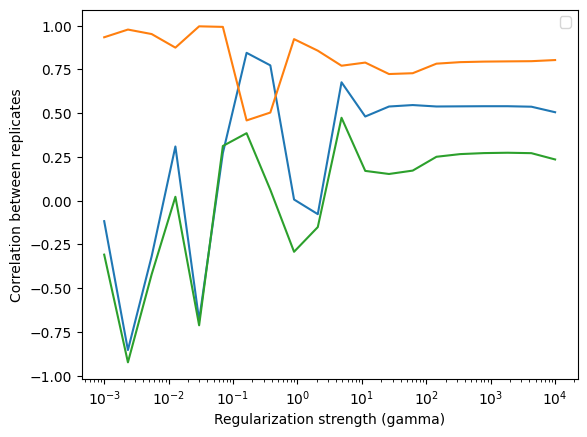

corrs_list: [[np.float64(0.8051340748326673), np.float64(0.9796180599448038), np.float64(0.7629262198086489)], [np.float64(0.7776581978804168), np.float64(0.9687634246459844), np.float64(0.7179866361692305)], [np.float64(0.7437565594444686), np.float64(0.9435392199117814), np.float64(0.6507521011287005)], [np.float64(0.7387617264827123), np.float64(0.9116957326000757), np.float64(0.6253974284048147)], [np.float64(-0.997433195183646), np.float64(0.9994522532610878), np.float64(-0.9955253572384449)], [np.float64(0.5233105552524111), np.float64(0.7278179147217623), np.float64(0.6201483107530814)], [np.float64(0.8388083464123964), np.float64(-0.9924577921074457), np.float64(-0.7992732251777814)], [np.float64(0.8380938995471094), np.float64(0.9637186757855263), np.float64(0.8115254293146832)], [np.float64(0.5487953631069579), np.float64(0.500176426840941), np.float64(0.09589738679179041)], [np.float64(0.6836509766391992), np.float64(0.940298172012693), np.float64(0.5211479651406534)], [np.f

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


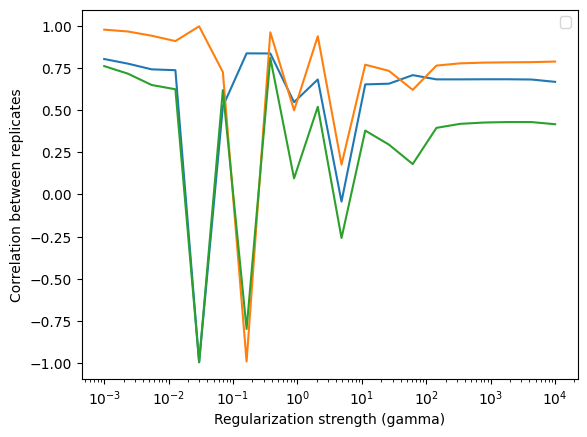

corrs_list: [[np.float64(0.9876443602411447), np.float64(0.9308965999417739), np.float64(0.9140156158679824)], [np.float64(0.9915872448721685), np.float64(0.9729831687673615), np.float64(0.9586239648501472)], [np.float64(0.9998231430991811), np.float64(0.9997968273922246), np.float64(0.999601501684507)], [np.float64(-0.9919016517003701), np.float64(-0.9929451848673262), np.float64(0.9996948269211754)], [np.float64(0.9619275409913034), np.float64(0.868401450705147), np.float64(0.7735818834259407)], [np.float64(0.6062214632265481), np.float64(0.772178132172566), np.float64(0.12195935756115901)], [np.float64(0.90106189263193), np.float64(0.8287085398579908), np.float64(0.6042782739073963)], [np.float64(0.6522460913849887), np.float64(-0.9901740217372302), np.float64(-0.6033926754777316)], [np.float64(0.37728799111925426), np.float64(0.9417110706943665), np.float64(0.15697006792751067)], [np.float64(0.786064949760833), np.float64(0.7757309461095443), np.float64(0.7659686976188975)], [np.fl

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


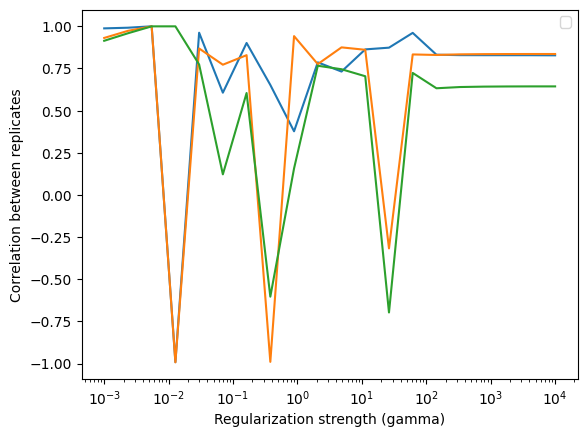

corrs_list: [[np.float64(0.9682520219743942), np.float64(0.9745104252959687), np.float64(0.916769633731229)], [np.float64(0.7870444866812748), np.float64(0.7109541428070507), np.float64(0.9672831935363184)], [np.float64(0.8248228722739757), np.float64(0.8865663549989233), np.float64(0.8029825259381942)], [np.float64(0.9126613958210492), np.float64(0.9287541252439435), np.float64(0.7850362538702007)], [np.float64(0.9106447361373728), np.float64(0.9974967707336759), np.float64(0.935826861351625)], [np.float64(0.9421923882295538), np.float64(0.9343474640129024), np.float64(0.8398164746583223)], [np.float64(0.9751335205502947), np.float64(0.9459419614559328), np.float64(0.9909373856339866)], [np.float64(0.9132865760188495), np.float64(0.8690278304209809), np.float64(0.8022334570047236)], [np.float64(0.9012652426015851), np.float64(0.8531294467897632), np.float64(0.7502351093834094)], [np.float64(0.90105779220631), np.float64(0.8604688607629392), np.float64(0.7026927002632907)], [np.float64

/Users/dylanwells/popDMS/esmDMS/popDMS.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


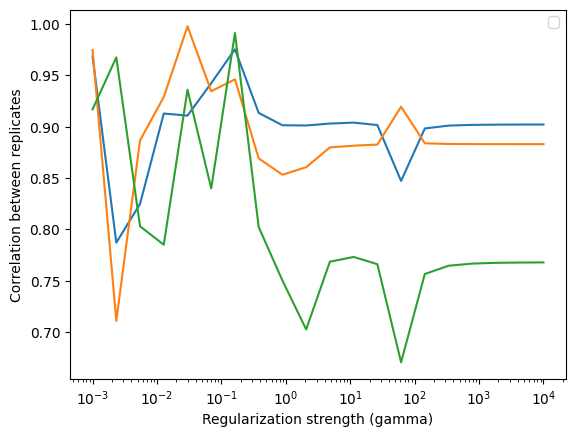

In [ ]:
for dataset in active_datasets:
    print(f"Dataset: {dataset}")
    dataset_results = {}
    for layer in LAYERS:
        #print(f"  Layer {layer}")
        layer_df = load_embedding_df(layer, active_datasets[dataset])
        #print(f"Layer df head:\n{layer_df.head()}")
        layer_inference_data = mini_infer_independent_esm(layer_df, n_replicates=3, gamma=None, corr_cutoff_pct=0.5,
                                                   max_reads=1e3, output_dir=None, name='esm_inference', plot_gamma=True,
                                                   verbose=True, calc_error_bars=False,
                                                   variance_cutoff=0.0, infer_ignored_dims=True)
        dataset_results[layer] = layer_inference_data
    # Save the results for this dataset
    with open(f'inference_results_{dataset}.pkl', 'wb') as f:
        pickle.dump(dataset_results, f)

In [5]:
# Processing into simulation format
all_results_fullcov = {}

for dataset in active_datasets:
    print(f"Processing dataset {dataset} into simulation format...")
    processed_dataset_results = {}
    with open(f'inference_results_{dataset}.pkl', 'rb') as f:
            dataset_results = pickle.load(f)

    for layer in LAYERS:
        #print(f"Processing layer {layer} into simulation format...")
        
        layer_inference_data = dataset_results[layer]

        #layer_results = [data[2], data[3], data[7], data[8], data[1], data[5]]

        layer_results = [layer_inference_data[2], layer_inference_data[3], layer_inference_data[7], layer_inference_data[8], layer_inference_data[1], layer_inference_data[5]]
        processed_dataset_results[layer] = layer_results
    all_results_fullcov[dataset] = [None, None, processed_dataset_results, None, None]
print("Finished processing datasets into simulation format.")

Processing dataset BG505 into simulation format...
Processing dataset BF520 into simulation format...
Finished processing datasets into simulation format.


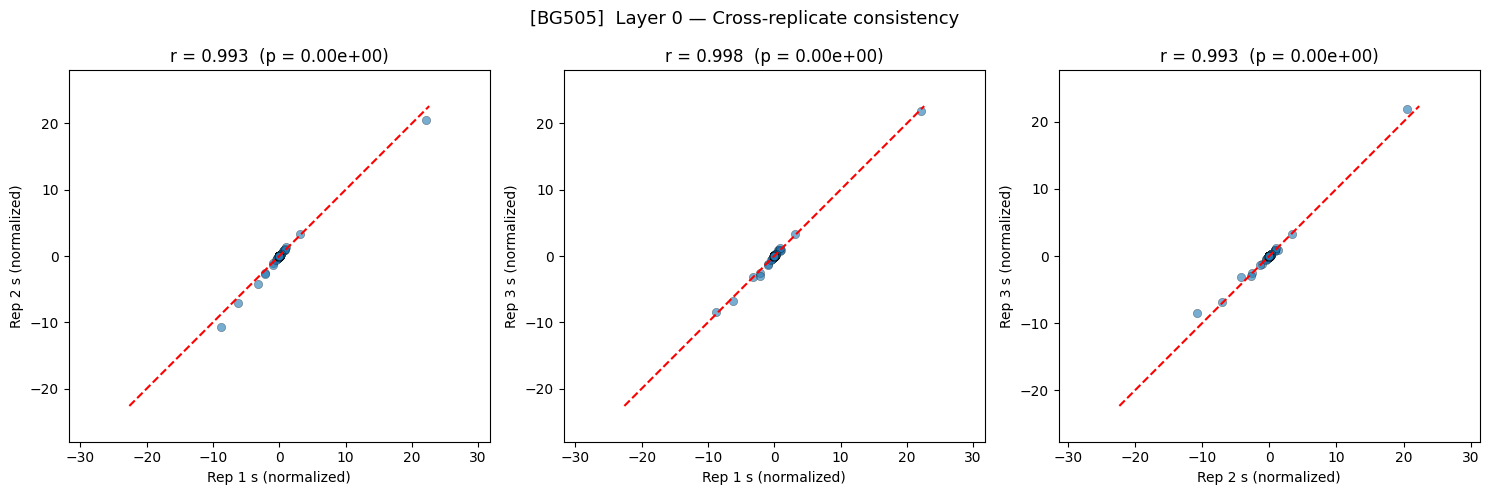

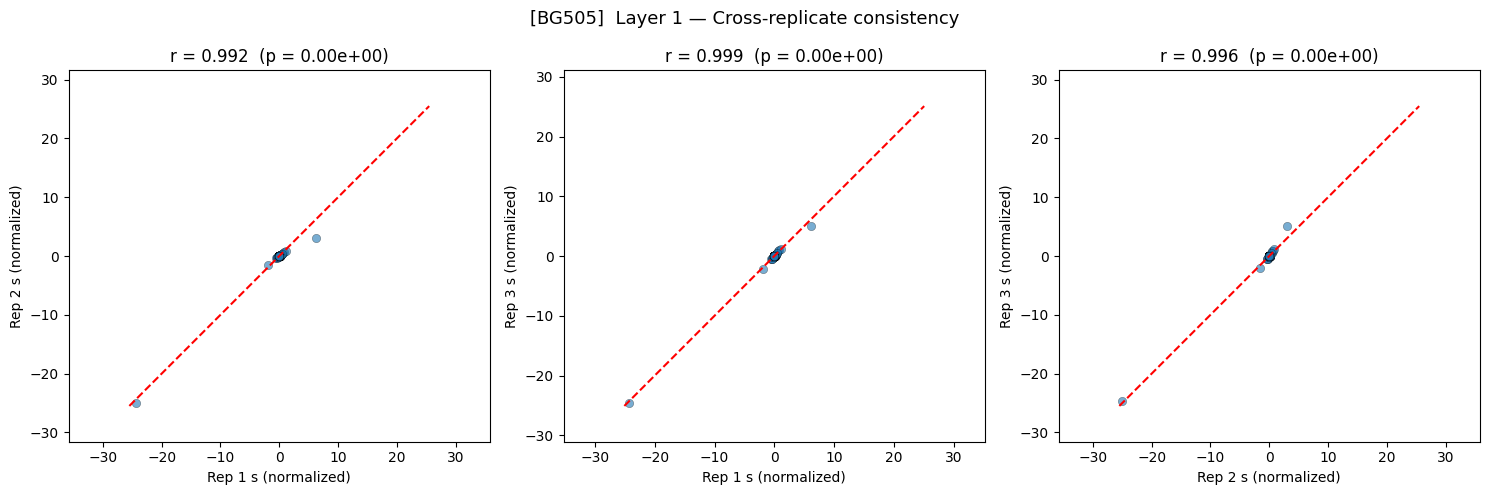

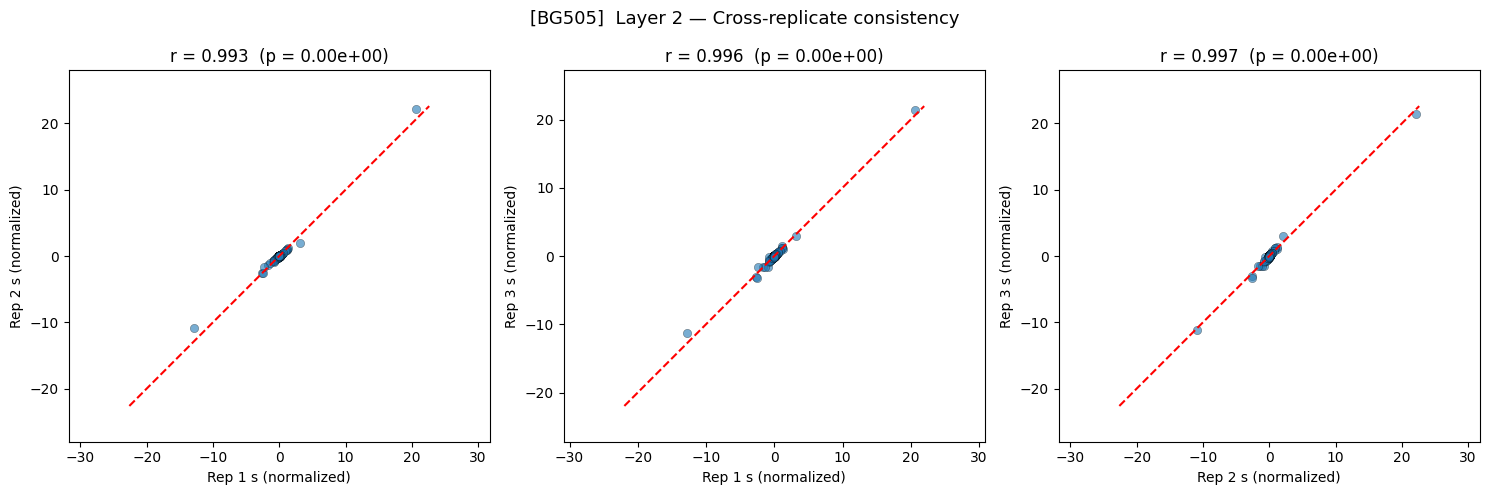

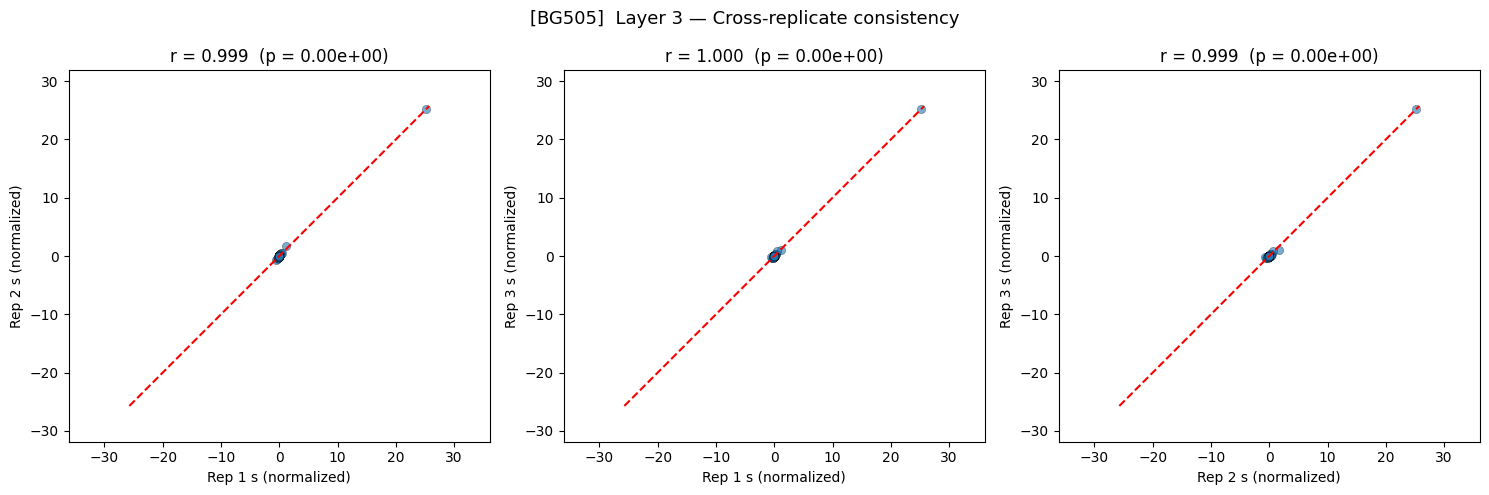

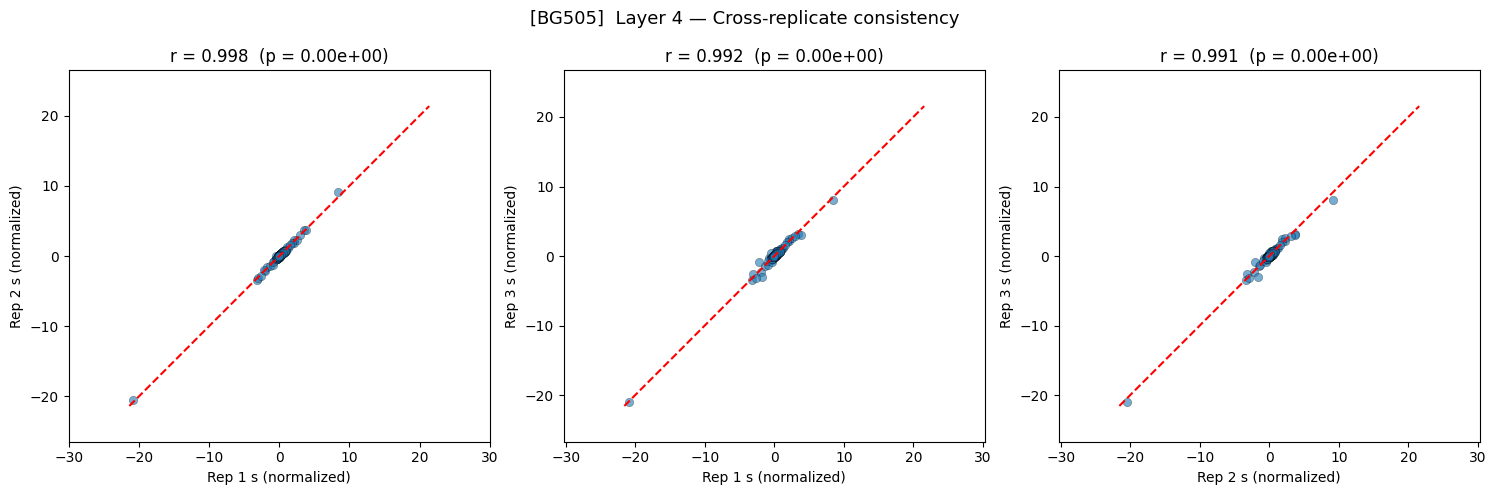

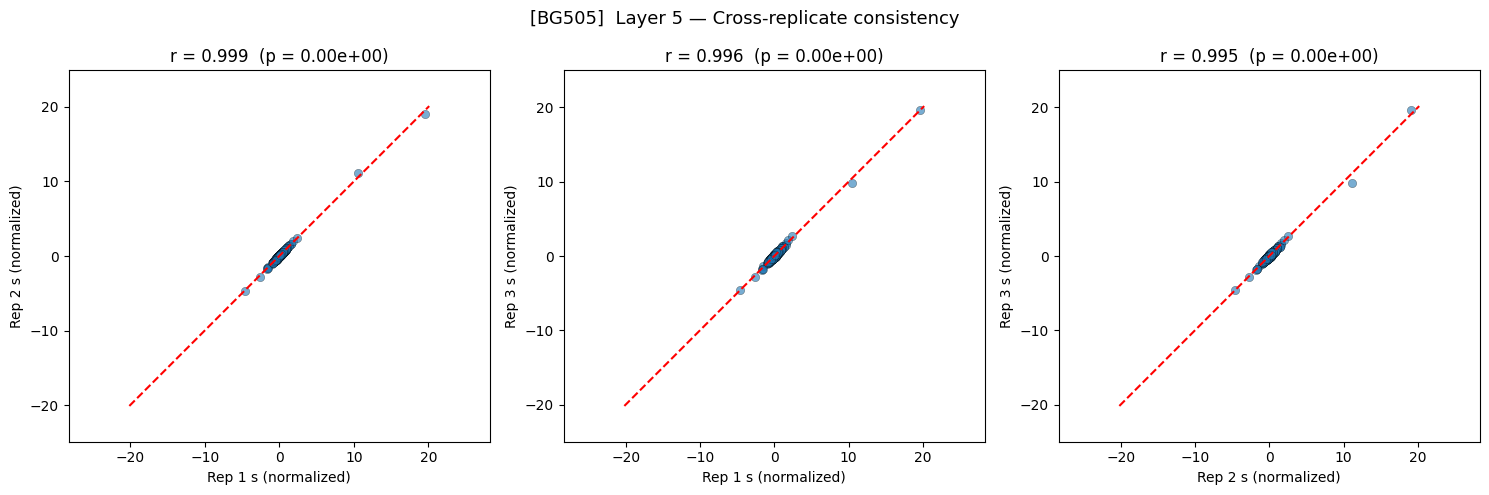

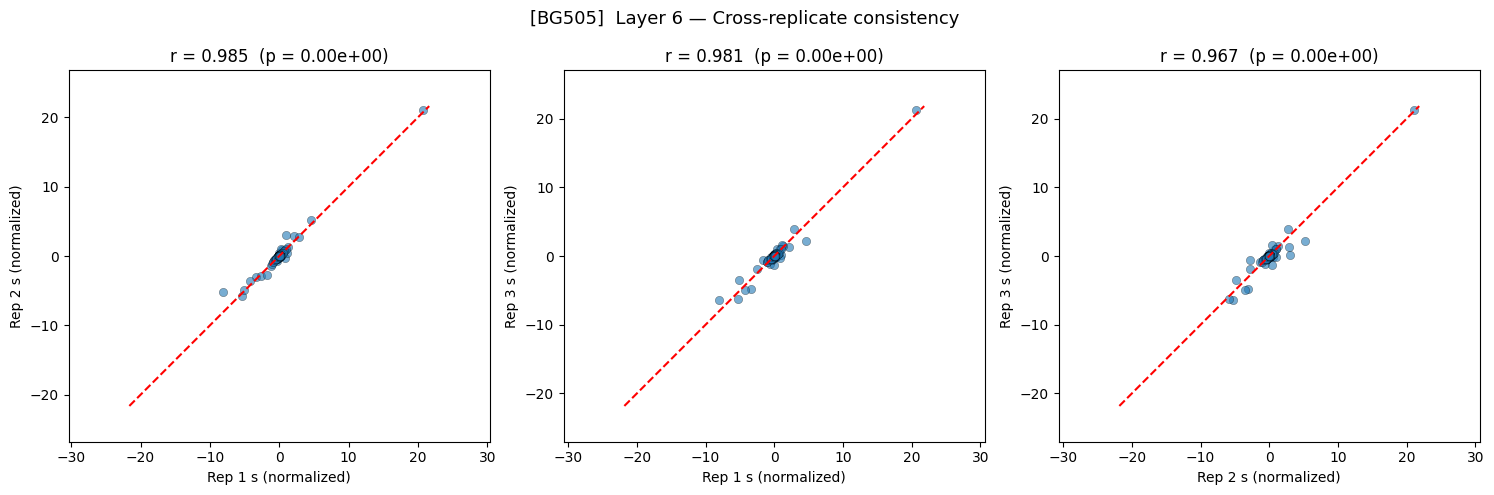

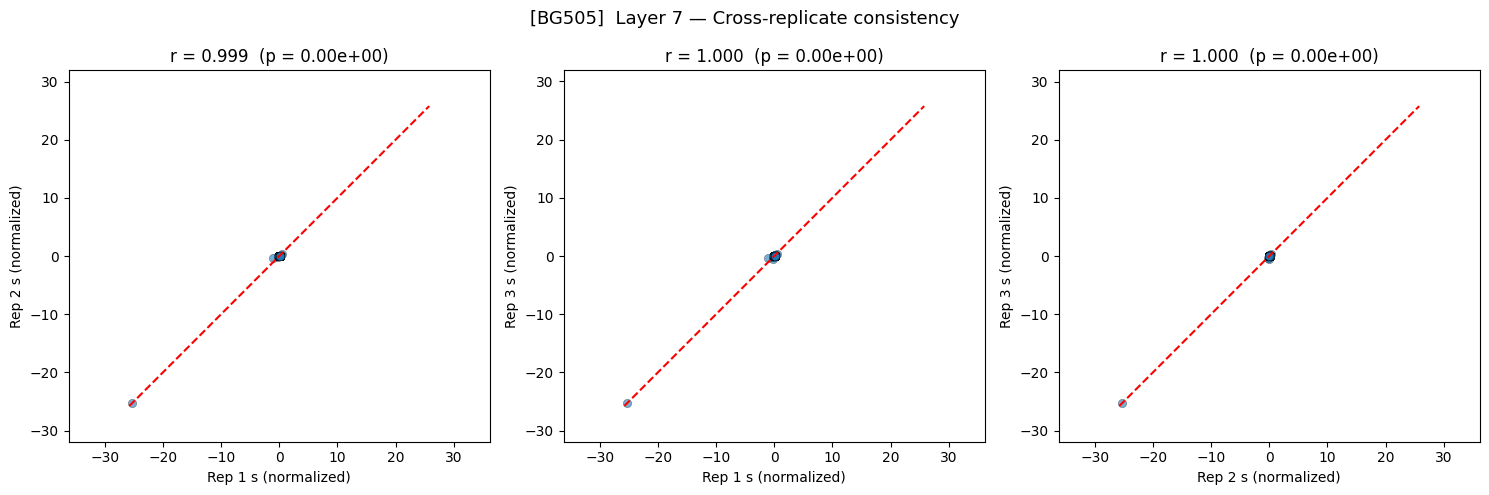

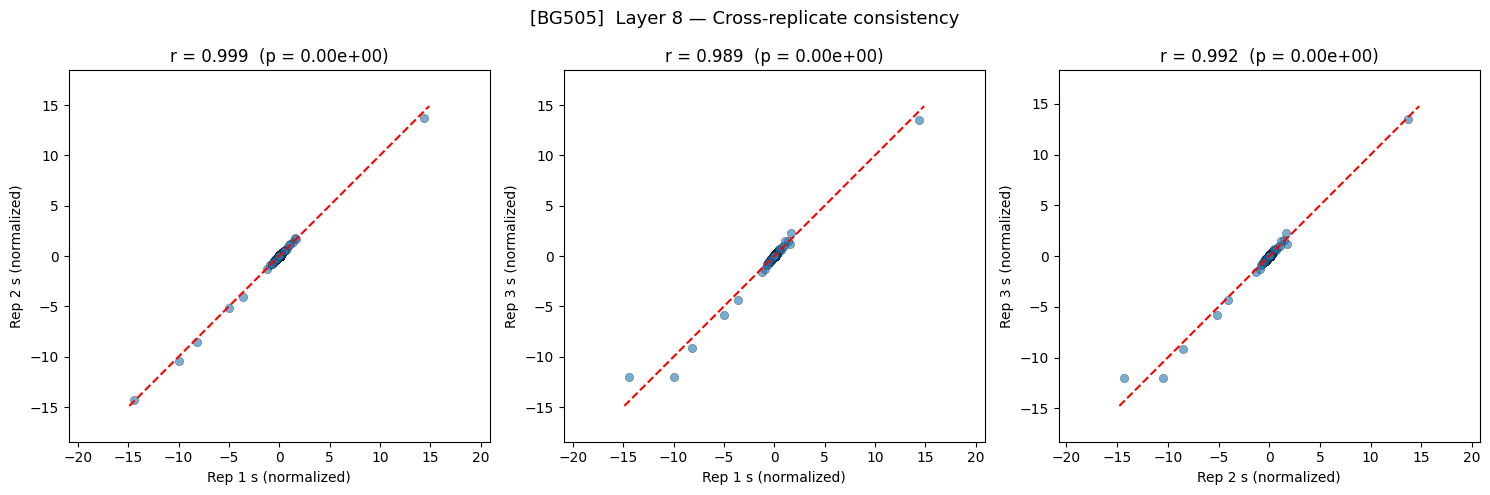

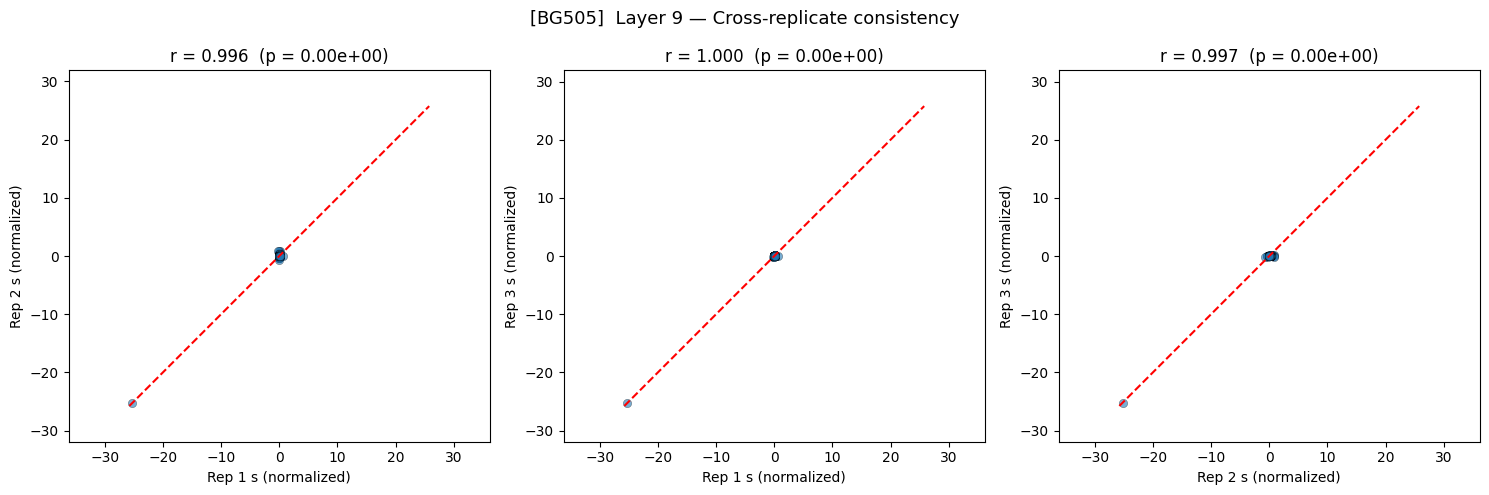

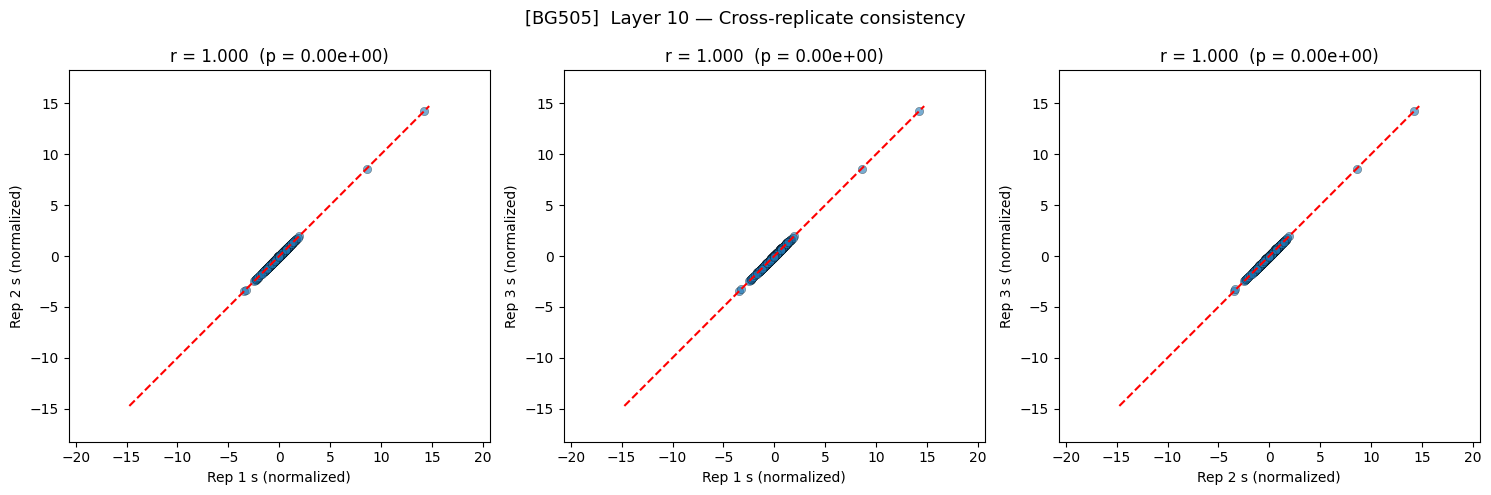

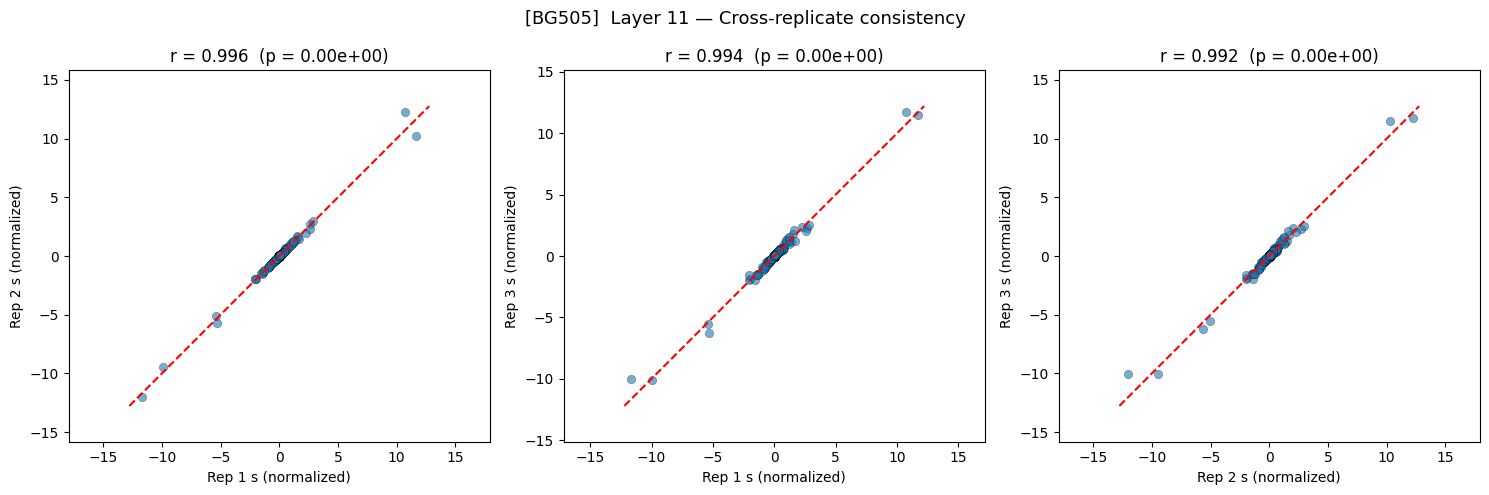

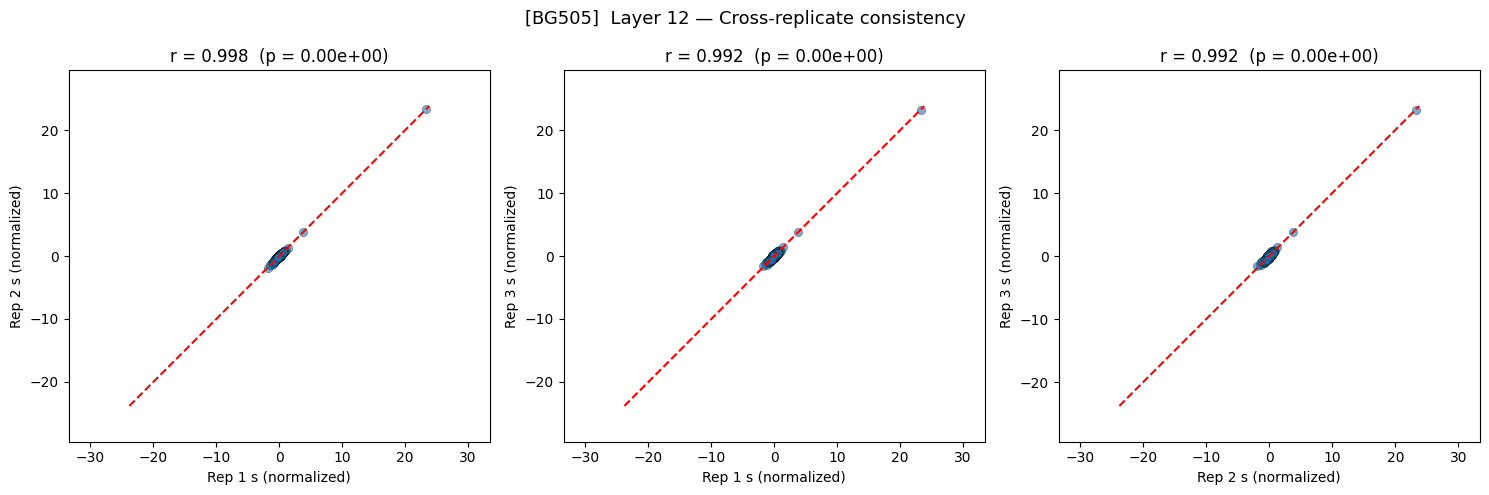

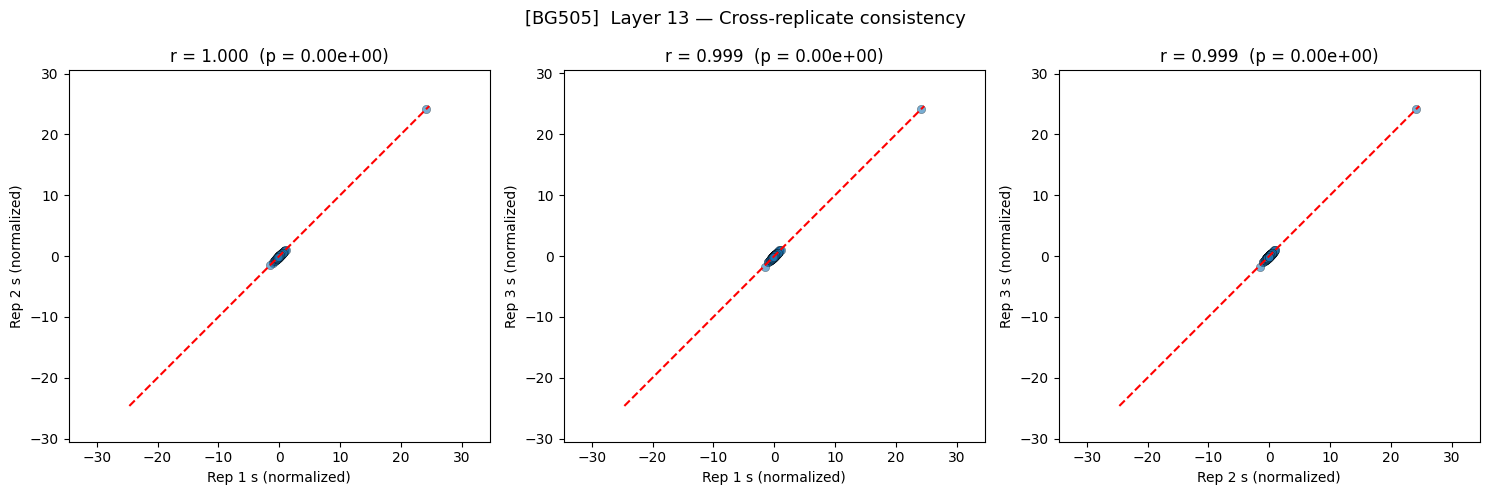

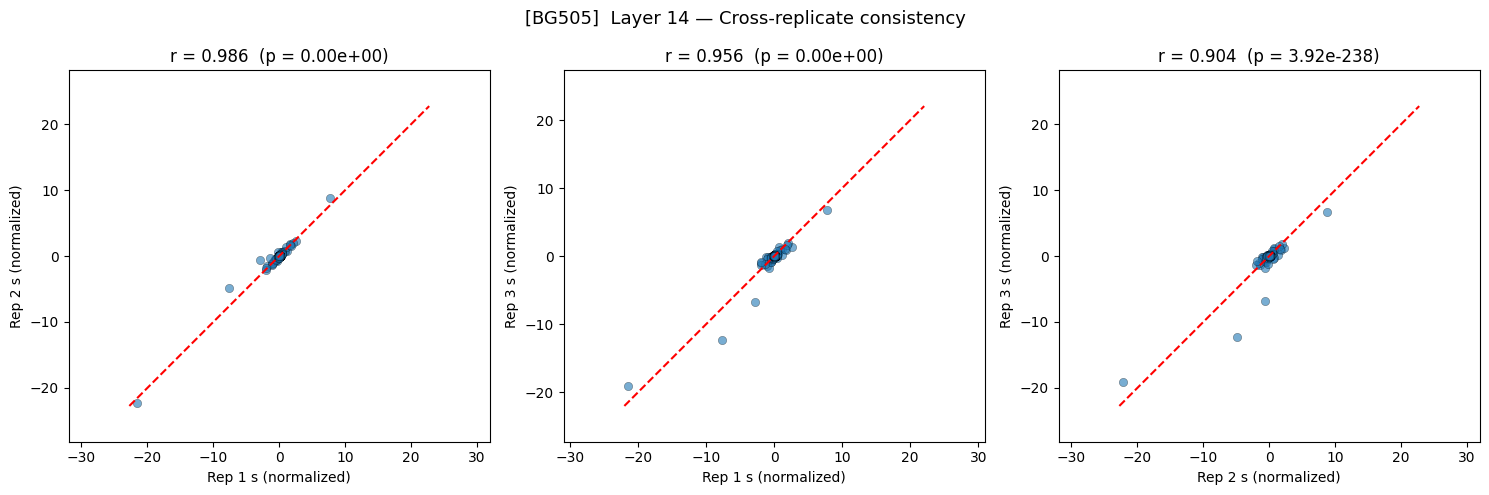

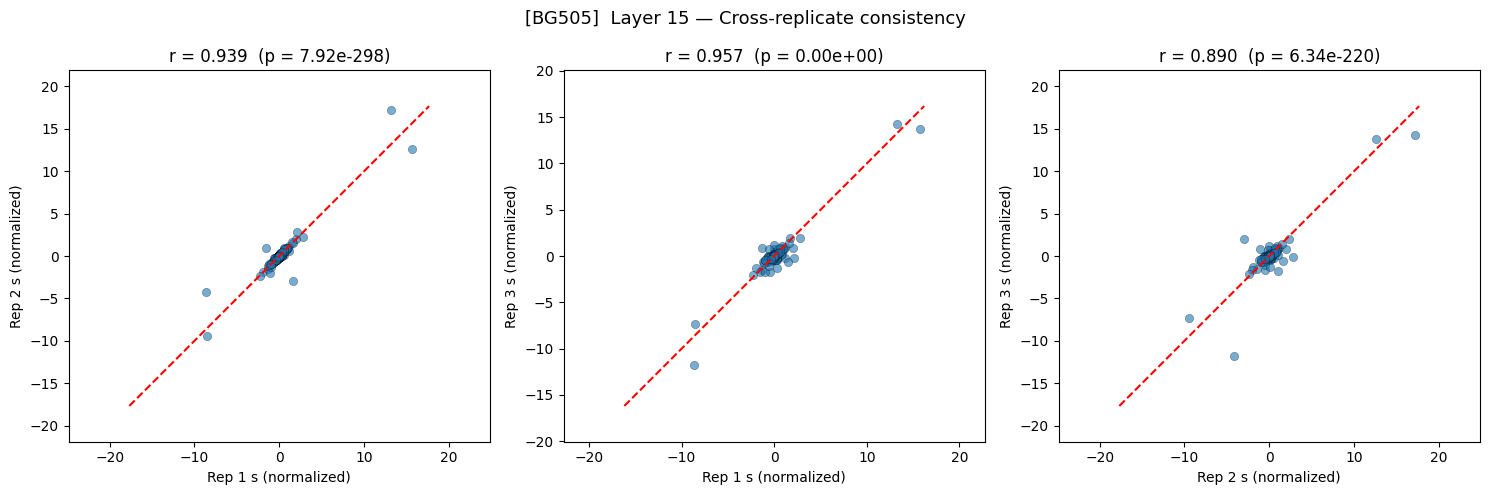

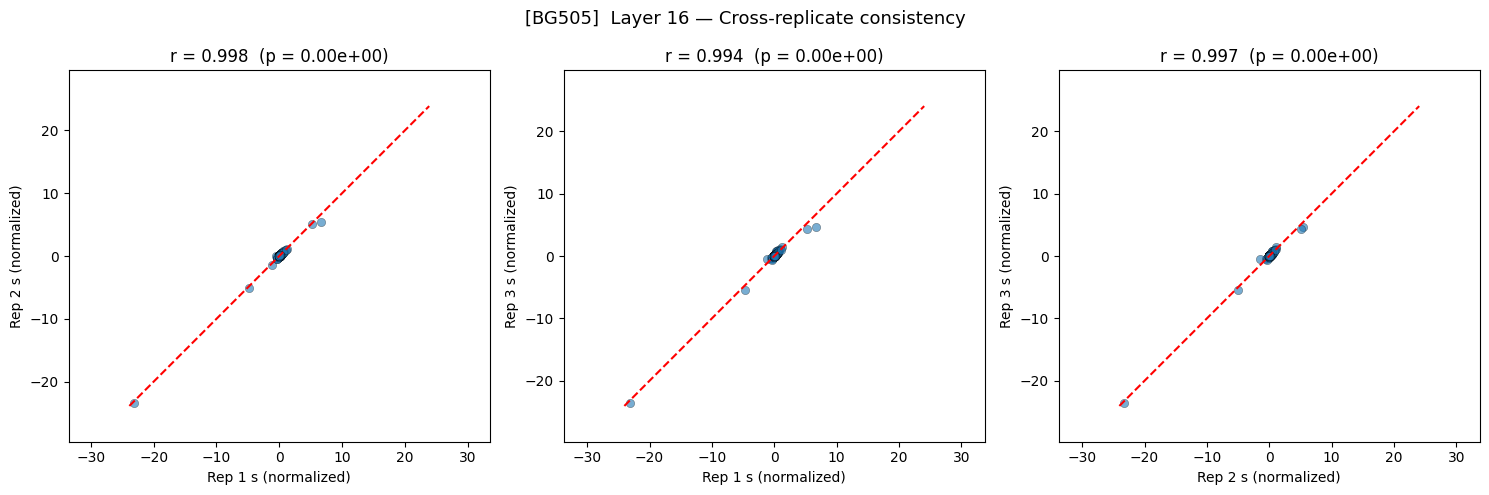

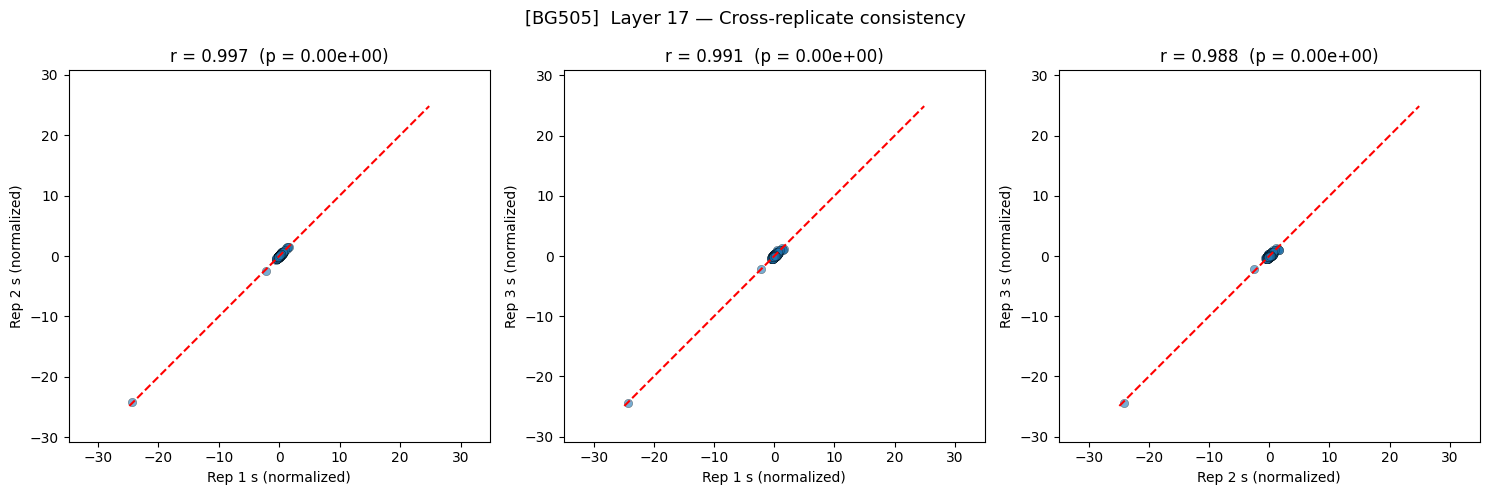

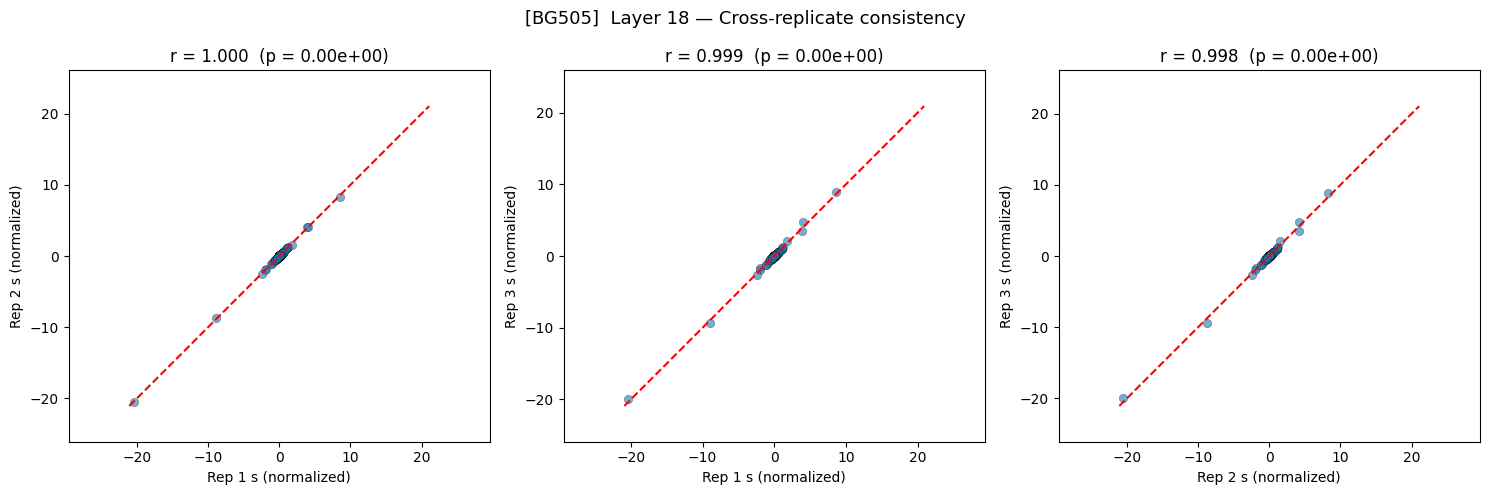

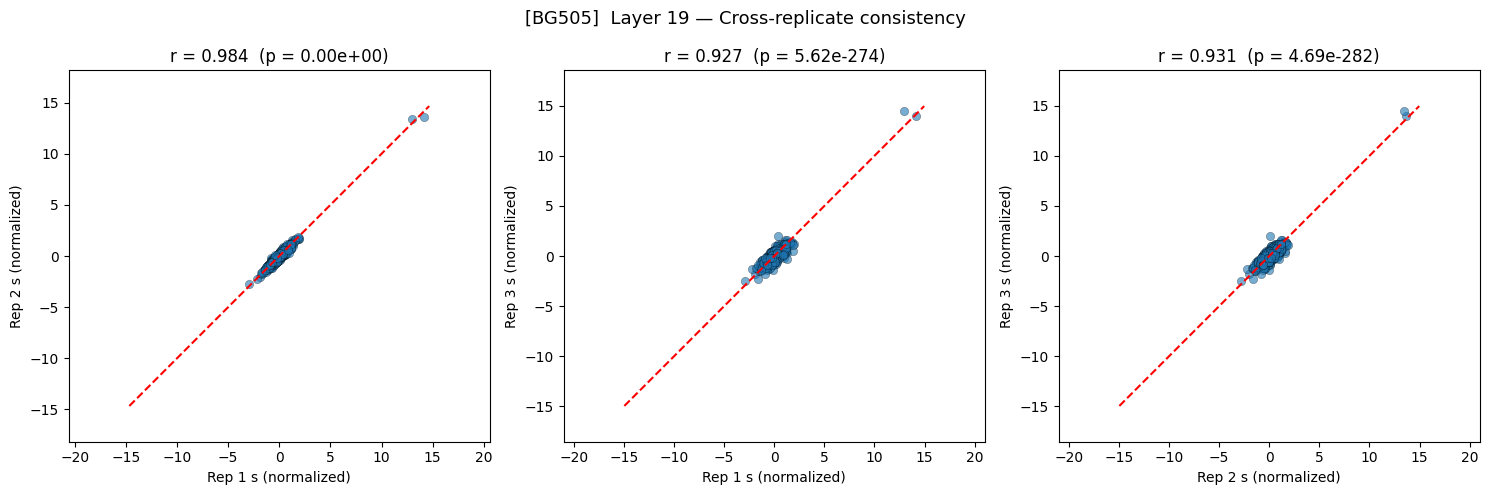

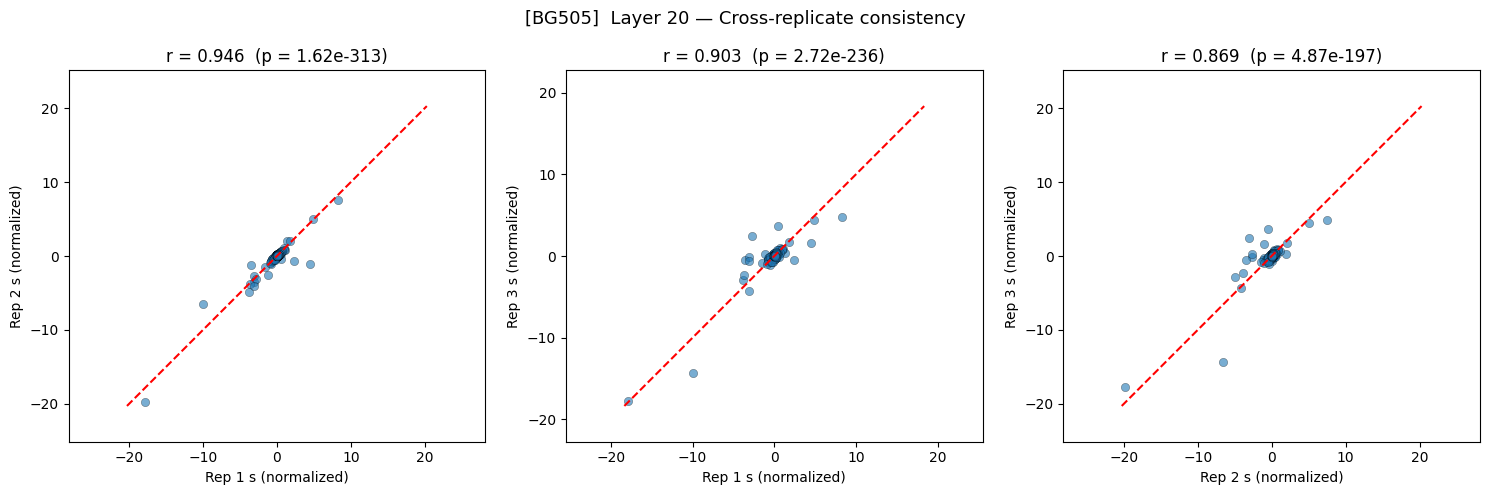

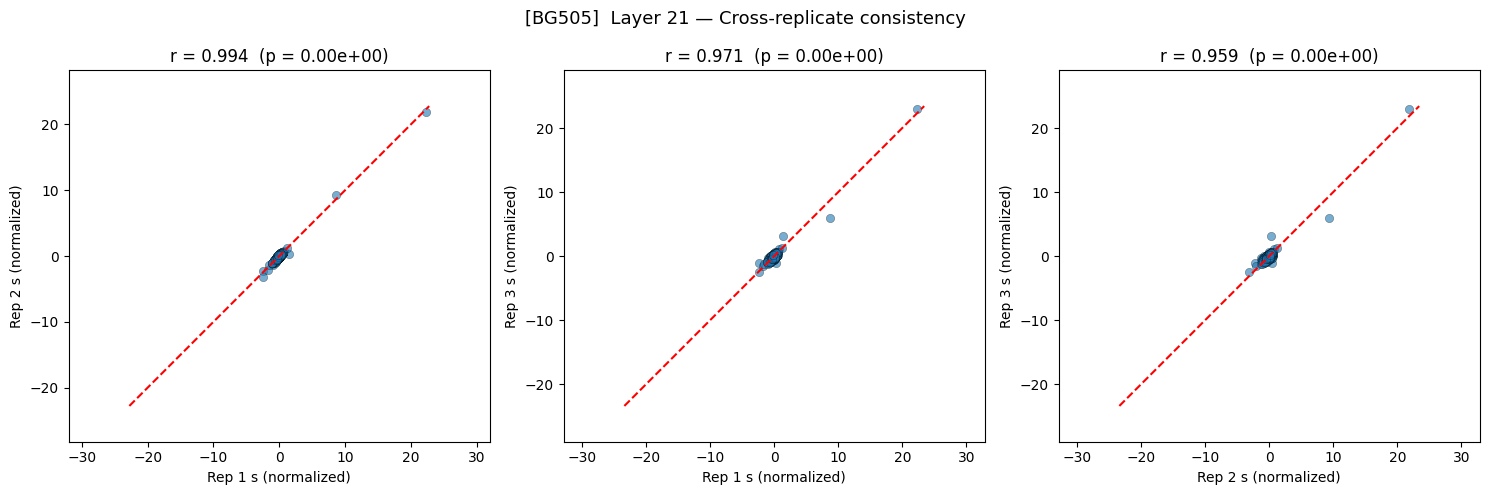

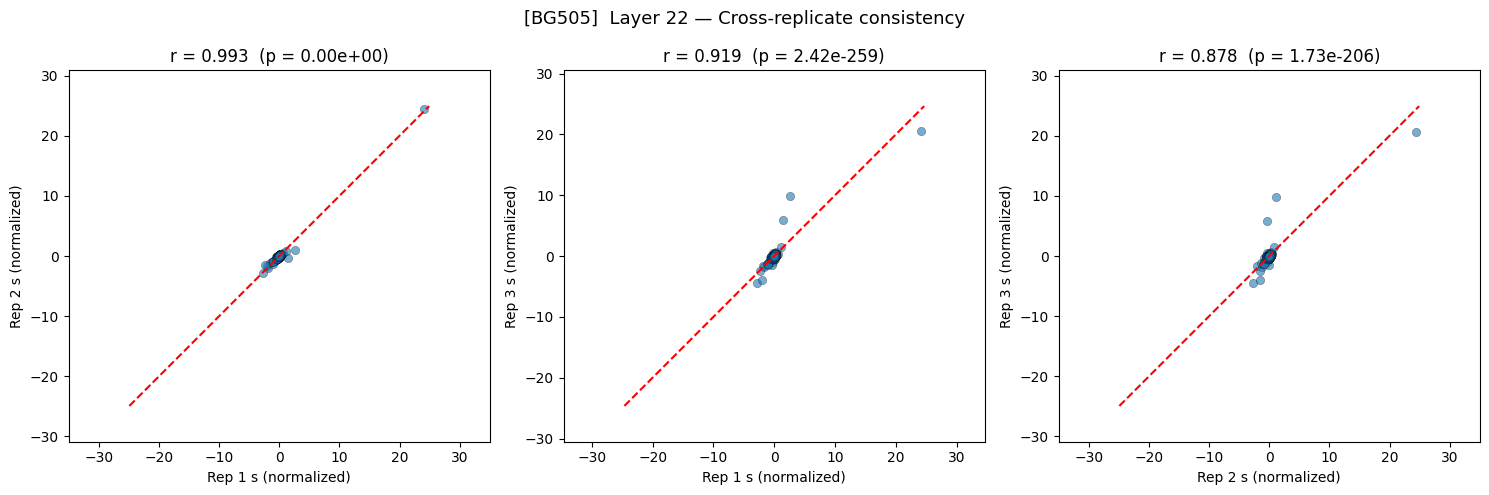

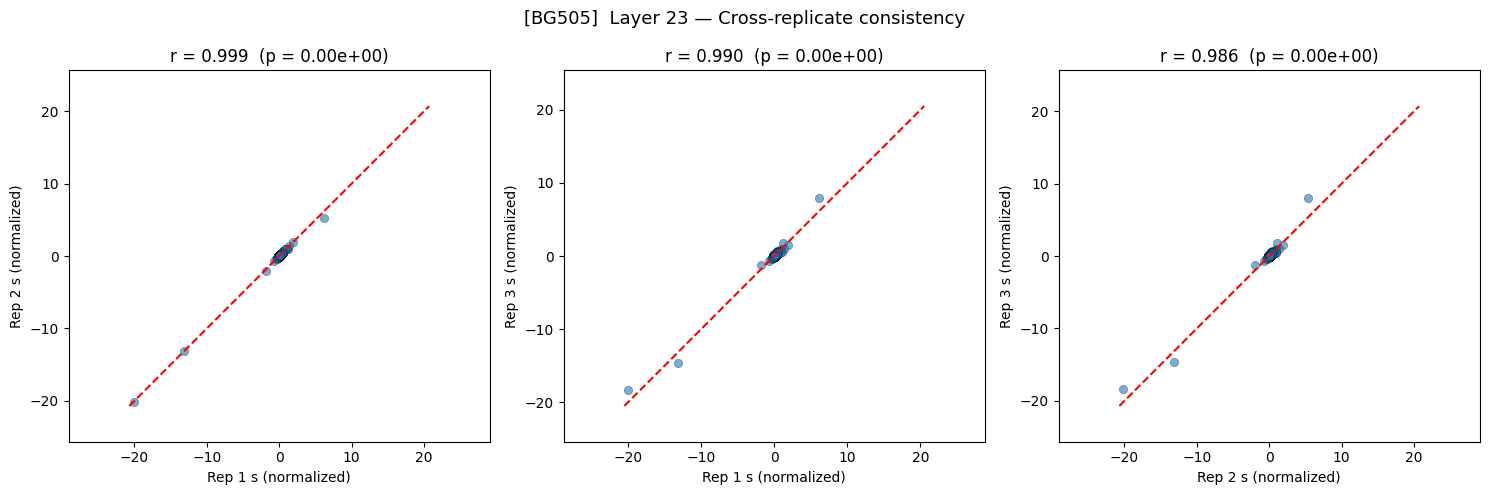

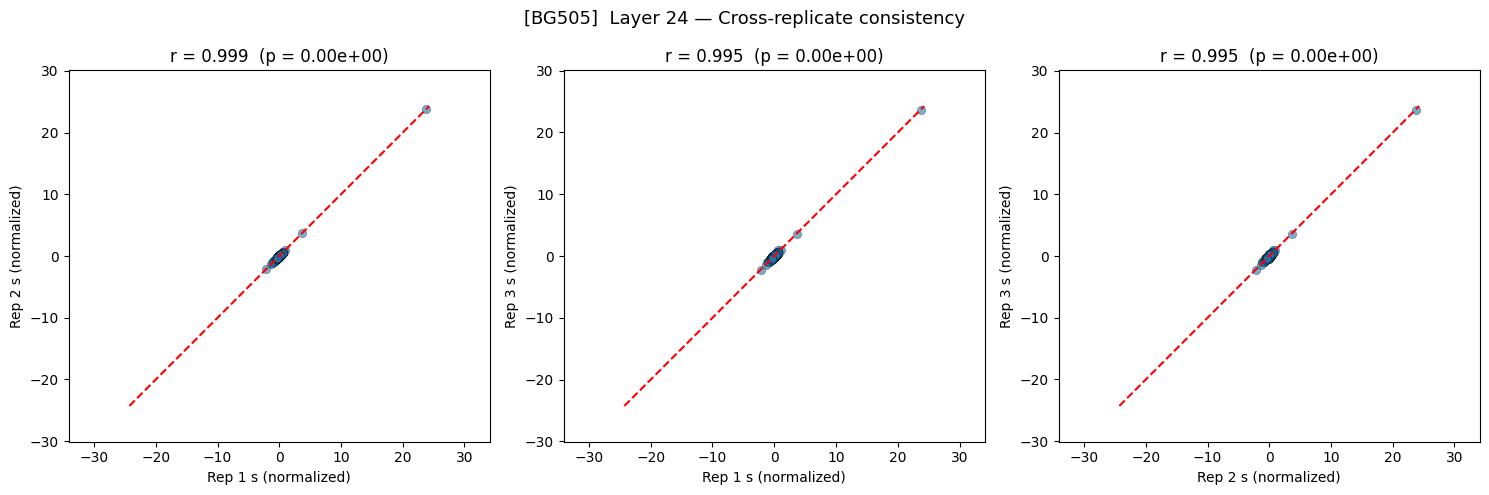

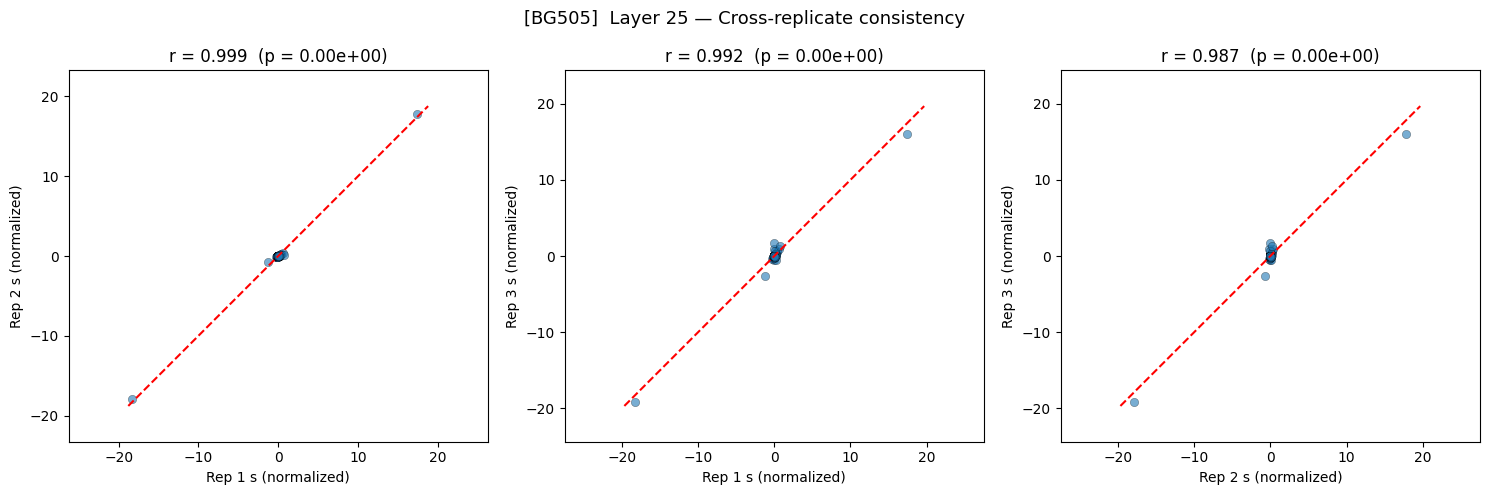

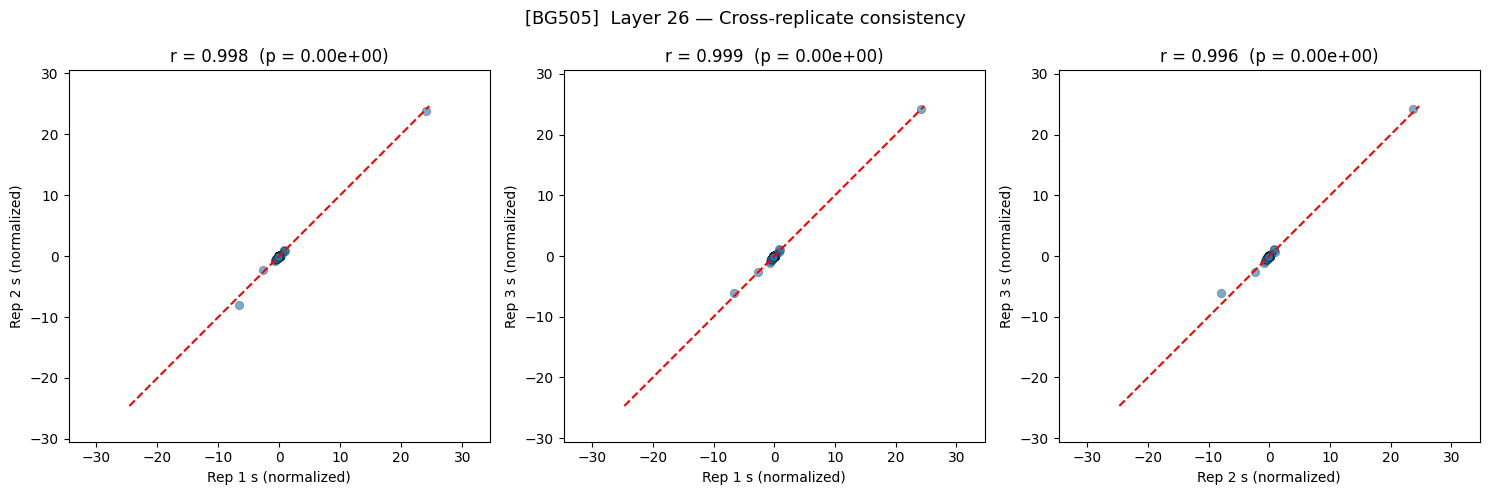

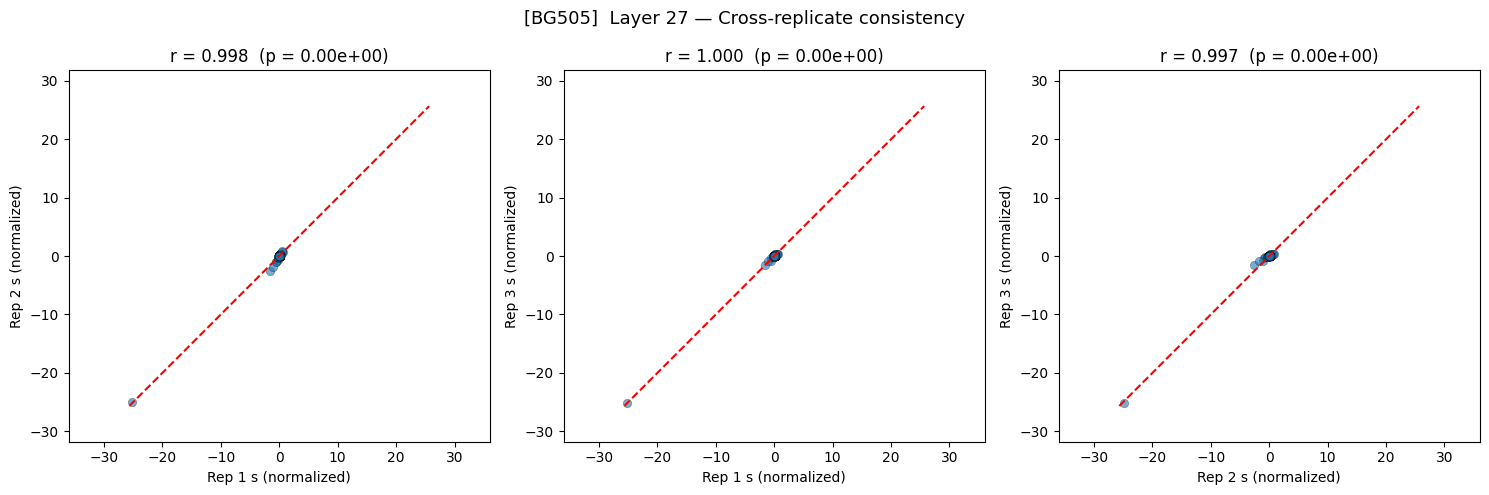

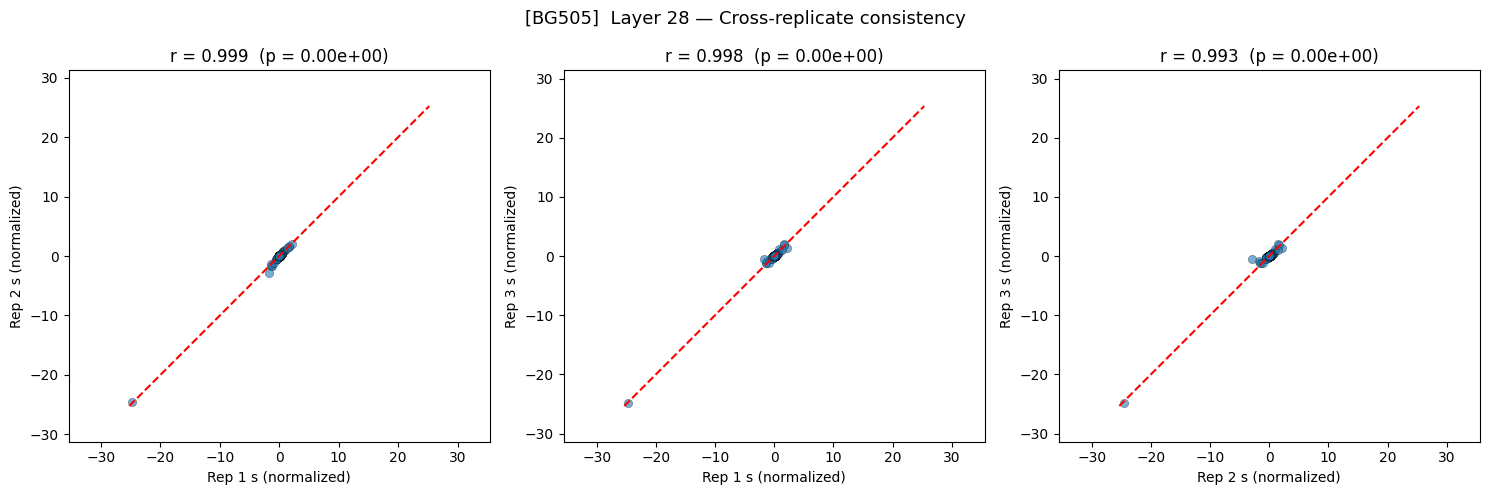

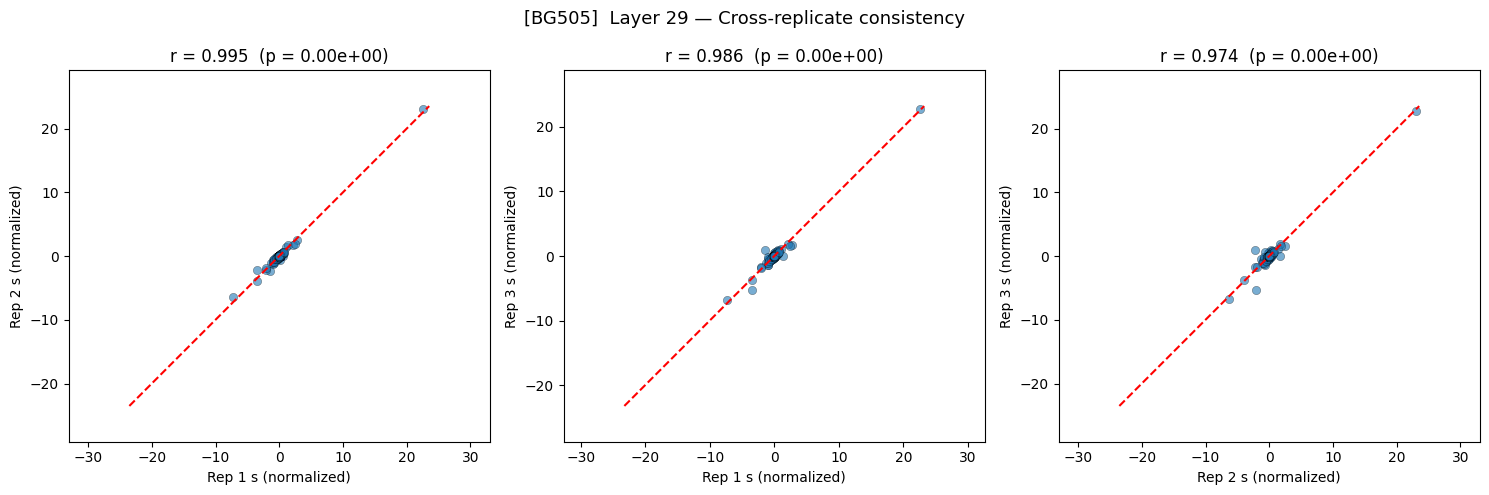

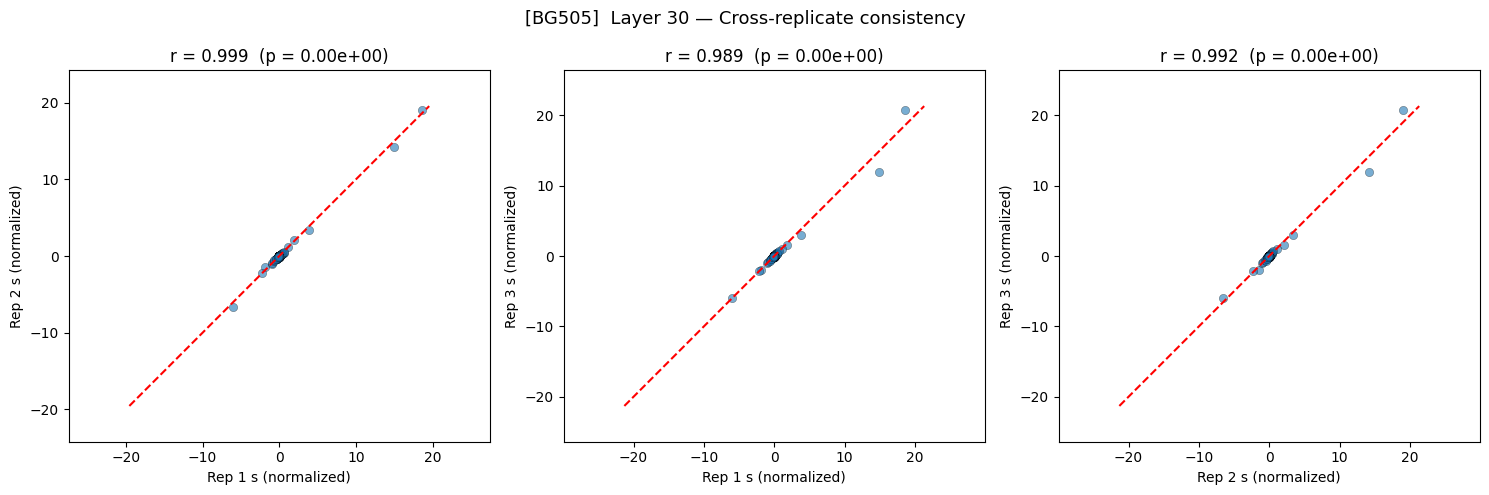

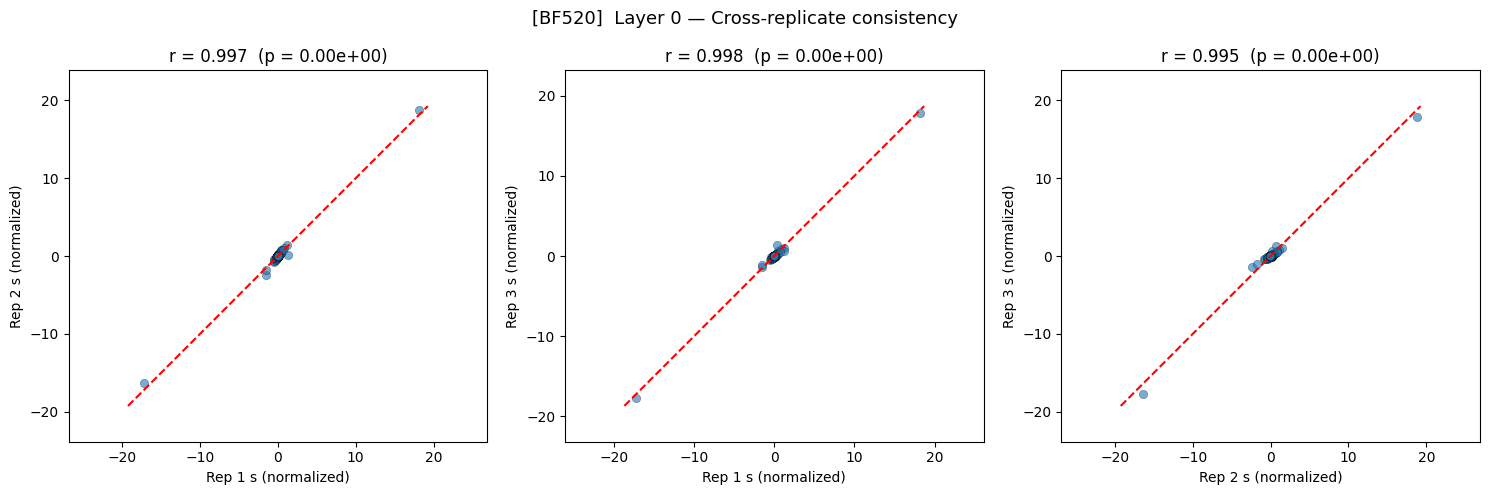

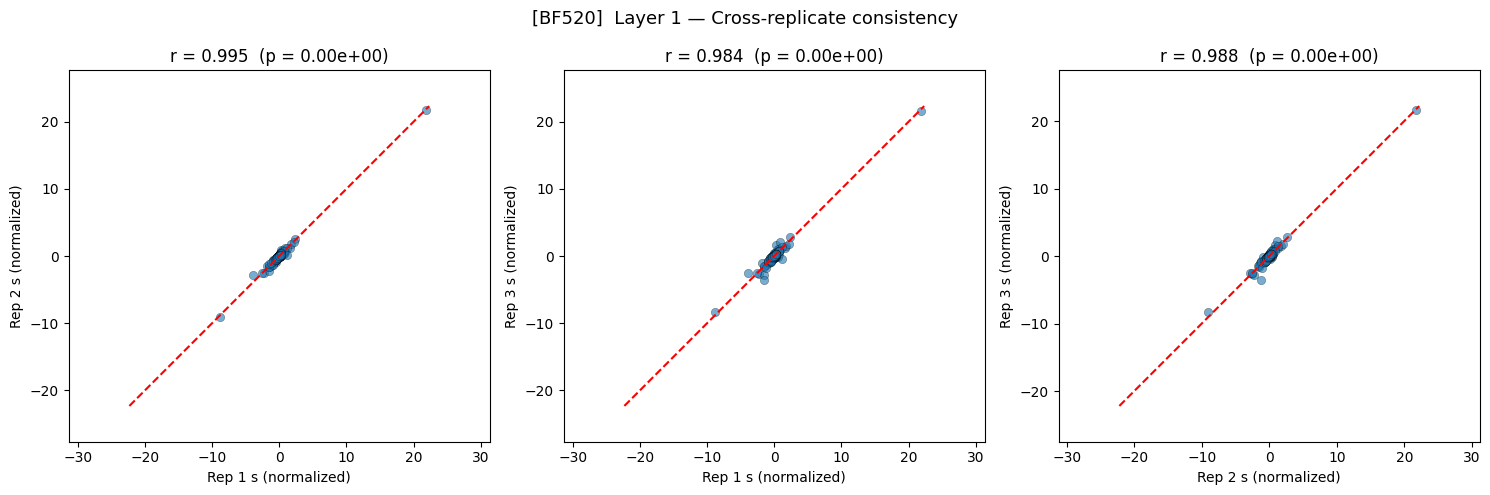

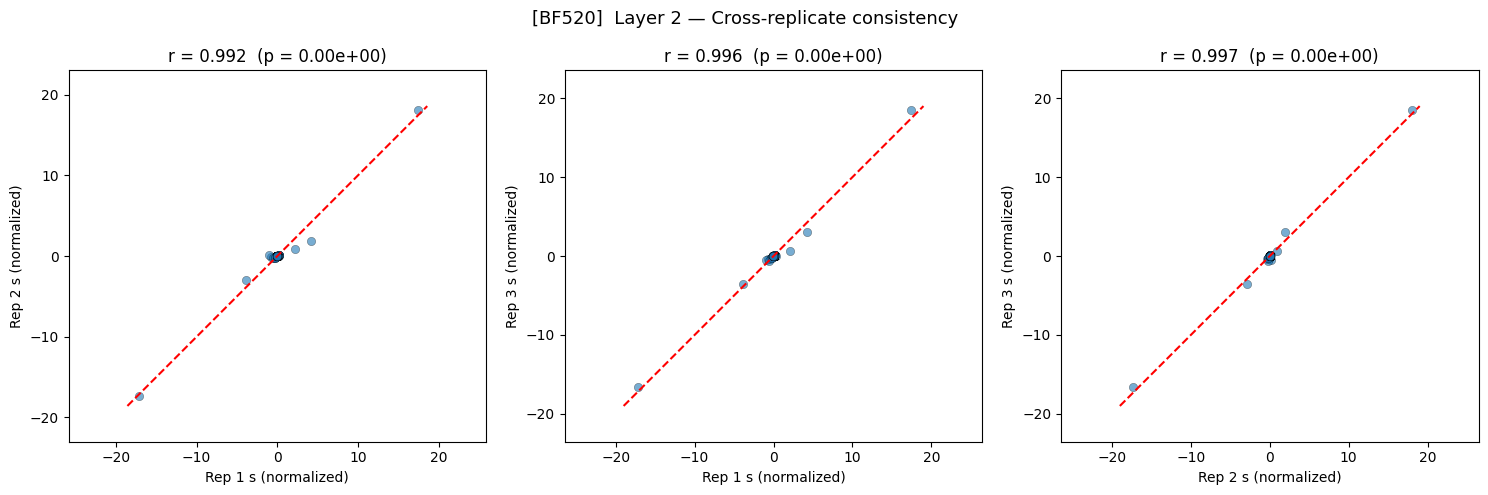

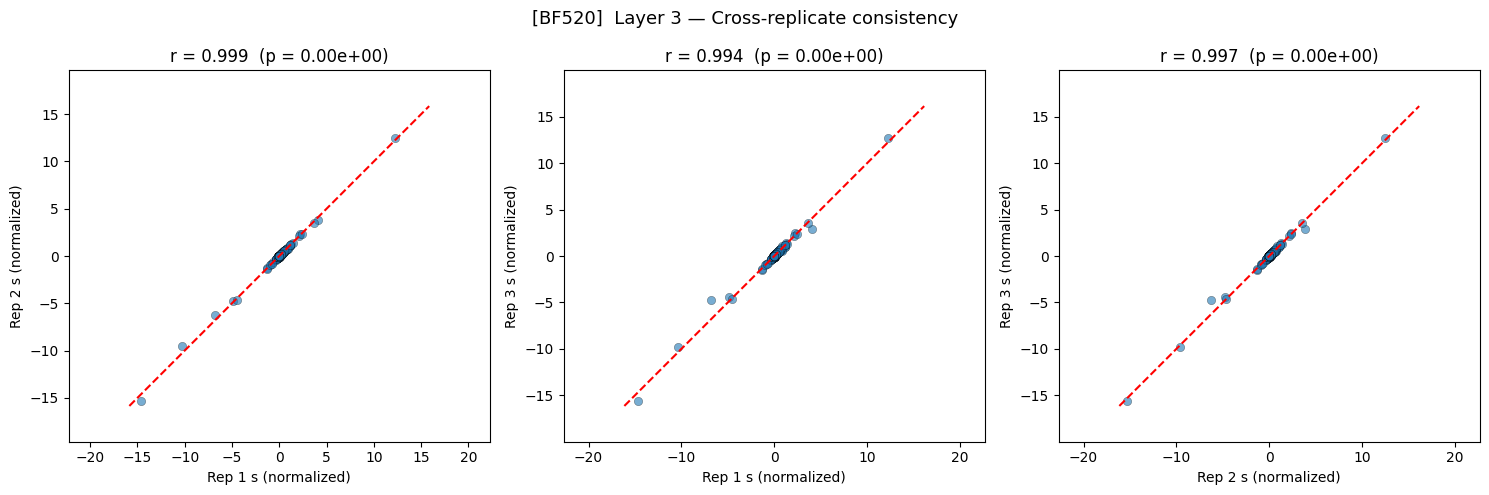

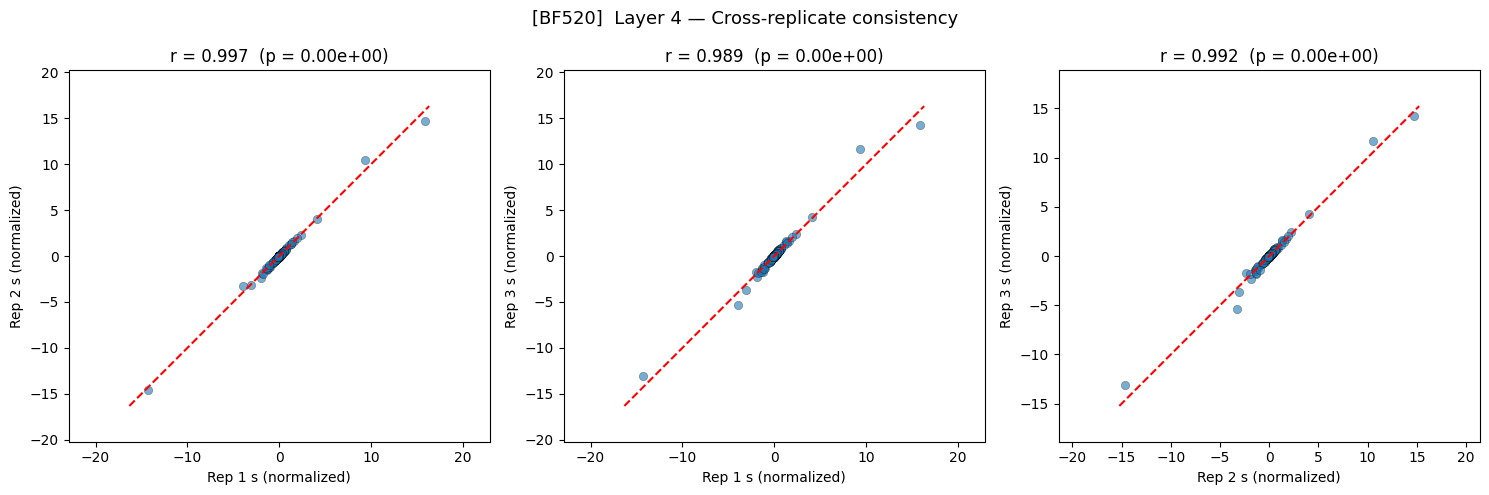

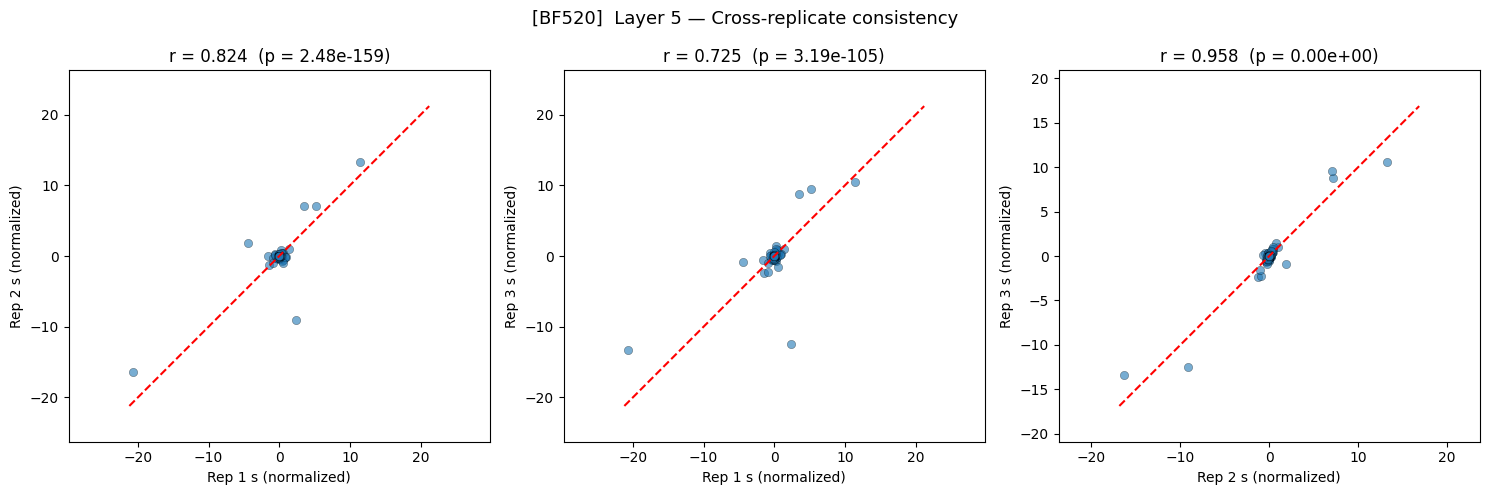

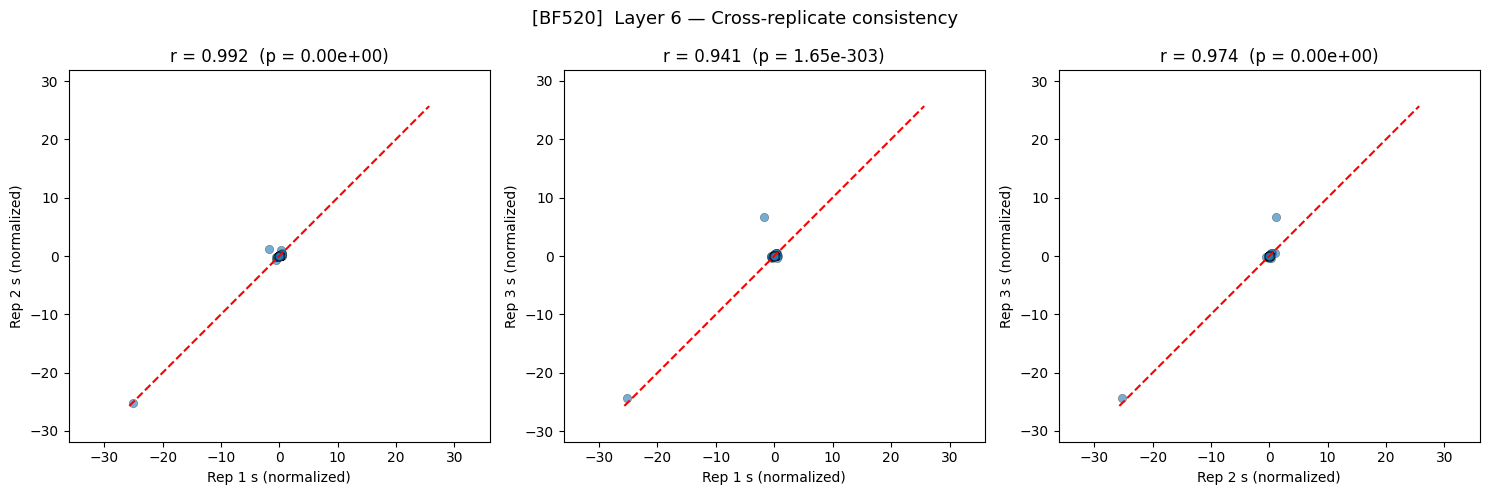

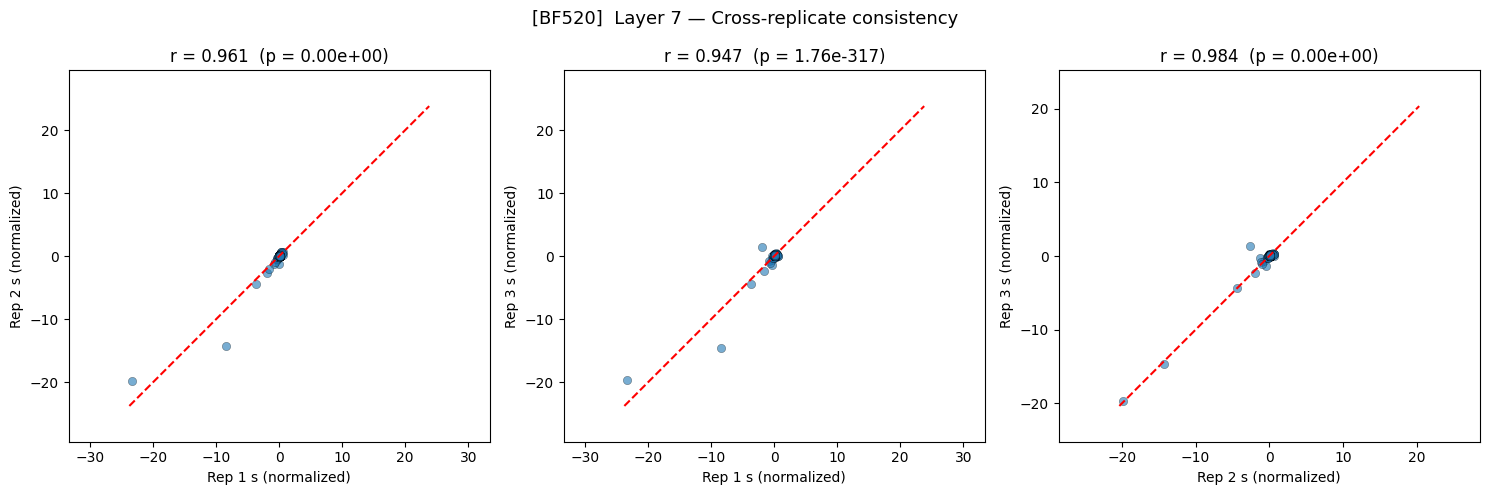

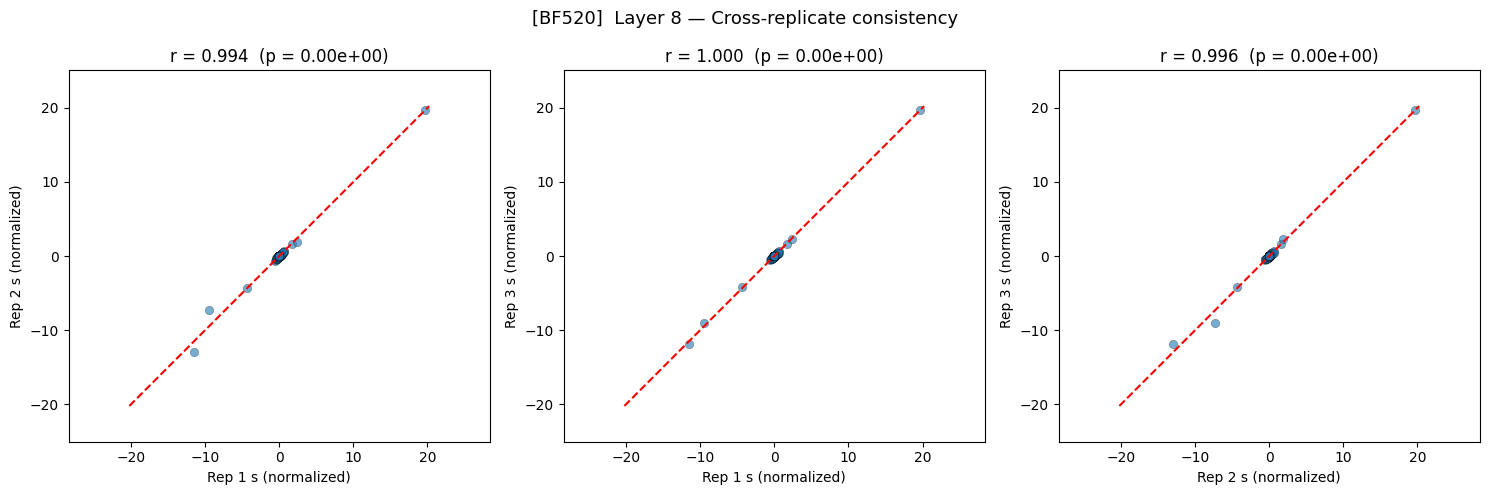

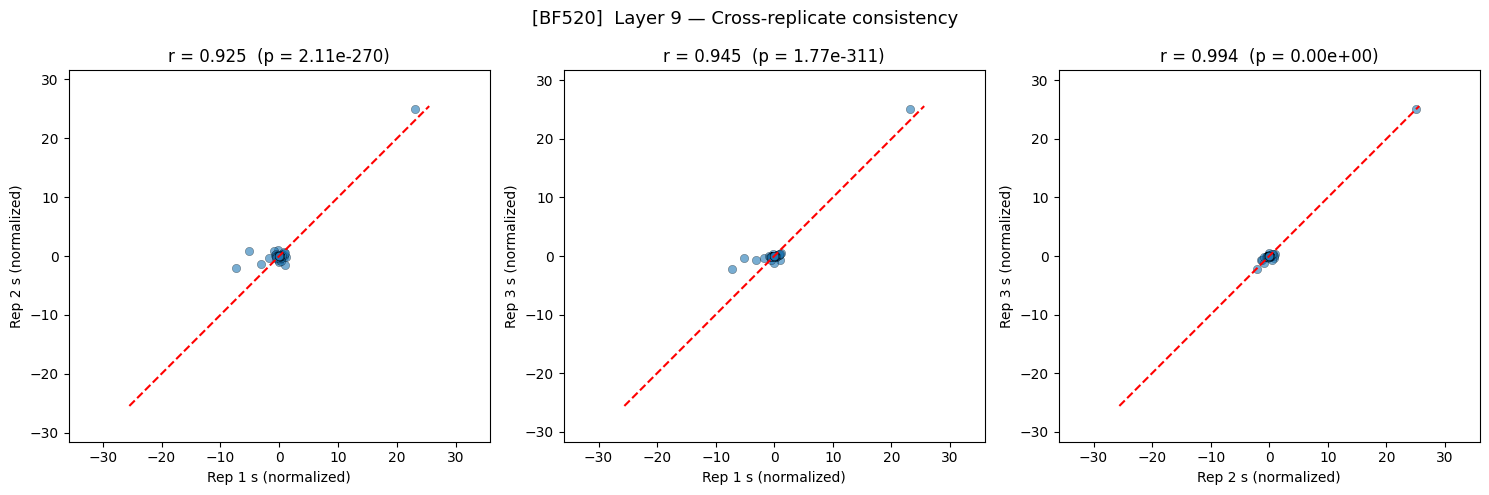

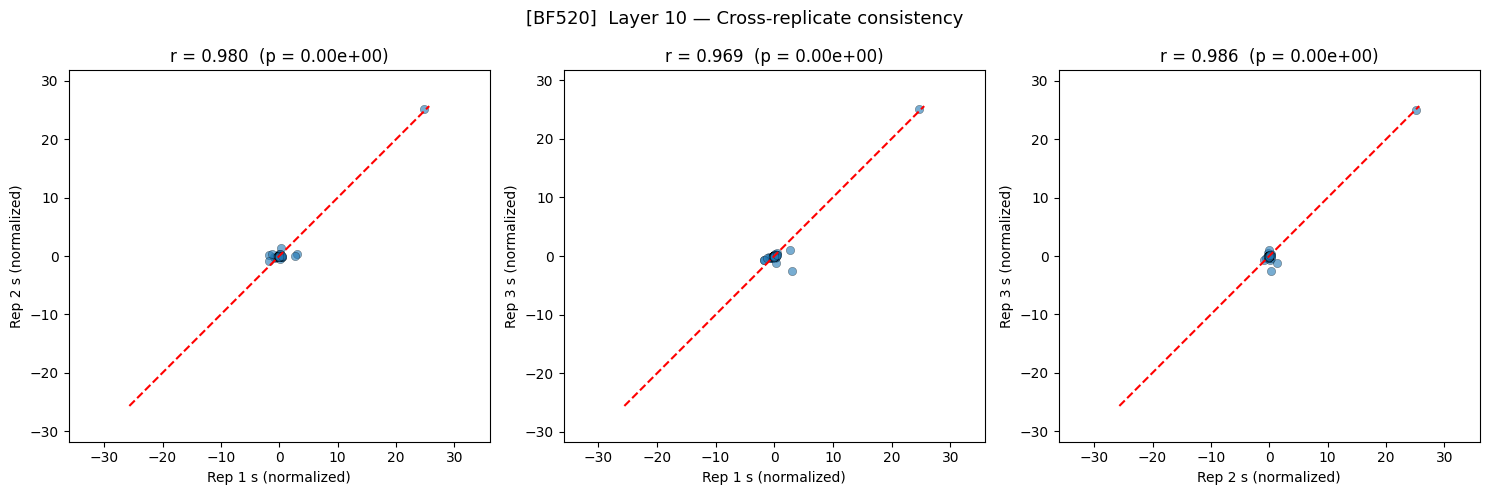

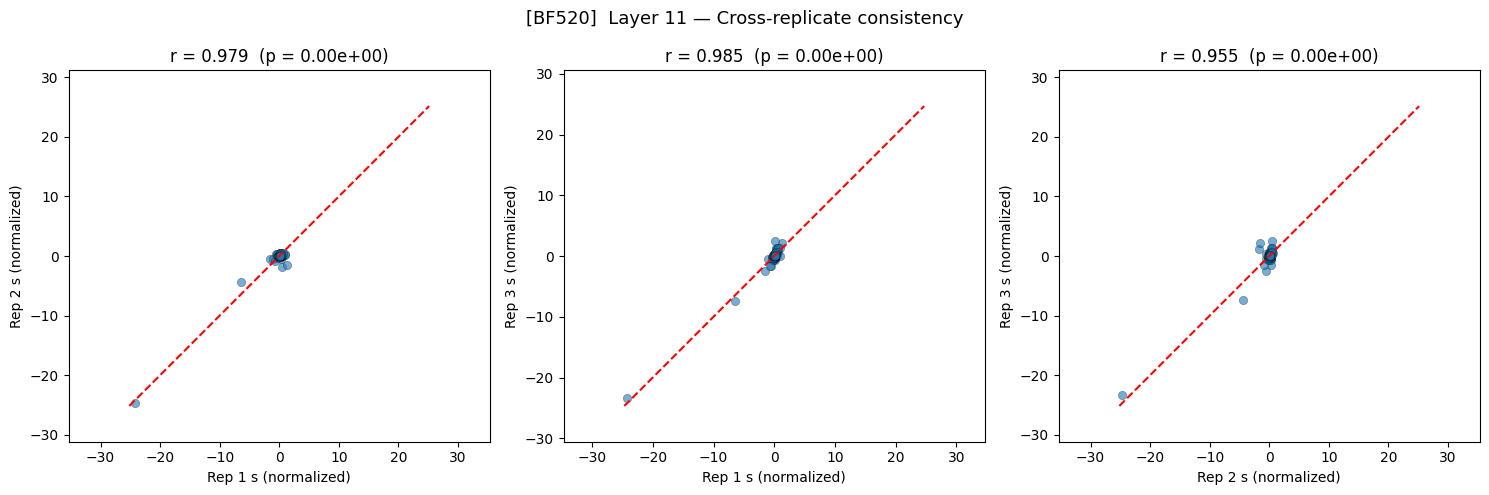

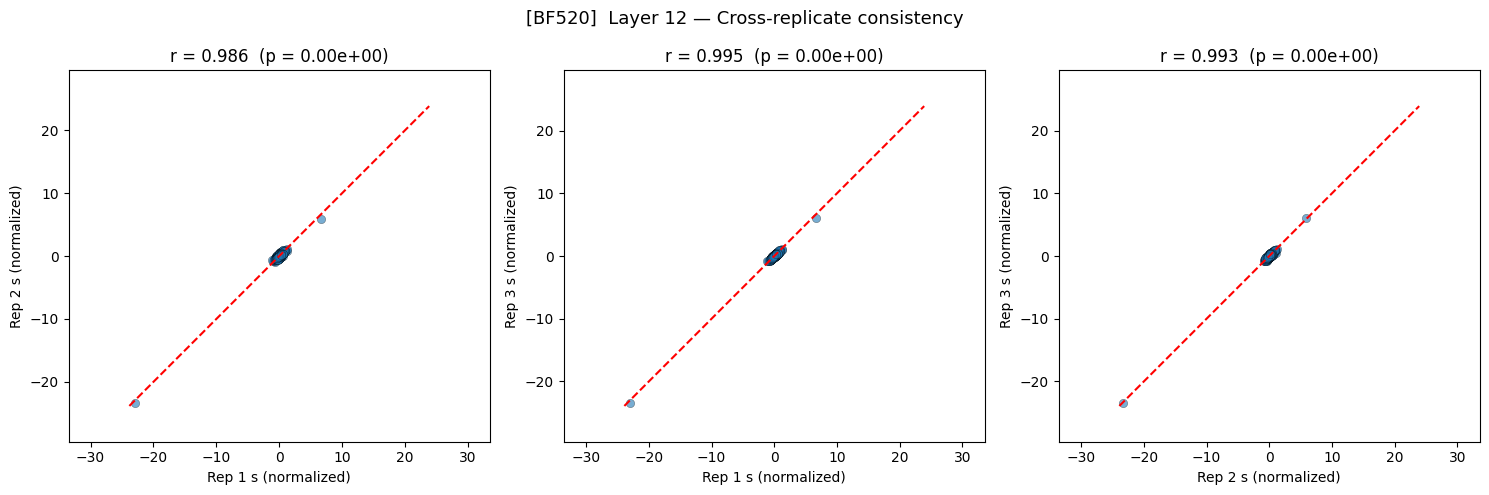

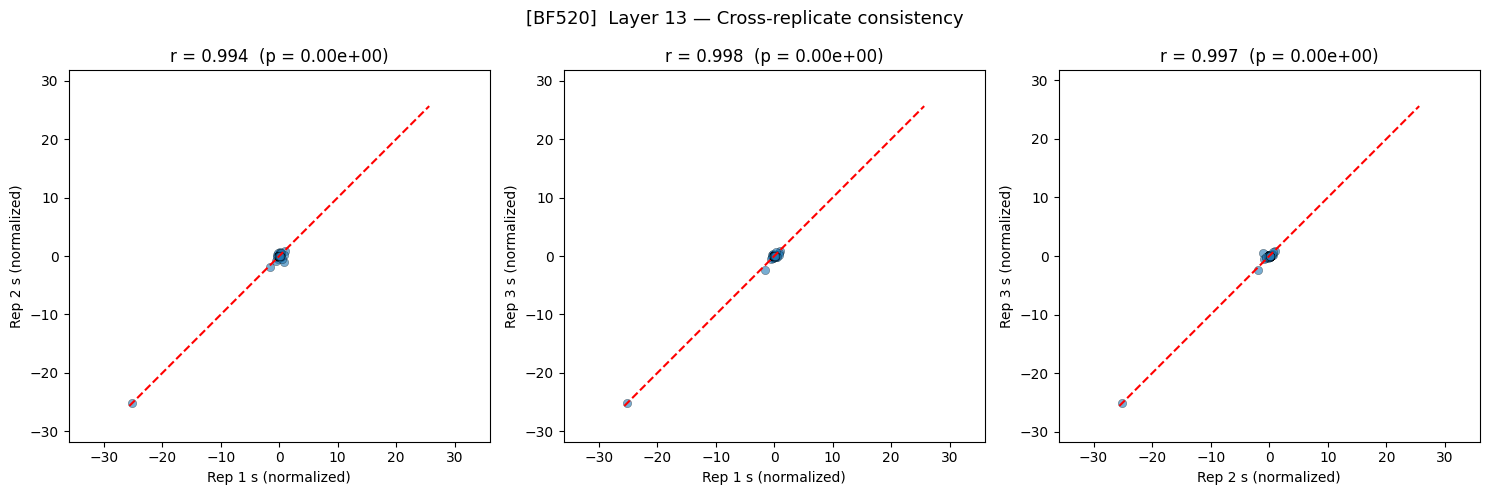

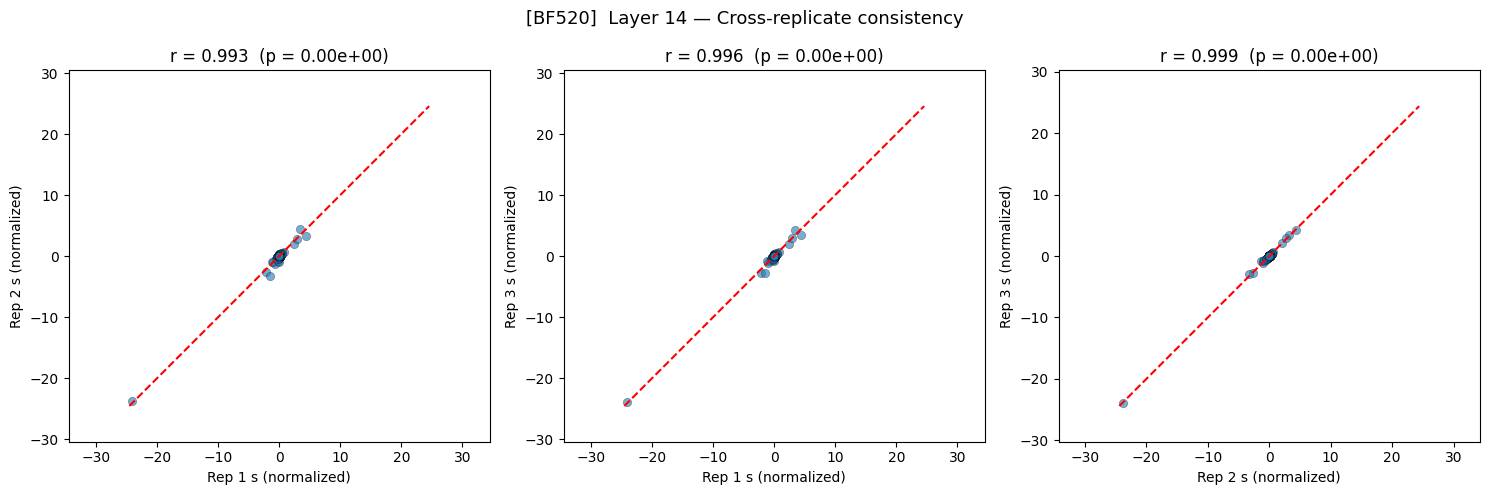

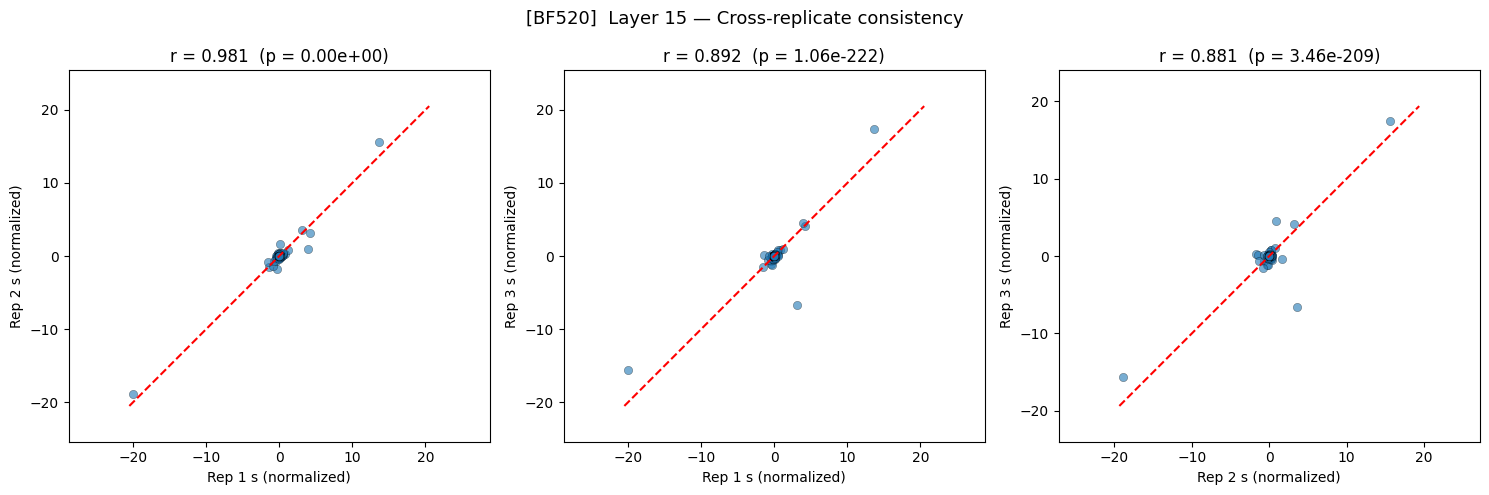

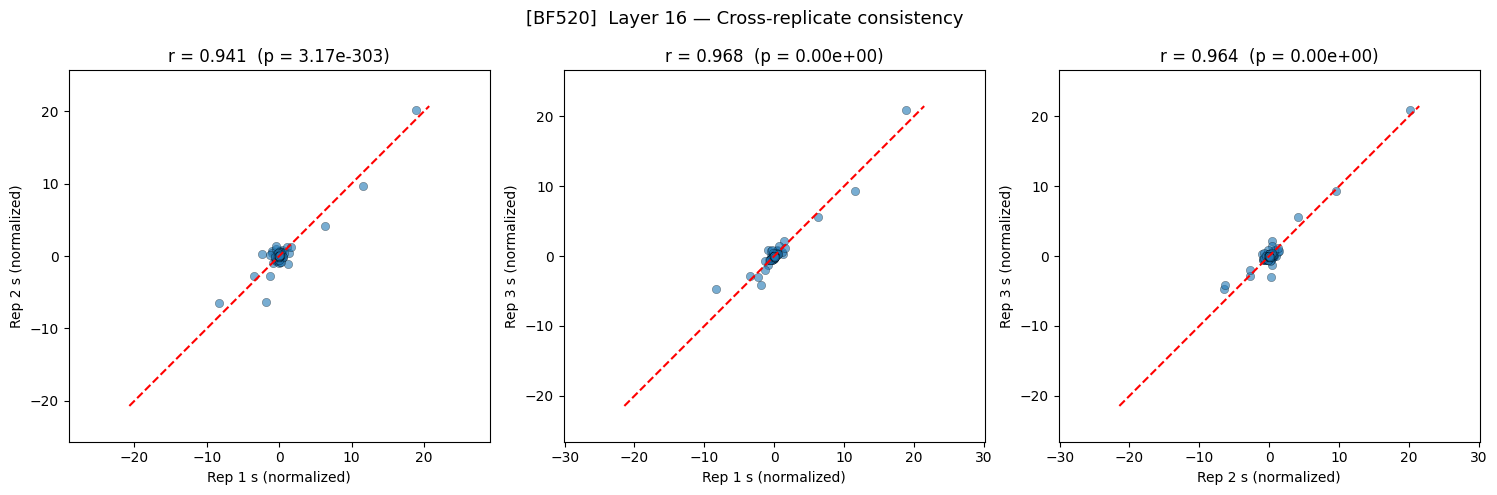

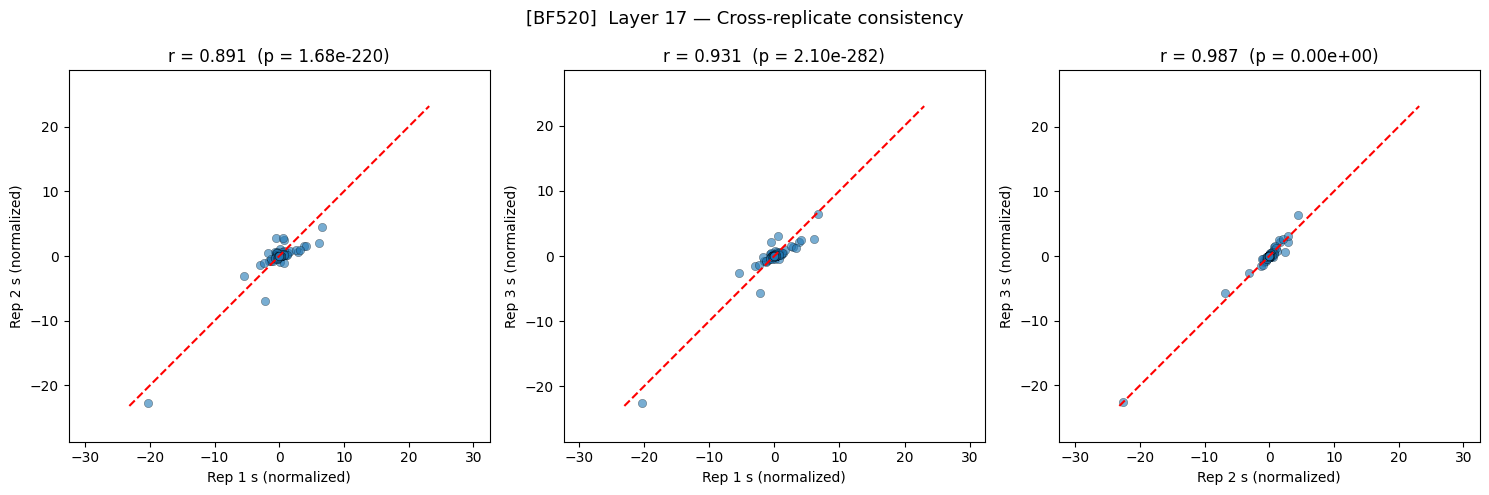

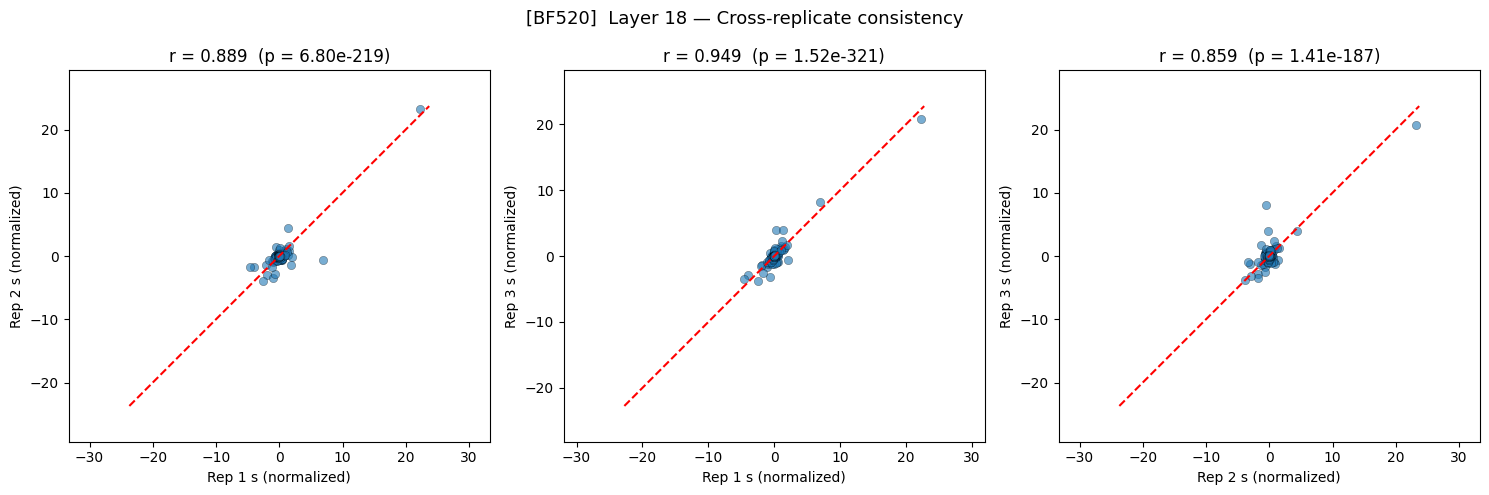

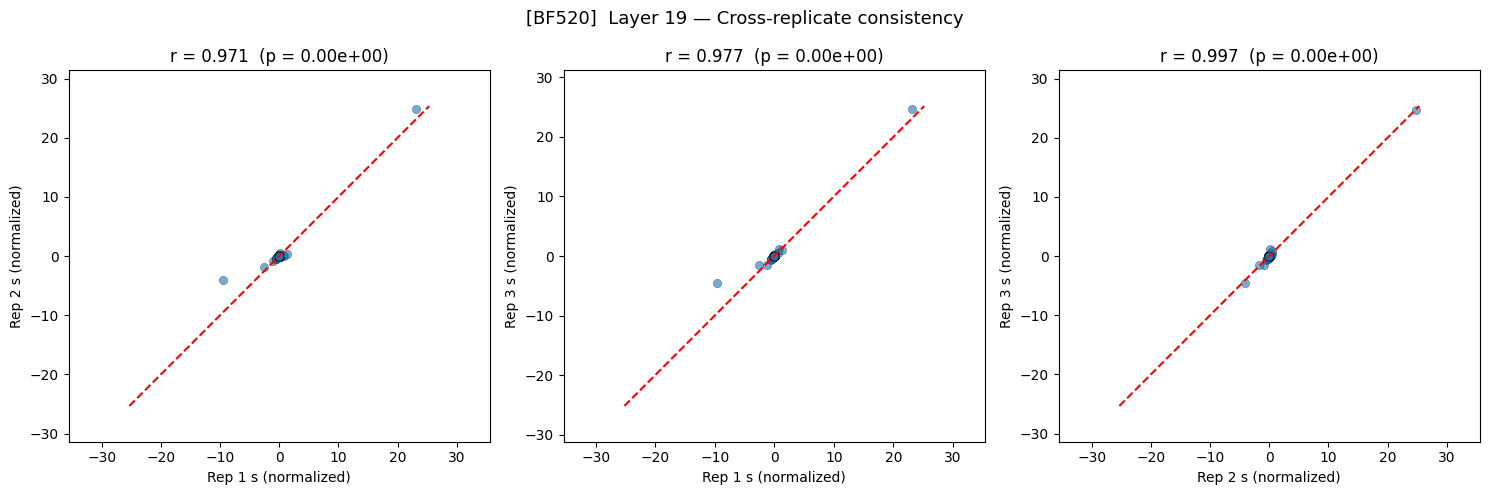

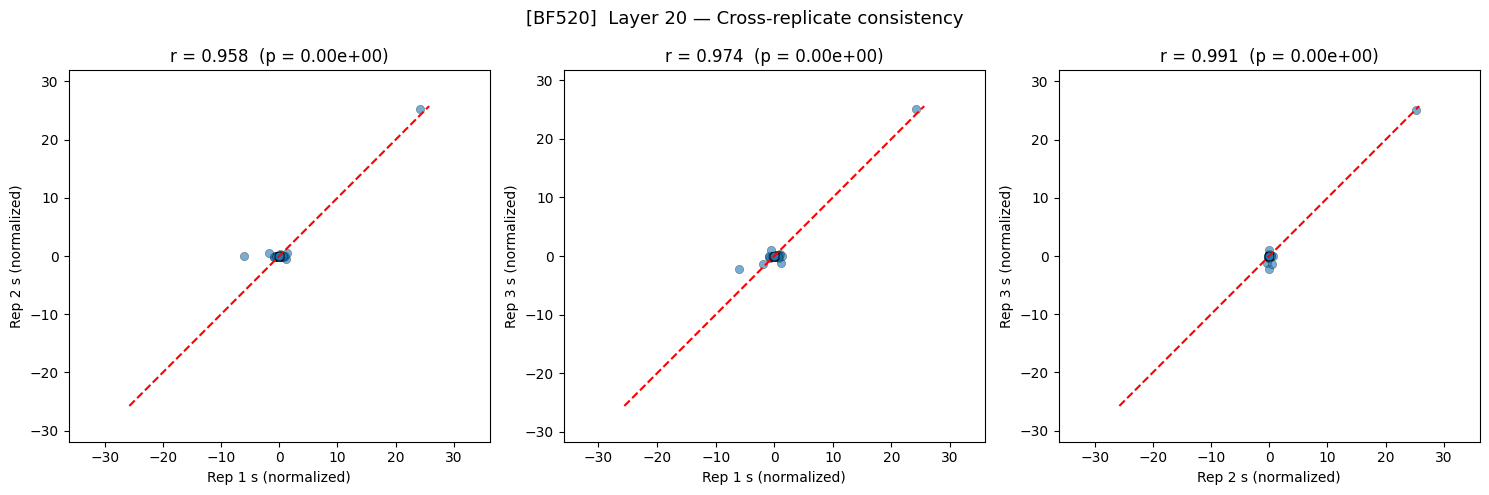

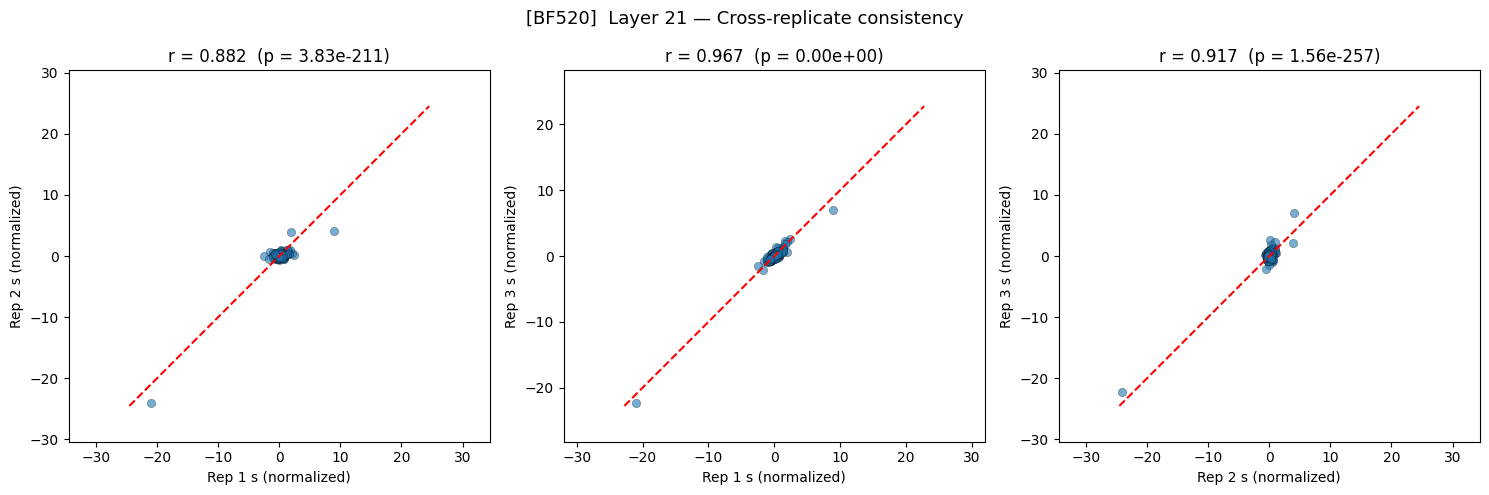

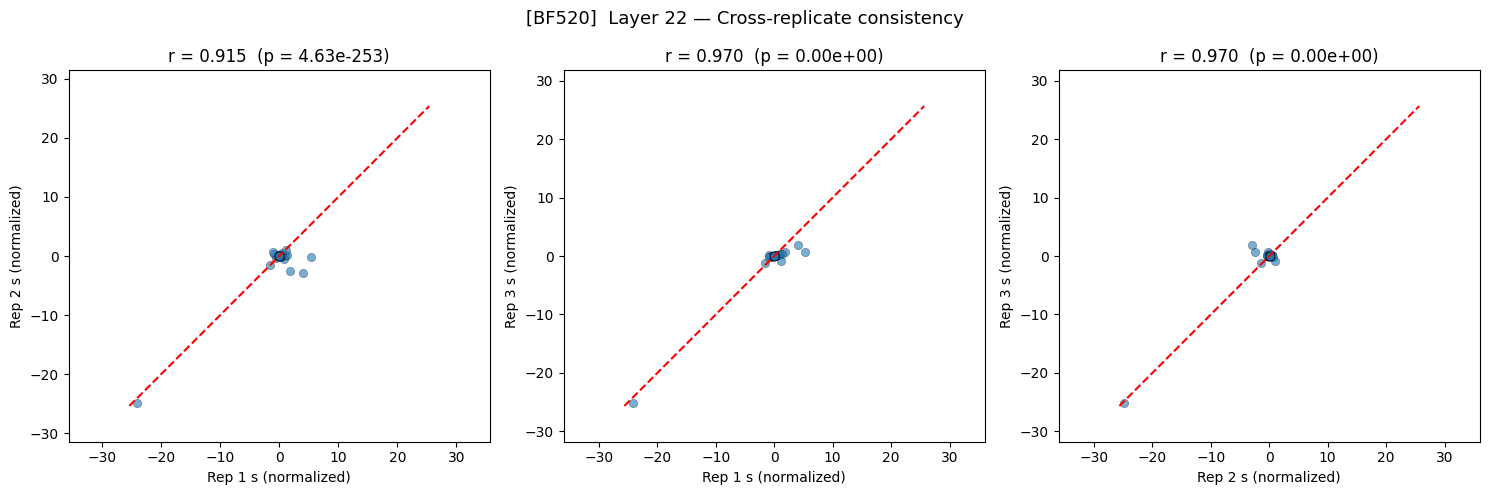

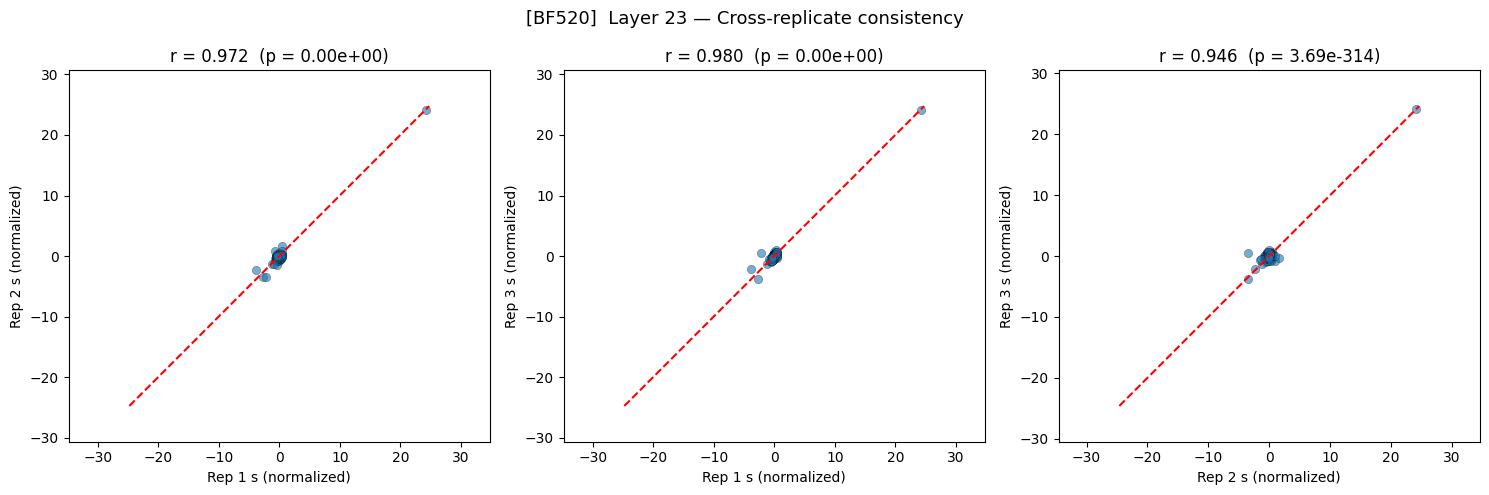

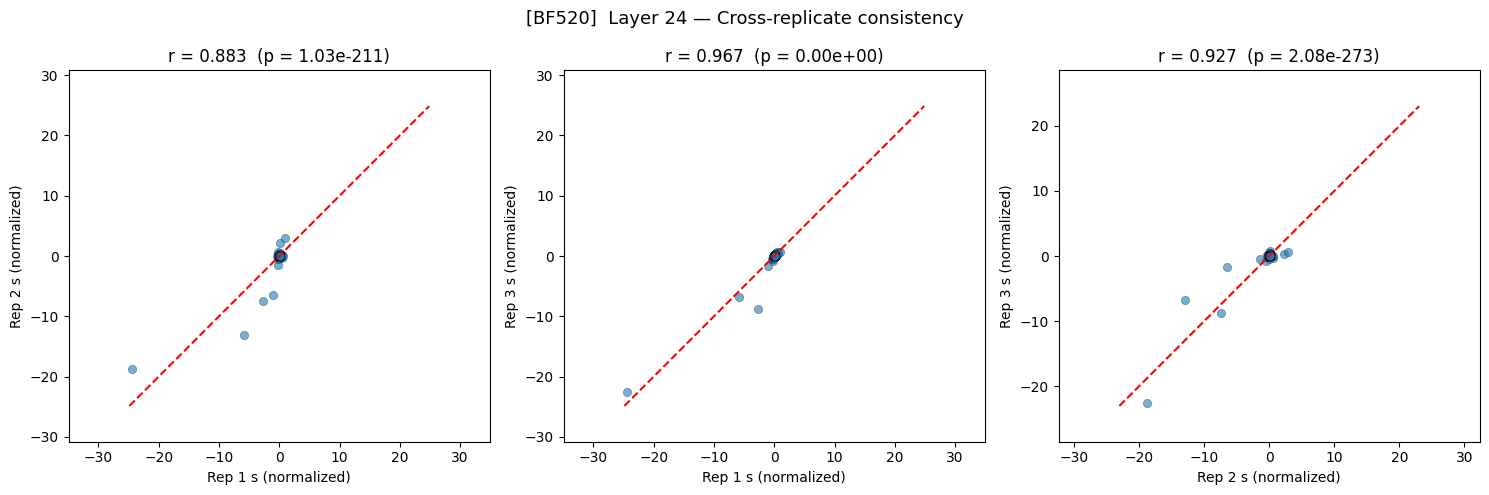

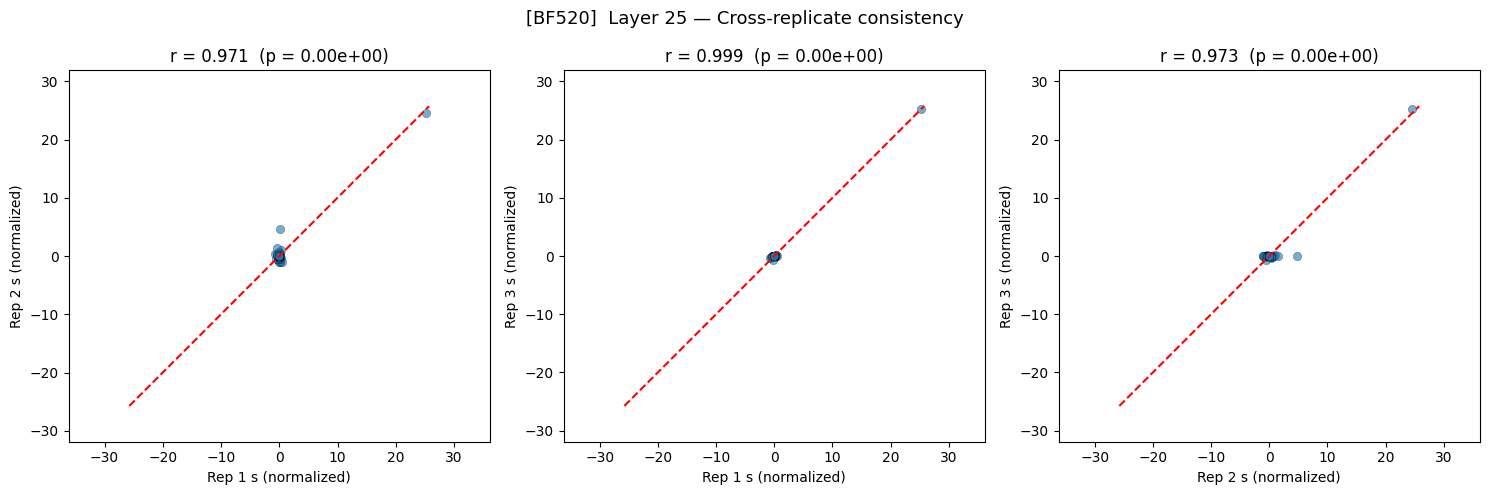

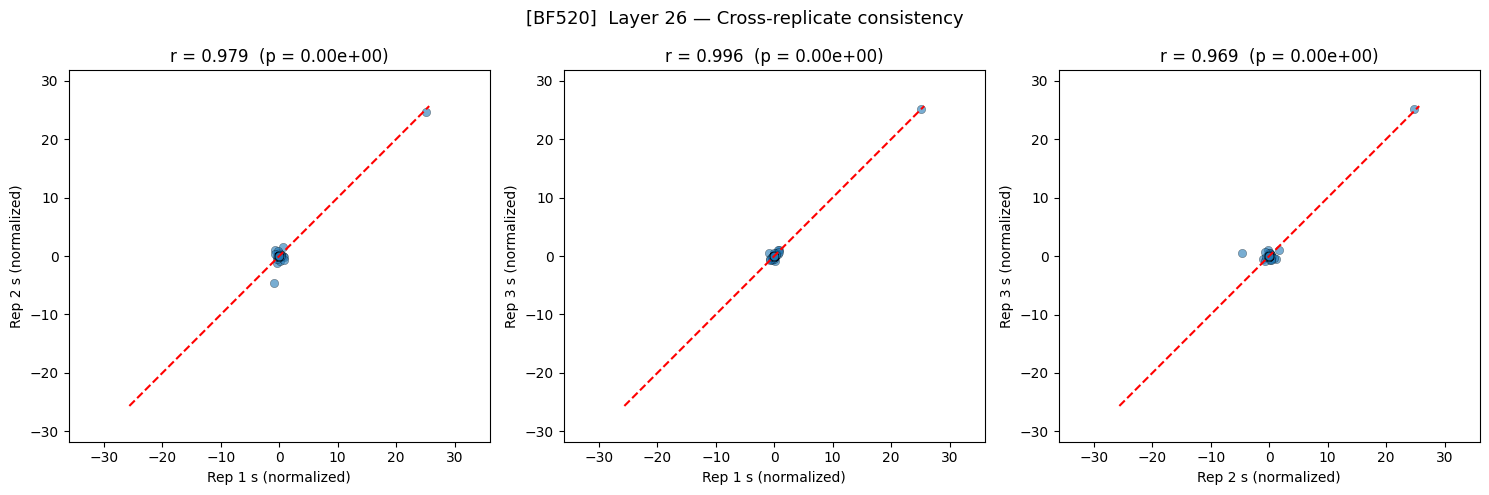

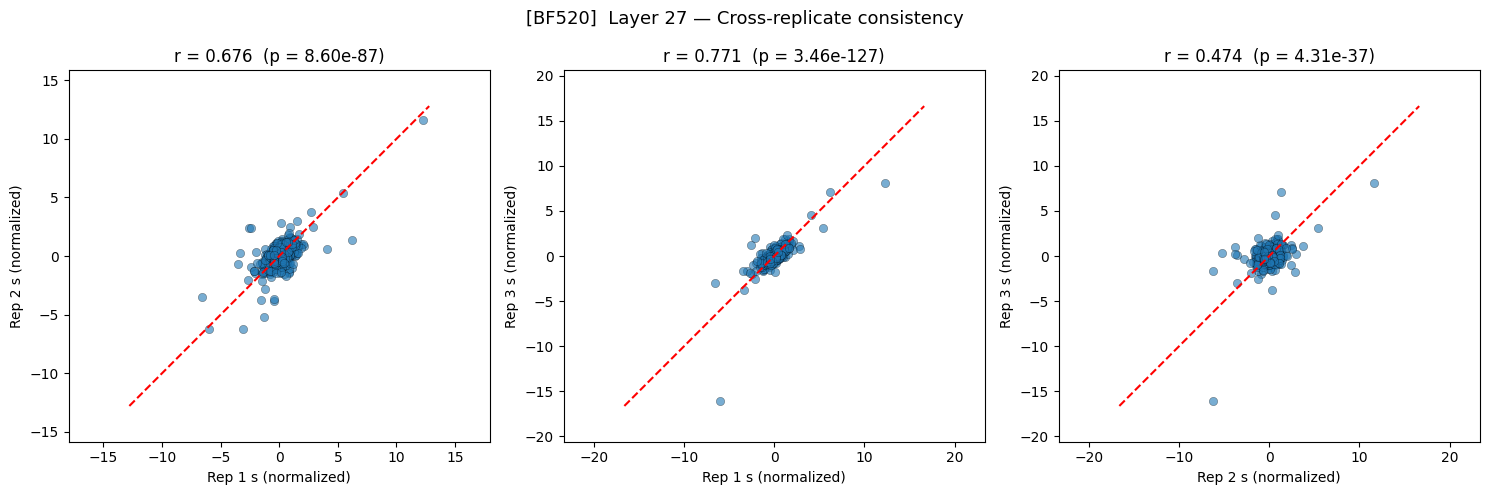

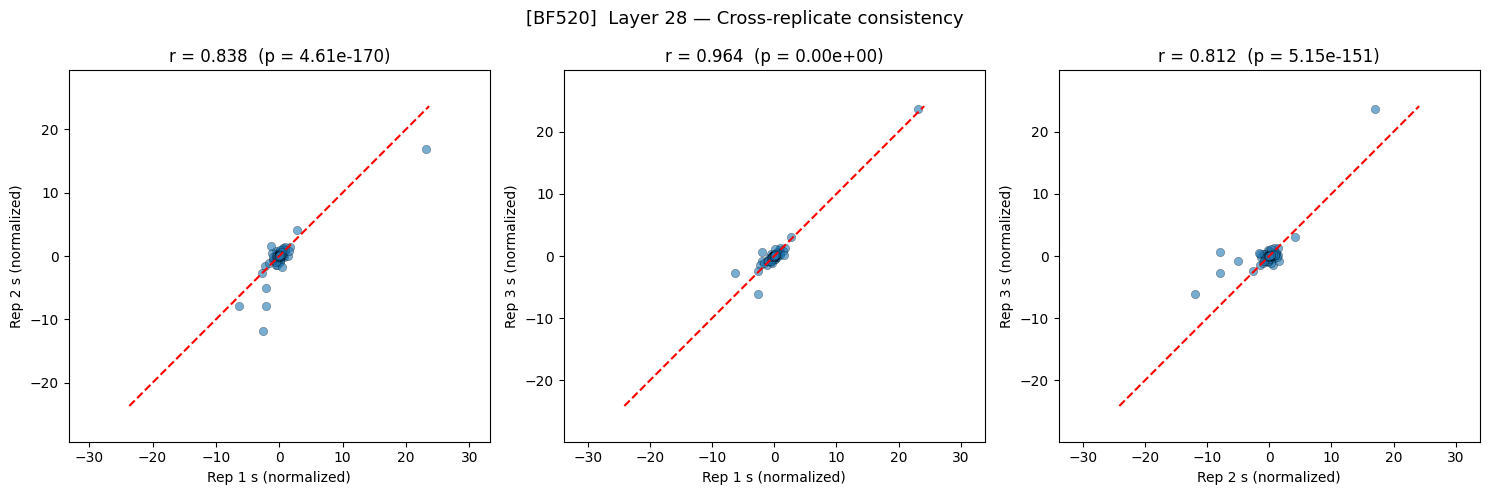

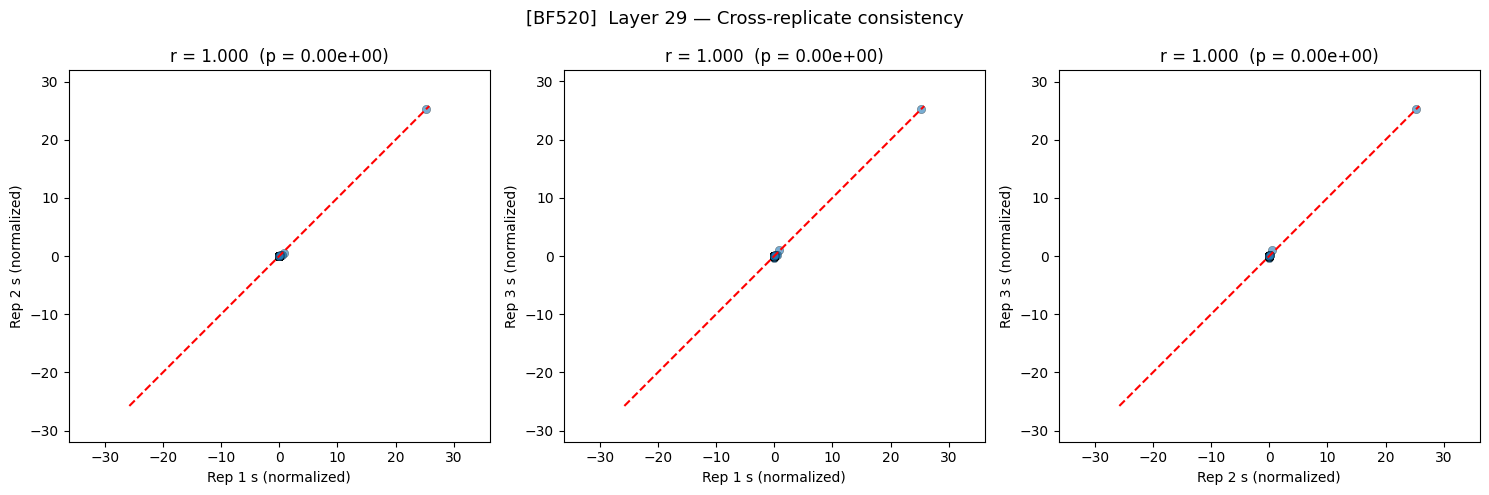

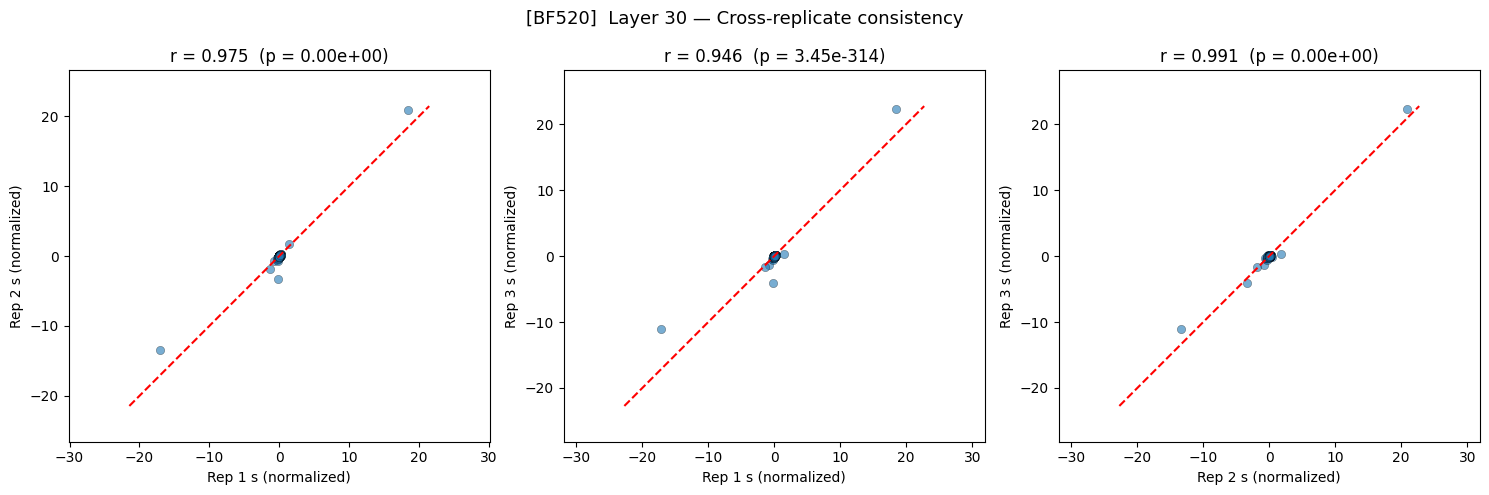

In [6]:
from analysis_helpers import plot_cross_replicate_consistency
plot_cross_replicate_consistency(all_results_fullcov, LAYERS)

Dataset: BG505
Dataset: BF520


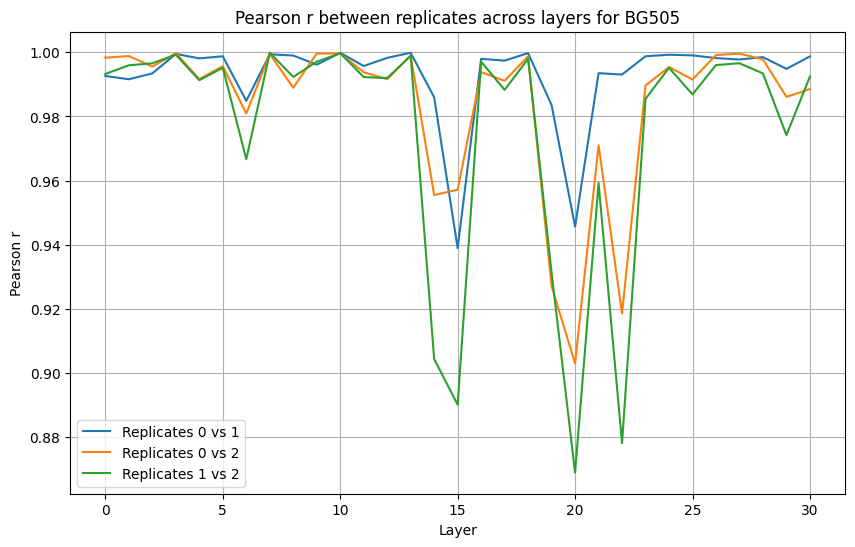

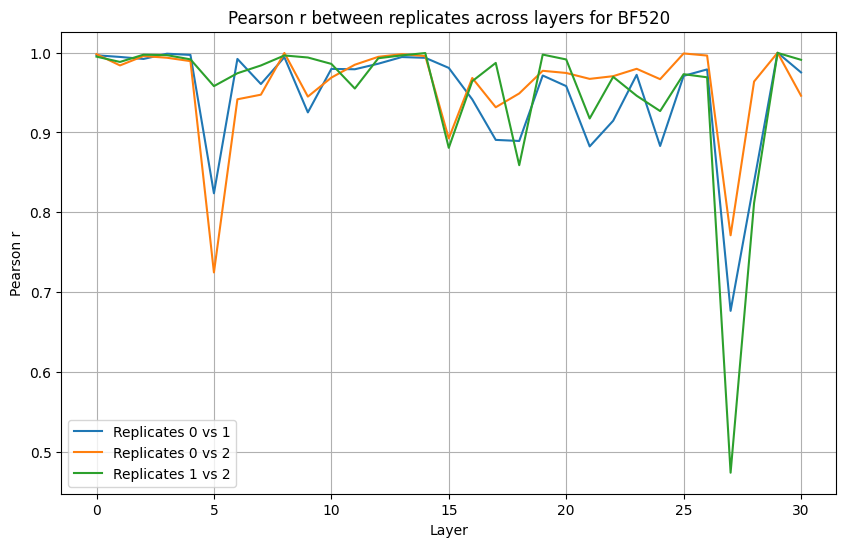

In [7]:
# Plot the pearson r correlation between replicates by layer
dataset_pearson_results = {}
for dataset in active_datasets:
    print(f"Dataset: {dataset}")
    dataset_results = all_results_fullcov[dataset][2]  # Get the detailed results for this dataset
    dataset_pearson_results[dataset] = {}
    for layer in LAYERS:
        if layer not in dataset_results:
            print(f"  Layer {layer} not found in results.")
            continue
        layer_results = dataset_results[layer]
        replicate_pairs = [(0, 1), (0, 2), (1, 2)]
        r_values = []
        for replicate_pair in replicate_pairs:
            replicate_1 = layer_results[0][replicate_pair[0]]
            replicate_2 = layer_results[0][replicate_pair[1]]
            r, _ = pearsonr(replicate_1, replicate_2)
            r_values.append(r)
        
        dataset_pearson_results[dataset][layer] = r_values

# Plot the pearson r across layers for each dataset and replicate pair
for dataset in dataset_pearson_results:
    plt.figure(figsize=(10, 6))
    for i, replicate_pair in enumerate([(0, 1), (0, 2), (1, 2)]):
        r_values = [dataset_pearson_results[dataset][layer][i] for layer in LAYERS if layer in dataset_pearson_results[dataset]]
        plt.plot(LAYERS[:len(r_values)], r_values, label=f"Replicates {replicate_pair[0]} vs {replicate_pair[1]}")
    
    plt.title(f"Pearson r between replicates across layers for {dataset}")
    plt.xlabel("Layer")
    plt.ylabel("Pearson r")
    plt.legend()
    plt.grid()
    plt.show()

